In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
from pathlib import Path
PROJECT = Path('/content/drive/MyDrive/cm3070')
DATA = PROJECT/'data'
EXPENSIVE = PROJECT/'expensive'
RESULTS_ROOT = PROJECT/'results'
CACHE = Path('/content/cache')
for directory in (EXPENSIVE, RESULTS_ROOT, CACHE):
    directory.mkdir(parents=True, exist_ok=True)

In [ ]:
from dataclasses import dataclass, asdict, replace
from typing import Optional

# Window lengths in hours. Features look back 24h, acceleration compares the two
# 12h halves of that window, and labels look 24h ahead.
LOOKBACK_H, ACCEL_WINDOW_H, HORIZON_H = 24, 12, 24

@dataclass(frozen=True)
class Config:
    subreddit: str = 'stocks'
    min_mentions: int = 10
    max_tickers_per_post: int = 20
    emergence_window_d: int = 30
    emergence_min_future: int = 3
    emergence_sd_floor: float = 1.0
    emergence_min_history_days: int = 7
    tau: float = 1.0
    network: str = 'strict_prior'
    betweenness_k: int = 500
    train_frac: float = 0.80
    threshold_fit_frac: float = 0.80   # share of training rows fitted before the threshold slice
    cv_splits: int = 5
    # imbalance and gb_* are starting values (sklearn's defaults for gb_*)
    imbalance: str = 'balanced'
    gb_n_estimators: int = 100
    gb_learning_rate: float = 0.1
    gb_max_depth: int = 3
    gb_subsample: float = 1.0
    seed: int = 42
    alert_budget_per_day: int = 20
    bootstrap_n: int = 1000

    def __post_init__(self):
        if self.network not in {'strict_prior', 'contemporaneous'}:
            raise ValueError(f"network must be 'strict_prior' or 'contemporaneous', got {self.network!r}")
        if self.imbalance not in {'none', 'smote', 'balanced'}:
            raise ValueError(f"imbalance must be 'none', 'smote' or 'balanced', got {self.imbalance!r}")

HEADLINE = Config()
cfg = HEADLINE
print(HEADLINE)

Config(subreddit='stocks', min_mentions=10, max_tickers_per_post=20, emergence_window_d=30, emergence_min_future=3, emergence_sd_floor=1.0, emergence_min_history_days=7, tau=1.0, network='strict_prior', betweenness_k=500, train_frac=0.8, threshold_fit_frac=0.8, cv_splits=5, imbalance='balanced', gb_n_estimators=100, gb_learning_rate=0.1, gb_max_depth=3, gb_subsample=1.0, seed=42, alert_budget_per_day=20, bootstrap_n=1000)


In [ ]:
import json, datetime
import numpy as np, pandas as pd

RECOMPUTE = False       # True ignores cached stages and market data, and rebuilds them
CACHE_VERSION = 'v8'    # bump after changing the code of a cached stage

RUN_ID = datetime.datetime.now(datetime.timezone.utc).strftime('%Y%m%dT%H%M%SZ')
RESULTS = RESULTS_ROOT/RUN_ID
for directory in (RESULTS/'figures', RESULTS/'tables', RESULTS/'audit'):
    directory.mkdir(parents=True, exist_ok=True)

REPORT = {}

def log(path, value):
    """Store value in REPORT under a dotted path such as 'dataset.rows'."""
    *parents, leaf = path.split('.')
    node = REPORT
    for key in parents:
        node = node.setdefault(key, {})
    node[leaf] = value
    return value

def to_native(value):
    """Convert numpy and pandas values into types json can write."""
    if isinstance(value, dict):
        return {str(k): to_native(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [to_native(v) for v in value]
    if isinstance(value, np.generic):
        value = value.item()
    if isinstance(value, float) and not np.isfinite(value):
        return None
    if isinstance(value, datetime.date):
        return str(value)
    return value

def save_results():
    path = RESULTS/'results.json'
    path.write_text(json.dumps(to_native(REPORT), indent=2, default=str), encoding='utf-8')
    print('Saved:', path)

log('_meta.run_id', RUN_ID)
log('_meta.config', asdict(HEADLINE))
print('Run outputs:', RESULTS)

Run outputs: /content/drive/MyDrive/cm3070/results/20260928T070808Z


In [ ]:
import matplotlib.pyplot as plt

FIGURE_NUMBERS = {}

def save_fig(fig, name, caption):
    """Save a figure, numbered in the order figures first appear. Re-running a cell keeps
    the figure's number."""
    n = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    path = RESULTS/'figures'/f'fig_{n:02d}_{name}.png'
    fig.savefig(path, dpi=200, bbox_inches='tight')
    log(f'figures.fig_{n:02d}', dict(name=name, path=str(path), caption=caption))
    return path

In [ ]:
from importlib.util import find_spec
from importlib.metadata import version

REQUIRED = {'numpy': 'numpy', 'pandas': 'pandas', 'matplotlib': 'matplotlib',
            'sklearn': 'scikit-learn', 'imblearn': 'imbalanced-learn', 'networkx': 'networkx',
            'textblob': 'textblob', 'pyarrow': 'pyarrow', 'openpyxl': 'openpyxl',
            'statsmodels': 'statsmodels', 'scipy': 'scipy', 'yfinance': 'yfinance'}
missing = [package for module, package in REQUIRED.items() if find_spec(module) is None]
if missing:
    raise ImportError('Install these packages before running: '+', '.join(missing))
log('_meta.packages', {package: version(package) for package in REQUIRED.values()})
print('Dependencies available.')

Dependencies available.


In [ ]:
required_files = [f'{cfg.subreddit}.csv', 'pennystocks.csv', 'investing.csv',
                  'nasdaqlisted.txt', 'otherlisted.txt', 'nasdaq_screener.xlsx']
missing = [name for name in required_files if not (DATA/name).is_file()]
if missing:
    raise FileNotFoundError('Missing inputs: '+', '.join(missing))
for name in required_files:
    print(f'{name}: {(DATA/name).stat().st_size:,} bytes')

for name in [f'{s}.csv' for s in ['finance', 'stockmarket', 'wallstreetbets']]:
    print(f"{name}: {'present' if (DATA/name).is_file() else 'absent, left out of the scale sweep'}")
fb_path = EXPENSIVE/f'sentiment_finbert_{cfg.subreddit}.parquet'
print(f"{fb_path.name}: {'present' if fb_path.is_file() else 'absent, FinBERT comparison skipped'}")

stocks.csv: 48,175,212 bytes
pennystocks.csv: 39,718,787 bytes
investing.csv: 19,784,346 bytes
nasdaqlisted.txt: 347,596 bytes
otherlisted.txt: 535,651 bytes
nasdaq_screener.xlsx: 664,361 bytes
finance.csv: present
stockmarket.csv: present
wallstreetbets.csv: present
sentiment_finbert_stocks.parquet: present


In [ ]:
import re, itertools, time, hashlib
from collections import Counter
from textblob import TextBlob
import networkx as nx
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, f1_score, precision_score, recall_score,
                             average_precision_score, brier_score_loss, cohen_kappa_score)

IDENTIFYING = ['author', 'shortlink', 'url', 'thumbnail', 'permalink']
FREE_TEXT = ['full_text', 'title', 'selftext', 'body']

def checkpoint(name, fn, cfg, keys, inputs=(), extra=None, store=CACHE):
    """Cache a DataFrame stage as Parquet. The file name hashes CACHE_VERSION, the config
    fields in keys, each input file's size and modification time, and any extra values,
    so a change to any of them rebuilds the stage. Code changes still need a CACHE_VERSION bump."""
    spec = {'version': CACHE_VERSION, 'config': {k: getattr(cfg, k) for k in keys},
            'inputs': [(str(p), Path(p).stat().st_size, Path(p).stat().st_mtime_ns) for p in inputs],
            'extra': extra}
    key = hashlib.sha256(json.dumps(spec, sort_keys=True, default=str).encode()).hexdigest()[:16]
    path = Path(store)/f'{name}_{key}.parquet'
    if path.exists() and not RECOMPUTE:
        print('[hit ]', name)
        return pd.read_parquet(path)
    started = time.perf_counter()
    frame = fn()
    path.parent.mkdir(parents=True, exist_ok=True)
    frame.to_parquet(path, index=False)
    print(f'[calc] {name}: {time.perf_counter()-started:.1f}s')
    return frame

In [ ]:
AUTHOR_SALT = 'cm3070-2026'

def pseudonymise(authors, salt=AUTHOR_SALT):
    """Replace usernames with the first 12 hex characters of sha256(salt + username).
    Missing authors stay missing. Anyone with the salt can recompute the IDs."""
    return authors.map(lambda a: hashlib.sha256((salt + str(a)).encode()).hexdigest()[:12],
                       na_action='ignore')

log('ethics.pseudonymisation', {'method': 'sha256(salt + username)[:12]', 'salt': AUTHOR_SALT})

def load_posts(cfg):
    """Load one subreddit, drop deleted posts and replace usernames with pseudonymous IDs."""
    d = pd.read_csv(DATA/f'{cfg.subreddit}.csv', low_memory=False)
    raw_count = len(d)
    d['created'] = pd.to_datetime(d.created, utc=True).dt.tz_localize(None)
    if d.created.isna().any():
        raise ValueError('Missing source timestamps.')
    d = d.sort_values('created', kind='mergesort').reset_index(drop=True)
    d['selftext'] = d.selftext.fillna('')
    d = d[(d.selftext != '[deleted]') & (d.author != '[deleted]')].copy()
    d['full_text'] = d.title.fillna('')+' '+d.selftext
    d['author_id'] = pseudonymise(d['author'])
    if d['author_id'].nunique() != d['author'].nunique():
        raise ValueError('Two usernames map to the same author ID.')
    d = d.drop(columns=[c for c in IDENTIFYING if c in d])
    d.attrs['raw_posts'] = raw_count
    return d

def build_universe():
    """Symbol directory from the NASDAQ Trader files plus IPO years from the screener."""
    nasdaq = pd.read_csv(DATA/'nasdaqlisted.txt', sep='|')[:-1]   # last line is a file footer
    other = pd.read_csv(DATA/'otherlisted.txt', sep='|')[:-1]
    uni = pd.concat([
        nasdaq[['Symbol', 'ETF', 'Test Issue', 'Security Name']].rename(columns={'Symbol': 'symbol'}),
        other[['ACT Symbol', 'ETF', 'Test Issue', 'Security Name']].rename(columns={'ACT Symbol': 'symbol'}),
    ], ignore_index=True)
    uni['symbol'] = uni['symbol'].astype(str).str.strip()
    uni = uni[uni['Test Issue'] == 'N'].drop_duplicates('symbol')
    screener = pd.read_excel(DATA/'nasdaq_screener.xlsx')
    screener['Symbol'] = screener['Symbol'].astype(str).str.strip()
    ipo = pd.to_numeric(screener.set_index('Symbol')['IPO Year'], errors='coerce')
    etf = set(uni.loc[uni['ETF'] == 'Y', 'symbol'])
    # In 2021 FB was Facebook common stock, whatever today's listing says about the symbol.
    etf.discard('FB')
    return {'universe': uni, 'universe_symbols': set(uni['symbol']),
            'listed_after_2021': set(ipo[ipo > 2021].index), 'etf_symbols': etf,
            'sym_names': uni.set_index('symbol')['Security Name']}

# Decomposing the predictability of attention bursts on Reddit
Research questions:
- **RQ1** Can next-24-hour attention surges be predicted better than simple baselines?
- **RQ2** Which groups of features carry that predictive signal?
- **RQ3** Does a ticker's position in the co-mention network add anything beyond how popular it already is?
- **RQ4** Do the answers change with a per-ticker (emergence) definition of a surge instead of a global one?

The notebook is in four parts: (1) definitions, (2) unit tests on synthetic data,
(3) building the dataset, and (4) the experiments.

## 1. Definitions
### 1.1 Data pipeline

In [ ]:
# Abbreviations and slang that are also symbols. Never extracted.
AMBIGUOUS = {
    'DD','IPO','EPS','ETF','CEO','CFO','GDP','USD','SEC','FED',
    'ATH','ATM','DCA','PT','TA','IRA','ROI','YTD','YOY','NAV',
    'AUM','ITM','OTM','PE','TD','RH',
    'OP','PM','DM','IMO','TBH','AMA','YOLO','FOMO','LOL','LMAO','WSB','EDIT',
    'UK','EU','US','CA','JP','FDA','NYSE','WWW','USA','RSI','ET','AI','LINK',
    'OR','FOR','IT','TV','ALL','UP','PRE','TLDR','CHAT','WEEK','COO','PEG',
    'FCF','REIT','GOP',
    'SMA','EMA','MACD','VWAP','BETA','HERE','PS','AS','SI','PR','SA','DC','WTF','WAY','LSE','RBC','PMI','CC','AG',
    'IE','MF','DMA','RR',
}
# Symbols that are also common English words. Extracted only as cashtags ($NOW).
CASHTAG_ONLY = {
    'ON','NOW','CAN','GO','SO','ARE','BE','OUT','OPEN','REAL','LOVE','HAS','AN','BY','HE',
    'RUN','KEY','CASH','MAN','FUN','AM','EAT','FAST','PLAY','WELL','TRUE','CARS','BIG','NEW',
    'GOOD','HOME','LIFE','BEST','SEE','LOW','MOST','ANY','CAR','FREE','PAY','SAFE','GAIN',
    'NICE','ONE','TWO','DO','JOB','PEAK','HOPE','GOLD','EVER','TOP','MINE','NEXT','TIME','TREE',
    'LIVE',
}
# Symbols traded in 2021 that today's listing files omit or mark as post-2021 IPOs.
# This patches known gaps; it is not a full point-in-time 2021 universe.
MANUAL_ADD = {
    'SQ','ETSY','APHA','RIDE','VIAC','SKLZ','WISH','TWTR','NAKD','BBBY',
    'NKLA','ATVI','BBIG','WBA','CCIV','GOEV','DIDI','SPRT','DISCA','EXPI',
    'HGEN','MAXN','BGFV','ELMS','AGTC','FSR','APPH','SDC','LAC','ZOM',
    'TTCF','TRIT','RAD','SFT','AZN','GSK','BAM','GSAT','LB','VG',
}

def build_valid_symbols(uni):
    """Listed symbols, minus post-2021 IPOs, plus MANUAL_ADD, minus AMBIGUOUS."""
    return ((uni['universe_symbols'] - uni['listed_after_2021']) | MANUAL_ADD) - AMBIGUOUS

In [ ]:
URL = re.compile(r'https?://\S+|\bwww\.\S+')
# A bare token must not follow a word character, a dot or a dollar sign. The dot rule
# stops the DE in BMW.DE being read as a ticker (BMW itself can still match).
# Cashtags are matched separately.
BARE_TOKEN = re.compile(r'(?<![.\w$])([A-Z]{2,5})\b')
CASHTAG = re.compile(r'\$([A-Z]{1,5})\b')

def bare_tokens(text):
    """Upper-case bare tokens outside URLs, excluding tokens that follow a dot."""
    return set(BARE_TOKEN.findall(URL.sub(' ', text)))

def extract_tickers(text, symbols):
    if not isinstance(text, str):
        return []
    text = URL.sub(' ', text)   # URLs are removed before both matchers
    cashtags = set(CASHTAG.findall(text))
    bare = bare_tokens(text) - CASHTAG_ONLY
    return sorted((cashtags | bare) & symbols)

def explode_and_filter(d, valid_symbols, cfg):
    """One row per (post, ticker). A row is eligible once its ticker has at least
    min_mentions mentions up to and including that post."""
    d = d.copy()
    d['tickers'] = d['full_text'].apply(lambda x: extract_tickers(x, valid_symbols))
    posts = d[d['tickers'].apply(len) > 0].copy()
    posts['num_tickers_mentioned'] = posts['tickers'].apply(len)

    ex = posts.explode('tickers').rename(columns={'tickers': 'ticker'})
    ex = ex.sort_values('created', kind='mergesort').reset_index(drop=True)
    ex['mentions_to_date'] = ex.groupby('ticker')['created'].rank(method='max').astype(int)
    ex['eligible'] = ex['mentions_to_date'] >= cfg.min_mentions

    log(f'universe.{cfg.subreddit}.rows_before_eligibility', int((~ex['eligible']).sum()))
    return ex, posts, set(ex['ticker'])

In [ ]:
def sentiment_table(d, cfg):
    """One TextBlob polarity score per post."""
    def _calc():
        u = d.drop_duplicates('id')[['id', 'full_text']]
        pol = u['full_text'].apply(
            lambda x: TextBlob(x).sentiment.polarity if isinstance(x, str) and x.strip() else 0.0)
        return pd.DataFrame({'id': u['id'].values, 'sentiment_score': pol.values})
    return checkpoint(f'sentiment_textblob_{cfg.subreddit}', _calc, cfg, ['subreddit'],
                      inputs=[DATA/f'{cfg.subreddit}.csv'], store=EXPENSIVE)

def simple_features(ex, senti, etf_symbols):
    ex = ex.merge(senti, on='id', how='left', validate='many_to_one')
    ex['sentiment_score'] = ex['sentiment_score'].fillna(0.0)
    ex['hour_of_day'] = ex['created'].dt.hour
    ex['day_of_week'] = ex['created'].dt.dayofweek
    ex['title_length'] = ex['title'].fillna('').str.split().str.len()
    ex['word_count'] = ex['selftext'].fillna('').str.split().str.len()
    ex['is_etf'] = ex['ticker'].isin(etf_symbols).astype(int)
    ex['quarter'] = ex['created'].dt.quarter
    return ex

In [ ]:
def window_features(d, cfg, observation_end=None):
    """Add per-row window counts for each (post, ticker):
    ticker_post_rate_24h      mentions in [t-24h, t)
    ticker_post_acceleration  last 12h count / previous 12h count (denominator at least 1)
    time_since_previous       hours since the previous mention, capped at 72
    future_count_24h          mentions in (t, t+24h]; NaN when that window passes observation_end
    volume_growth             future_count_24h / max(ticker_post_rate_24h, 1) - 1
    """
    if d.empty:
        raise ValueError('Cannot build window features from an empty frame.')
    d = d.copy()
    d['created'] = pd.to_datetime(d['created'], utc=True).dt.tz_localize(None)
    if d['created'].isna().any():
        raise ValueError('created contains missing timestamps.')
    if observation_end is None:
        observation_end = d['created'].max()
    end = pd.to_datetime(observation_end, utc=True).tz_localize(None)
    if end < d['created'].max():
        raise ValueError('observation_end must cover every source row.')
    d = d.sort_values(['ticker', 'created'], kind='mergesort').reset_index(drop=True)
    W = np.timedelta64(LOOKBACK_H, 'h')
    W12 = np.timedelta64(ACCEL_WINDOW_H, 'h')
    H = np.timedelta64(HORIZON_H, 'h')
    n = len(d)
    rate = np.empty(n, dtype=np.int64)
    accel = np.empty(n, dtype=float)
    gap = np.empty(n, dtype=float)
    future = np.empty(n, dtype=float)
    for _, g in d.groupby('ticker', sort=False):
        t = g['created'].to_numpy(dtype='datetime64[ns]')
        idx = g.index.to_numpy()
        lo = np.searchsorted(t, t-W, side='left')
        lo12 = np.searchsorted(t, t-W12, side='left')
        left = np.searchsorted(t, t, side='left')
        right = np.searchsorted(t, t, side='right')
        hi = np.searchsorted(t, t+H, side='right')
        rate[idx] = left-lo
        accel[idx] = (left-lo12) / np.maximum(lo12-lo, 1)
        gh = np.full(len(t), 24.0)   # first mention of a ticker; eligibility removes these rows
        has_prior = left > 0
        gh[has_prior] = np.minimum(
            (t[has_prior]-t[left[has_prior]-1]) / np.timedelta64(1, 'h'), 72.0)
        gap[idx] = gh
        future[idx] = hi-right
    d['ticker_post_rate_24h'] = rate
    d['ticker_post_acceleration'] = accel
    d['time_since_previous'] = gap
    d['label_end'] = d['created'] + pd.Timedelta(hours=HORIZON_H)
    d['observation_end'] = end
    d['target_observed'] = d['label_end'] <= end
    future[~d['target_observed'].to_numpy()] = np.nan
    d['future_count_24h'] = future
    d['volume_growth'] = future / np.maximum(rate, 1) - 1
    return d.sort_values('created', kind='mergesort').reset_index(drop=True)

In [ ]:
def prior_graph(posts, cfg, q):
    """Weighted co-mention graph for quarter q: posts from earlier quarters (strict_prior)
    or up to and including q (contemporaneous). Posts naming more than
    max_tickers_per_post tickers are watchlists and are left out."""
    quarter = pd.to_datetime(posts['created']).dt.quarter
    in_window = quarter < q if cfg.network == 'strict_prior' else quarter <= q
    keep = in_window & posts['num_tickers_mentioned'].between(2, cfg.max_tickers_per_post)
    G = nx.Graph()
    for ts in posts.loc[keep, 'tickers']:
        for a, b in itertools.combinations(ts, 2):
            w = G[a][b]['weight'] + 1 if G.has_edge(a, b) else 1
            G.add_edge(a, b, weight=w)
    return G

def quarterly_graphs(posts, cfg):
    return {q: prior_graph(posts, cfg, q) for q in [1, 2, 3, 4]}

def build_quarterly_centrality(graphs, cfg):
    rows = []
    for q, G in graphs.items():
        if G.number_of_edges() == 0:
            continue                                   # Q1 under strict_prior
        k = cfg.betweenness_k if G.number_of_nodes() > cfg.betweenness_k else None
        bc = nx.betweenness_centrality(G, k=k, seed=cfg.seed, normalized=True)
        try:
            ec = nx.eigenvector_centrality(G, weight='weight', max_iter=2000, tol=1e-8,
                                           nstart={node: 1.0 for node in G})
        except nx.PowerIterationFailedConvergence as exc:
            raise RuntimeError(f'Eigenvector centrality did not converge for quarter {q}.') from exc
        for node in G:
            rows.append({'quarter': q, 'ticker': node,
                         'dynamic_betweenness': bc[node], 'dynamic_eigenvector': ec[node],
                         '_nodes': G.number_of_nodes(), '_edges': G.number_of_edges()})
    return pd.DataFrame(rows, columns=['quarter', 'ticker', 'dynamic_betweenness',
                                       'dynamic_eigenvector', '_nodes', '_edges'])

def attach_centrality(ex, cent):
    cols = ['quarter', 'ticker', 'dynamic_betweenness', 'dynamic_eigenvector']
    if cent[cols].isna().any().any():
        raise ValueError('Centrality rows contain missing values.')
    ex = ex.drop(columns=['dynamic_betweenness', 'dynamic_eigenvector', 'has_network'], errors='ignore')
    ex = ex.merge(cent[cols], on=['quarter', 'ticker'], how='left', validate='many_to_one',
                  indicator='_centrality_match', sort=False)
    ex['has_network'] = ex.pop('_centrality_match').eq('both').astype(int)
    # Zero means the ticker is not in the prior graph (or there is no prior graph).
    ex[['dynamic_betweenness', 'dynamic_eigenvector']] = ex[['dynamic_betweenness', 'dynamic_eigenvector']].fillna(0.)
    return ex

In [ ]:
def scrub(df, extra=()):
    """Drop identifying and free-text columns before a table is exported."""
    ban = set(IDENTIFYING) | set(FREE_TEXT) | set(extra)
    return df.drop(columns=[c for c in df.columns if c in ban])

def safe_to_csv(df, path, extra_ban=(), index=False):
    out = scrub(df, extra_ban)
    out.to_csv(path, index=index)
    return out

def emergence_label(d, cfg):
    """surge_emerge = 1 when the next-24h count exceeds the ticker's own baseline:
    mean + tau * max(sd, sd_floor) of daily counts over the previous emergence_window_d
    days, and is at least emergence_min_future. Only days on or after the ticker's first
    mention count as history; the label is NaN until the ticker has
    emergence_min_history_days of them."""
    d = d.drop(columns=['base_mean', 'base_sd', 'surge_emerge'], errors='ignore').copy()
    d['day'] = d['created'].dt.normalize()
    days = pd.date_range(d['day'].min(), d['day'].max(), freq='D')
    daily = (d.groupby(['ticker', 'day']).size().unstack('day')
              .reindex(columns=days).fillna(0.0))
    # Days before a ticker's first mention are unobserved, not zero-count days.
    first_seen = d.groupby('ticker')['day'].min().reindex(daily.index).to_numpy()
    daily = daily.where(days.to_numpy()[None, :] >= first_seen[:, None])
    W = cfg.emergence_window_d
    mean_prev = daily.T.rolling(W, min_periods=cfg.emergence_min_history_days).mean().shift(1).T
    sd_prev = daily.T.rolling(W, min_periods=cfg.emergence_min_history_days).std().shift(1).T
    baseline = pd.concat([mean_prev.stack().rename('base_mean'),
                          sd_prev.stack().rename('base_sd')], axis=1).reset_index()
    baseline.columns = ['ticker', 'day', 'base_mean', 'base_sd']
    d = d.merge(baseline, on=['ticker', 'day'], how='left', validate='many_to_one', sort=False)
    thr = d['base_mean'] + cfg.tau * np.maximum(d['base_sd'].fillna(0.0), cfg.emergence_sd_floor)
    ok = d['base_mean'].notna() & d['future_count_24h'].notna()
    d['surge_emerge'] = np.where(ok, ((d['future_count_24h'] > thr) &
                                      (d['future_count_24h'] >= cfg.emergence_min_future)).astype(float),
                                 np.nan)
    return d.drop(columns=['day'])

In [ ]:
def run_pipeline(cfg):
    d = load_posts(cfg)
    years = d.created.dt.year
    if years.nunique() != 1:
        # Network features key on quarter number only, so a second year would mix quarters.
        raise ValueError(f'Corpus spans years {sorted(years.unique().tolist())}; '
                         'switch to year-quarter periods first.')
    uni = build_universe()
    valid_symbols = build_valid_symbols(uni)
    ex, posts, _ = explode_and_filter(d, valid_symbols, cfg)
    if ex.duplicated(['id', 'ticker']).any():
        raise ValueError('Duplicate post-ticker rows: resolve duplicate source IDs first.')

    capped = posts['num_tickers_mentioned'] > cfg.max_tickers_per_post
    log(f'network.{cfg.subreddit}.posts_excluded_by_cap', int(capped.sum()))
    log(f'network.{cfg.subreddit}.max_tickers_one_post', int(posts['num_tickers_mentioned'].max()))

    # Cached stages depend on the source files and the hand-written vocabulary.
    inputs = [DATA/f'{cfg.subreddit}.csv', DATA/'nasdaqlisted.txt', DATA/'otherlisted.txt',
              DATA/'nasdaq_screener.xlsx']
    vocabulary = [sorted(AMBIGUOUS), sorted(CASHTAG_ONLY), sorted(MANUAL_ADD)]

    def _features():
        enriched = simple_features(ex, sentiment_table(d, cfg), uni['etf_symbols'])
        return window_features(enriched, cfg, observation_end=d.created.max())
    feat = checkpoint(f'features_{cfg.subreddit}', _features, cfg, ['subreddit', 'min_mentions'],
                      inputs=inputs, extra=vocabulary)
    graphs = quarterly_graphs(posts, cfg)
    cent = checkpoint(f'centrality_{cfg.subreddit}',
                      lambda: build_quarterly_centrality(graphs, cfg), cfg,
                      ['subreddit', 'min_mentions', 'max_tickers_per_post', 'network', 'betweenness_k', 'seed'],
                      inputs=inputs, extra=vocabulary)

    log(f'dataset.{cfg.subreddit}.unique_authors', int(feat['author_id'].nunique()))
    log(f'network.{cfg.subreddit}.mode', cfg.network)
    log(f'network.{cfg.subreddit}.quarters_present', sorted(cent['quarter'].unique().tolist()))
    log(f'network.{cfg.subreddit}.nodes_per_quarter', cent.groupby('quarter')['_nodes'].first().to_dict())
    log(f'network.{cfg.subreddit}.edges_per_quarter', cent.groupby('quarter')['_edges'].first().to_dict())

    feat = attach_centrality(feat, cent)
    # Emergence baselines use every mention, including those before a ticker became eligible.
    feat = emergence_label(feat, cfg)
    feat = (feat[feat['eligible']].drop(columns=['eligible'])
                .sort_values('created', kind='mergesort').reset_index(drop=True))
    log(f'network.{cfg.subreddit}.has_network_rate', float(feat['has_network'].mean()))
    log(f'dataset.{cfg.subreddit}.targets_censored', int((~feat.target_observed).sum()))
    log(f'dataset.{cfg.subreddit}.observation_end', str(d.created.max()))

    meta = {'raw_original': d.attrs['raw_posts'], 'raw': len(d), 'rows': len(feat),
            'tickers': feat['ticker'].nunique(), 'posts': len(posts), 'uni': uni,
            'valid_symbols': valid_symbols, 'posts_frame': posts,
            'raw_frame': d, 'mentions_frame': ex[['id', 'ticker', 'created']].copy()}
    return {'df': feat, 'cent': cent, 'graphs': graphs, 'meta': meta}

In [ ]:
# Popularity controls. Every value uses only earlier mentions or earlier quarters.
POP_CONTROLS = ['log_mentions_to_date', 'log_prior_q_mentions', 'log_prior_q_degree']

def history_controls(frame, mentions, graphs, cfg):
    """Add popularity controls and the previous-window growth to each (post, ticker) row.

    mentions_to_date_prior  mentions of the ticker before the post
    prior_q_mentions        mentions in the quarters the network uses for this row
    prior_q_degree          distinct co-mentioned tickers in that quarter's graph
    prior_window_count_24h  mentions in [t-48h, t-24h)
    prior_window_growth     growth of [t-24h, t) over [t-48h, t-24h)
    graphs maps quarter -> prior_graph for that quarter.
    """
    new = ['mentions_to_date_prior', 'prior_q_mentions', 'prior_q_degree',
           'prior_window_count_24h', 'prior_window_growth'] + POP_CONTROLS
    out = frame.drop(columns=new, errors='ignore').reset_index(drop=True)
    W = np.timedelta64(LOOKBACK_H, 'h')
    times = out['created'].to_numpy(dtype='datetime64[ns]')
    history = {tk: np.sort(g.to_numpy(dtype='datetime64[ns]'))
               for tk, g in mentions.groupby('ticker')['created']}
    to_date, rate, prev = (np.empty(len(out), dtype=np.int64) for _ in range(3))
    for tk, idx in out.groupby('ticker', sort=False).indices.items():
        h, t = history[tk], times[idx]
        before = np.searchsorted(h, t, side='left')
        one_back = np.searchsorted(h, t - W, side='left')
        two_back = np.searchsorted(h, t - 2*W, side='left')
        to_date[idx], rate[idx], prev[idx] = before, before - one_back, one_back - two_back
    if not np.array_equal(rate, out['ticker_post_rate_24h'].to_numpy()):
        raise ValueError('Mention history does not match the rows passed in.')
    out['mentions_to_date_prior'] = to_date
    out['prior_window_count_24h'] = prev
    out['prior_window_growth'] = rate / np.maximum(prev, 1) - 1

    mention_quarter = pd.to_datetime(mentions['created']).dt.quarter
    rows = []
    for q in [1, 2, 3, 4]:
        sel = (mention_quarter < q) if cfg.network == 'strict_prior' else (mention_quarter <= q)
        counts = mentions.loc[sel, 'ticker'].value_counts()
        degree = dict(graphs[q].degree())
        for tk in set(counts.index) | set(degree):
            rows.append({'quarter': q, 'ticker': tk, 'prior_q_mentions': int(counts.get(tk, 0)),
                         'prior_q_degree': int(degree.get(tk, 0))})
    table = pd.DataFrame(rows, columns=['quarter', 'ticker', 'prior_q_mentions', 'prior_q_degree'])
    out = out.merge(table, on=['quarter', 'ticker'], how='left', validate='many_to_one', sort=False)
    out[['prior_q_mentions', 'prior_q_degree']] = out[['prior_q_mentions', 'prior_q_degree']].fillna(0)
    out['log_mentions_to_date'] = np.log1p(out['mentions_to_date_prior'])
    out['log_prior_q_mentions'] = np.log1p(out['prior_q_mentions'])
    out['log_prior_q_degree'] = np.log1p(out['prior_q_degree'])
    return out, table

In [ ]:
# Upper-case tokens before the URL and suffix rules; used to show what those rules remove.
RAW_BARE = re.compile(r'\b([A-Z]{2,5})\b')

def token_summary(d, valid_symbols):
    """Per-token post counts and post-level retention figures.

    raw_counts     posts containing the upper-case token anywhere (URLs, suffixes, cashtags)
    bare_counts    posts with it as a bare token under the extractor's rules
    cash_counts    posts with it as a cashtag outside URLs
    either_counts  posts with it as a bare token or a cashtag (what the extractor sees)
    url_counts     posts where it appears only inside URLs
    """
    raw_counts, bare_counts, cash_counts = Counter(), Counter(), Counter()
    either_counts, url_counts = Counter(), Counter()
    n_any = n_ok = c_any = c_ok = 0
    for text in d.full_text.fillna(''):
        clean = URL.sub(' ', text)
        raw = set(RAW_BARE.findall(text))
        bare = bare_tokens(clean)
        cash = set(CASHTAG.findall(clean))
        in_urls = (set(BARE_TOKEN.findall(text)) | set(CASHTAG.findall(text))) - bare - cash
        raw_counts.update(raw); bare_counts.update(bare); cash_counts.update(cash)
        either_counts.update(bare | cash); url_counts.update(in_urls)
        n_any += bool(raw | cash)
        n_ok += bool(extract_tickers(text, valid_symbols))
        c_any += bool(cash); c_ok += bool(cash & valid_symbols)
    series = lambda c: pd.Series(c, dtype='int64').sort_values(ascending=False)
    return {'posts': len(d), 'raw_counts': series(raw_counts), 'bare_counts': series(bare_counts),
            'cash_counts': series(cash_counts), 'either_counts': series(either_counts),
            'url_counts': series(url_counts),
            'posts_with_any_token': n_any, 'posts_with_valid_ticker': n_ok,
            'posts_with_cashtag': c_any, 'cashtag_posts_retained': c_ok}

In [ ]:
def future_author_counts(frame, cfg):
    """For each (post, ticker) row, count distinct known authors who mention the ticker
    in (t, t+HORIZON_H]. Rows with a censored horizon get NaN."""
    d = frame.sort_values(['ticker', 'created'], kind='mergesort').reset_index(drop=True).copy()
    if d.duplicated(['id', 'ticker']).any():
        raise ValueError('Expected one row per post-ticker pair.')
    counts = np.full(len(d), np.nan)
    H = np.timedelta64(HORIZON_H, 'h')
    observed_all = d['target_observed'].to_numpy(dtype=bool)
    for _, g in d.groupby('ticker', sort=False):
        pos = g.index.to_numpy()
        t = g['created'].to_numpy(dtype='datetime64[ns]')
        authors = g['author_id'].to_numpy(dtype=object)
        known = pd.notna(authors)
        lo = np.searchsorted(t, t, side='right')      # first strictly later post
        hi = np.searchsorted(t, t + H, side='right')  # end of (t, t+H]
        obs = observed_all[pos]
        # Sliding window over the sorted posts, tracking how often each author appears.
        mult, distinct, l, r = Counter(), 0, 0, 0
        for local in range(len(t)):
            while r < hi[local]:
                if known[r]:
                    if mult[authors[r]] == 0:
                        distinct += 1
                    mult[authors[r]] += 1
                r += 1
            while l < lo[local]:
                if known[l]:
                    mult[authors[l]] -= 1
                    if mult[authors[l]] == 0:
                        distinct -= 1
                l += 1
            if obs[local]:
                counts[pos[local]] = distinct
    d['authors_next_24h'] = counts
    return d

def select_positive_ticker_rows(counts, labelled, y):
    """Rows of counts whose (id, ticker) is a positive row of labelled."""
    keys = ['id', 'ticker']
    target = np.asarray(y)
    if target.ndim != 1 or len(labelled) != len(target) or not np.isin(target, [0, 1]).all():
        raise ValueError('Need one observed binary target per labelled row.')
    if isinstance(y, pd.Series) and not y.index.equals(labelled.index):
        raise ValueError('Target index is not aligned with labelled rows.')
    left, right = labelled[keys].copy(), counts.copy()
    for table in (left, right):
        table['id'] = table.id.astype(str)
        if table.duplicated(keys).any():
            raise ValueError('Expected unique post-ticker keys on both sides.')
    selected = left.loc[target == 1].merge(right, on=keys, how='left',
                                          validate='one_to_one', indicator='_match', sort=False)
    if not selected['_match'].eq('both').all():
        raise ValueError('A positive post-ticker key has no matching count row.')
    return selected.drop(columns='_match')

In [ ]:
@dataclass(frozen=True)
class KleinbergConfig:
    calibration_days: int = 28
    # Calibrate after the January-February 2021 GME squeeze (same cut-off as the
    # post_feb robustness subset). None starts at the beginning of the corpus.
    calibration_start: Optional[str] = '2021-03-01'
    s: float = 2.0
    gamma: float = 1.0
    min_calibration_mentions: int = 5

KB_CFG = KleinbergConfig()
KB_CONTROLS = ['kb_base_share', 'kb_supported']
KB_FEATURES = ['kb_state', 'kb_margin', 'kb_run_hours']


def kleinberg_two_state(relevant, total, p0, p1, entry_cost, traceback=False):
    """Two-state Kleinberg burst detection over hourly batches, computed online.

    Each batch has a binomial cost at the base rate p0 (state 0) and the burst rate p1
    (state 1); entering state 1 costs entry_cost. margin = best cost ending in state 0
    minus best cost ending in state 1, so margin > 0 means the online state is 1. An
    empty hour with margin exactly 0 keeps the previous state.
    traceback=True also returns the offline best path, which uses future batches and is
    only plotted, never used as a feature.
    """
    r, n = np.asarray(relevant, dtype=float), np.asarray(total, dtype=float)
    if r.ndim != 1 or r.shape != n.shape:
        raise ValueError('Counts must be equally sized one-dimensional arrays.')
    if ((r < 0) | (n < r) | (r != np.floor(r)) | (n != np.floor(n))).any():
        raise ValueError('Require integer counts with 0 <= relevant <= total.')
    if not (0 < p0 < p1 < 1 and entry_cost >= 0):
        raise ValueError('Require 0 < p0 < p1 < 1 and a nonnegative penalty.')
    # Log-likelihood ratio of state 1 over state 0 for each batch.
    evidence = r*np.log(p1/p0) + (n-r)*(np.log1p(-p1)-np.log1p(-p0))
    margins = np.empty(len(r), dtype=float)
    states = np.zeros(len(r), dtype=np.int8)
    age = np.zeros(len(r), dtype=int)
    parents = np.empty((len(r), 2), dtype=np.int8) if traceback else None
    margin, previous_state, run_hours = -np.inf, 0, 0
    for t, gain in enumerate(evidence):
        if traceback:
            parents[t] = (0 if margin <= 0 else 1,
                          0 if margin + entry_cost <= 0 else 1)
        margin = min(0.0, max(-entry_cost, margin)) + gain
        state = previous_state if n[t] == 0 and margin == 0 else int(margin > 0)
        run_hours = run_hours + 1 if state else 0
        margins[t], states[t], age[t] = margin, state, run_hours
        previous_state = state
    result = {'state': states, 'margin': margins, 'run_hours': age, 'evidence': evidence}
    if traceback:
        offline = np.zeros(len(r), dtype=np.int8)
        state = int(states[-1]) if len(r) else 0
        for t in range(len(r)-1, -1, -1):
            offline[t] = state
            state = int(parents[t, state])
        result['offline_state'] = offline
    return result


def kleinberg_features(frame, raw_posts, settings=KB_CFG, *, mention_history=None):
    """Attach past-only hourly burst features to frame, keeping its row order.

    Denominator: all cleaned posts in the subreddit. Numerator: every mention in
    mention_history (frame itself if omitted), including pre-eligibility mentions.
    p0 is fixed from the calibration period; rows at time t only see hours ending at or
    before t. Rows inside the calibration period, or in the first hour after it, get NaN.
    """
    if settings.calibration_days < 1 or settings.min_calibration_mentions < 1 \
            or settings.s <= 1 or settings.gamma <= 0:
        raise ValueError('Invalid Kleinberg settings.')
    raw = raw_posts[['id', 'created']].copy()
    rows = frame[['id', 'ticker', 'created']].copy()
    history = (frame if mention_history is None else mention_history)[['id', 'ticker', 'created']].copy()
    for table in (raw, rows, history):
        if table.isna().any().any():
            raise ValueError('IDs, tickers and timestamps must be present.')
        table['id'] = table.id.astype(str)
        table['created'] = pd.to_datetime(table.created, utc=True).dt.tz_localize(None)
    if (raw.empty or rows.empty or raw.id.duplicated().any()
            or rows.duplicated(['id', 'ticker']).any() or history.duplicated(['id', 'ticker']).any()):
        raise ValueError('Need nonempty inputs with unique post IDs and post-ticker keys.')
    source_times = raw.set_index('id').created
    for table in (rows, history):
        if not (table.id.map(source_times).to_numpy() == table.created.to_numpy()).all():
            raise ValueError('Every mention must match a source post ID and timestamp.')
    history_keys = pd.MultiIndex.from_frame(history[['id', 'ticker', 'created']])
    if not pd.MultiIndex.from_frame(rows[['id', 'ticker', 'created']]).isin(history_keys).all():
        raise ValueError('Every model row must appear in the mention history.')

    hour = pd.Timedelta(hours=1)
    calibration_start = raw.created.min().ceil('h')
    if settings.calibration_start is not None:
        requested = pd.to_datetime(settings.calibration_start, utc=True).tz_localize(None).ceil('h')
        calibration_start = max(calibration_start, requested)
    calibration_end = calibration_start + pd.Timedelta(days=settings.calibration_days)
    complete_end = raw.created.max().floor('h')
    if complete_end <= calibration_end:
        raise ValueError('Corpus is too short for calibration plus monitoring.')
    cal_total = int(((raw.created >= calibration_start) & (raw.created < calibration_end)).sum())
    if cal_total == 0:
        raise ValueError('No source posts in the calibration period.')
    n_calibration_bins = int((calibration_end-calibration_start)/hour)
    penalty = float(settings.gamma*np.log(n_calibration_bins))
    bins = pd.date_range(calibration_end, complete_end, freq='h', inclusive='left')
    totals = raw.groupby(raw.created.dt.floor('h')).size().reindex(bins, fill_value=0).to_numpy()
    # Index of the last complete hour before each row; -1 means still in calibration.
    row_bins = ((rows.created.dt.floor('h')-calibration_end)/hour).astype(int).to_numpy()-1
    usable = row_bins >= 0
    if usable.any() and row_bins[usable].max() >= len(bins):
        raise ValueError('A row needs an hourly bin beyond the observed data.')

    columns = KB_CONTROLS + KB_FEATURES
    values = np.full((len(rows), len(columns)), np.nan)
    params, traces = [], {}
    cal_mentions = history.loc[(history.created >= calibration_start) &
                               (history.created < calibration_end)].groupby('ticker').size()
    history_groups = history.groupby('ticker', sort=False)
    # The plotted ticker is the most-mentioned supported ticker in the calibration period.
    eligible = cal_mentions[cal_mentions.index.isin(rows.ticker) &
                            (cal_mentions >= settings.min_calibration_mentions) &
                            (settings.s*(cal_mentions+0.5)/(cal_total+1.0) < 1.0)]
    diagnostic_ticker = eligible.sort_values(ascending=False, kind='mergesort').index[0] if len(eligible) else None
    for ticker, positions in rows.groupby('ticker', sort=True).indices.items():
        count = int(cal_mentions.get(ticker, 0))
        p0 = (count+0.5)/(cal_total+1.0)   # Jeffreys smoothing
        p1 = settings.s*p0
        supported = count >= settings.min_calibration_mentions and p1 < 1.0
        params.append({'ticker': ticker, 'calibration_mentions': count,
                       'calibration_posts': cal_total, 'p0': p0, 'p1': p1,
                       'supported': bool(supported)})
        positions = np.asarray(positions)
        take = positions[usable[positions]]
        values[take, 0], values[take, 1] = p0, float(supported)
        values[take, 2:] = 0.0
        if not supported:
            continue   # unsupported tickers keep burst features at 0
        ticker_history = history_groups.get_group(ticker)
        relevant = (ticker_history.groupby(ticker_history.created.dt.floor('h')).size()
                    .reindex(bins, fill_value=0).to_numpy())
        trace = kleinberg_two_state(relevant, totals, p0, p1, penalty,
                                   traceback=(ticker == diagnostic_ticker))
        idx = row_bins[take]
        values[take, 2:] = np.column_stack([trace['state'][idx], trace['margin'][idx], trace['run_hours'][idx]])
        if ticker == diagnostic_ticker:
            traces[ticker] = pd.DataFrame({'bin_start': bins, 'available_at': bins+hour,
                                          'relevant': relevant, 'total': totals, **trace})
    out = frame.drop(columns=columns, errors='ignore').copy()
    for j, column in enumerate(columns):
        out[column] = values[:, j]
    meta = {'settings': asdict(settings),
            'calibration_start': str(calibration_start), 'calibration_end': str(calibration_end),
            'first_feature_time': str(calibration_end+hour), 'calibration_posts': cal_total,
            'entry_cost': penalty, 'monitoring_bins': len(bins),
            'supported_tickers': sum(p['supported'] for p in params), 'tickers': len(params),
            'feature_rows': int(usable.sum())}
    return out, pd.DataFrame(params), traces, meta

### 1.2 Evaluation harness
Time-based splitting, labels, model fitting, scoring, baselines and the significance test.

In [ ]:
from types import MappingProxyType
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import precision_recall_curve, roc_curve
from sklearn.calibration import calibration_curve
from sklearn.utils.class_weight import compute_sample_weight
from imblearn.over_sampling import SMOTE, SMOTENC
from imblearn.pipeline import Pipeline

def make_model(cfg, key):
    if key == 'gb':
        return GradientBoostingClassifier(n_estimators=cfg.gb_n_estimators,
                                          learning_rate=cfg.gb_learning_rate,
                                          max_depth=cfg.gb_max_depth, subsample=cfg.gb_subsample,
                                          random_state=cfg.seed)
    if key == 'logreg':
        return LogisticRegression(random_state=cfg.seed, max_iter=1000)
    raise ValueError(f'Unknown model: {key}')

BASE10 = ['hour_of_day', 'day_of_week', 'title_length', 'word_count', 'num_tickers_mentioned',
          'sentiment_score', 'ticker_post_rate_24h', 'time_since_previous',
          'ticker_post_acceleration', 'is_etf']
V2 = BASE10 + ['dynamic_betweenness']

# Every named feature set used in the notebook, stored as tuples in a read-only mapping.
# Experiments that need a one-off set (ablation, community indicators) pass a list instead.
FEATURE_SETS = MappingProxyType({name: tuple(features) for name, features in {
    'full_v1':           BASE10,
    'full_v2':           V2,
    'full_v2h':          BASE10 + ['dynamic_betweenness', 'has_network'],
    'full_v2e':          BASE10 + ['dynamic_eigenvector'],
    'full_v2_nosent':    [x for x in V2 if x != 'sentiment_score'],
    'calendar':          ['day_of_week', 'hour_of_day'],
    'temporal':          ['ticker_post_rate_24h', 'time_since_previous',
                          'ticker_post_acceleration', 'hour_of_day', 'day_of_week'],
    'sentiment':         ['sentiment_score'],
    'diagnostic':        ['ticker_post_rate_24h', 'dynamic_betweenness'],
    'baseline_inputs':   BASE10 + ['prior_window_growth'],
    'full_v1_pop':       BASE10 + POP_CONTROLS,
    'full_v2_pop':       BASE10 + POP_CONTROLS + ['dynamic_betweenness'],
    'kb_controls':       V2 + KB_CONTROLS,
    'kb_augmented':      V2 + KB_CONTROLS + KB_FEATURES,
    'full_v2_finbert':   ['finbert_score' if x == 'sentiment_score' else x for x in V2],
    'sentiment_finbert': ['finbert_score'],
}.items()})

CATEGORICAL_FEATURES = frozenset({'hour_of_day', 'day_of_week', 'is_etf', 'has_network',
                                  'kb_state', 'kb_supported'})

def is_categorical(feature):
    """Categorical for SMOTENC: the fixed set above plus community indicators (comm_*)."""
    return feature in CATEGORICAL_FEATURES or feature.startswith('comm_')

def resolve_features(features):
    """Accept a FEATURE_SETS key or an explicit list; return (set name, feature list)."""
    if isinstance(features, str):
        return features, list(FEATURE_SETS[features])
    return 'custom', list(features)
# Periodic features and their period. A linear model sees hour 23 and hour 0 as far apart,
# so logistic regression gets each as a sin/cos pair; trees split on the raw value.
CYCLICAL = {'hour_of_day': 24, 'day_of_week': 7}

def design_matrix(d, feats, model_key):
    """Model inputs for d. Returns (array, column names)."""
    if model_key != 'logreg':
        return d[feats].to_numpy(dtype=float), list(feats)
    columns, names = [], []
    for f in feats:
        if f in CYCLICAL:
            angle = 2*np.pi*d[f].to_numpy(dtype=float)/CYCLICAL[f]
            columns += [np.sin(angle), np.cos(angle)]
            names += [f'{f}_sin', f'{f}_cos']
        else:
            columns.append(d[f].to_numpy(dtype=float))
            names.append(f)
    return np.column_stack(columns), names

In [ ]:
ROW_KEYS = ['id', 'ticker', 'created']

def label_from_train(growth, train_idx, tau):
    """Global-z label: growth z-scored with training mean and SD, positive above tau."""
    values = pd.to_numeric(growth, errors='coerce').replace([np.inf, -np.inf], np.nan)
    train = values.iloc[np.asarray(train_idx, dtype=int)]
    if len(train) < 2 or train.isna().any():
        raise ValueError('Training targets must contain at least two finite values.')
    mu, sd = float(train.mean()), float(train.std())
    if not np.isfinite(sd) or sd <= 0:
        raise ValueError('Training SD is zero or non-finite.')
    y = pd.Series(np.nan, index=growth.index, dtype=float)
    valid = values.notna()
    y.loc[valid] = ((values.loc[valid]-mu)/sd > tau).astype(float)
    return y, {'mu': mu, 'sd': sd, 'tau': float(tau)}

def temporal_split(d, cfg):
    """Split at the train_frac row's timestamp. Training rows must have their label window
    end before the cutoff (horizon purge). Returns positions into d."""
    if not 0 < cfg.train_frac < 1 or len(d) < 2:
        raise ValueError('Need >=2 rows and 0 < train_frac < 1.')
    times = pd.to_datetime(d['created'], utc=True).dt.tz_localize(None)
    if times.isna().any() or not times.is_monotonic_increasing:
        raise ValueError('Sort by created and remove missing timestamps before splitting.')
    cutoff = times.iloc[min(max(int(len(d)*cfg.train_frac), 1), len(d)-1)]
    ends = times + pd.Timedelta(hours=HORIZON_H)
    observed = (d['target_observed'].to_numpy(dtype=bool) if 'target_observed' in d
                else np.ones(len(d), dtype=bool))
    tr = np.flatnonzero((ends < cutoff).to_numpy() & observed)
    te = np.flatnonzero((times >= cutoff).to_numpy() & observed)
    if not len(tr) or not len(te):
        raise ValueError('No train/test rows remain after the horizon purge.')
    if 'id' in d and set(d.iloc[tr]['id']) & set(d.iloc[te]['id']):
        raise ValueError('A post ID crosses the train/test boundary.')
    return tr, te
def global_label_rows(df_in, cfg, features='full_v2'):
    """Rows with finite features and growth, sorted by time, and the global-z label fitted
    on their training split. Returns (frame, y, train_idx, test_idx, label_meta)."""
    _, feats = resolve_features(features)
    frame = (df_in.dropna(subset=[*feats, 'volume_growth'])
             .sort_values(['created', 'id', 'ticker'], kind='mergesort').reset_index(drop=True))
    tr, te = temporal_split(frame, cfg)
    y, meta = label_from_train(frame['volume_growth'], tr, cfg.tau)
    return frame, y, tr, te, meta

def training_threshold(train_scores, positive_rate):
    """Score cut that flags a share positive_rate of the given scores."""
    return float(np.quantile(np.asarray(train_scores, dtype=float), 1 - positive_rate))

In [ ]:
def at_rate(prob, rate):
    """Flag the top round(len * rate) scores. Retrospective ranking, not an online rule."""
    prob = np.asarray(prob, dtype=float)
    if prob.ndim != 1 or not np.isfinite(prob).all() or not 0 <= rate <= 1:
        raise ValueError('Need finite 1D scores and a rate in [0, 1].')
    k = min(len(prob), max(0, int(round(len(prob)*rate))))
    pred = np.zeros(len(prob), dtype=int)
    pred[np.argsort(-prob, kind='stable')[:k]] = 1
    return pred

def alert_opportunities(y, prob, dates, tickers, cfg, *, threshold, post_ids=None):
    """Simulate a live alert policy on test rows.

    Each ticker is scored once per UTC day, on its first post that day (ties broken by
    ticker, then post ID). Alerts go out in time order while the score is at least the
    threshold, up to alert_budget_per_day. The outcome is that first post's label.
    """
    y, prob, tickers = np.asarray(y), np.asarray(prob, dtype=float), np.asarray(tickers)
    if not (len(y) == len(prob) == len(dates) == len(tickers)):
        raise ValueError('Prediction arrays have different lengths.')
    if not np.isfinite(prob).all() or not np.isin(y, [0, 1]).all():
        raise ValueError('Need finite scores and observed binary targets.')
    if pd.isna(tickers).any():
        raise ValueError('Ticker keys cannot be missing.')
    budget = cfg.alert_budget_per_day
    if budget < 0 or int(budget) != budget:
        raise ValueError('The daily alert budget must be a nonnegative integer.')
    times = pd.to_datetime(np.asarray(dates), utc=True).tz_localize(None)
    f = pd.DataFrame({'created': times, 'ticker': tickers.astype(str), 'p': prob, 'hit': y.astype(int)})
    if post_ids is None:
        if f.duplicated(['created', 'ticker']).any():
            raise ValueError('Supply post_ids to order same-time posts for one ticker.')
        f['post_id'] = np.arange(len(f)).astype(str)
    else:
        f['post_id'] = np.asarray(post_ids).astype(str)
        if f.duplicated(['post_id', 'ticker']).any():
            raise ValueError('Duplicate prediction post-ticker keys.')
    f['day'] = f['created'].dt.normalize()
    f = (f.sort_values(['created', 'ticker', 'post_id'], kind='mergesort')
          .drop_duplicates(['day', 'ticker'], keep='first').reset_index(drop=True))
    eligible = f['p'] >= threshold
    sequence = eligible.groupby(f['day']).cumsum()
    f['alerted'] = (eligible & (sequence <= budget)).astype(int)
    return f

def precision_at_budget_tickerday(y, prob, dates, tickers, cfg, *, threshold, post_ids=None,
                                  skip_boundary_day=True):
    """Precision, recall and lift of the alert policy. The first test day usually starts
    mid-day, so it has no earlier same-day posts or alerts and is excluded by default."""
    td = alert_opportunities(y, prob, dates, tickers, cfg, threshold=threshold, post_ids=post_ids)
    boundary = td['day'].min()
    dropped = bool(skip_boundary_day and td['day'].nunique() > 1)
    if dropped:
        td = td[td['day'] > boundary]
    al = td[td['alerted'] == 1]
    precision = float(al['hit'].mean()) if len(al) else float('nan')
    base = float(td['hit'].mean()) if len(td) else float('nan')
    positives = int(td['hit'].sum())
    return {'precision_at_budget': precision, 'tickerday_base_rate': base,
            'lift_at_budget': precision/base if base > 0 else float('nan'),
            'recall_at_budget': float(al['hit'].sum()/positives) if positives else float('nan'),
            'alerts': len(al), 'tickerdays': len(td), 'test_days': int(td['day'].nunique()),
            'alert_threshold': float(threshold),
            'boundary_day_excluded': str(boundary.date()) if dropped else None}

def score_all(y, prob, pred, dates, tickers, cfg, *, alert_threshold, with_ci=True, rate=None,
              post_ids=None, probabilistic=True):
    """Ranking, threshold and alert-policy metrics. probabilistic=False marks rank scores,
    for which the Brier score is left blank."""
    y, prob, pred = np.asarray(y, dtype=int), np.asarray(prob, dtype=float), np.asarray(pred)
    if not len(y):
        raise ValueError('Cannot score an empty test set.')
    out = {'n_test': len(y), 'test_pos': int(y.sum()), 'base_rate': float(y.mean()),
           'predicted_pos': int(pred.sum()), 'auc': float('nan'), 'ap': float('nan'),
           'score_type': 'probability' if probabilistic else 'rank score'}
    if np.unique(y).size == 2:
        out['auc'] = float(roc_auc_score(y, prob))
        out['ap'] = float(average_precision_score(y, prob))
        if with_ci:
            lo, hi, nb = boot_ci_auc(y, prob, tickers, cfg)
            out.update(auc_ci_lo=lo, auc_ci_hi=hi, boot_kept=nb)
    elif with_ci:
        out.update(auc_ci_lo=float('nan'), auc_ci_hi=float('nan'), boot_kept=0)
    out.update(f1=float(f1_score(y, pred, zero_division=0)),
               precision=float(precision_score(y, pred, zero_division=0)),
               recall=float(recall_score(y, pred, zero_division=0)),
               brier=float(brier_score_loss(y, prob)) if probabilistic else float('nan'))
    if rate is not None:
        pr = at_rate(prob, rate)
        out.update(f1_at_rate=float(f1_score(y, pr, zero_division=0)),
                   precision_at_rate=float(precision_score(y, pr, zero_division=0)),
                   recall_at_rate=float(recall_score(y, pr, zero_division=0)),
                   predicted_pos_at_rate=int(pr.sum()))
    out.update(precision_at_budget_tickerday(y, prob, dates, tickers, cfg,
                                             post_ids=post_ids, threshold=alert_threshold))
    return out

In [ ]:
def boot_ci_auc(y, prob, tickers, cfg):
    """95% AUC interval that resamples whole tickers, because rows of one ticker are
    correlated and row resampling would make the interval too narrow."""
    y, prob, tickers = np.asarray(y), np.asarray(prob), np.asarray(tickers)
    groups = {t: np.where(tickers == t)[0] for t in np.unique(tickers)}
    uniq = np.array(list(groups))
    rng = np.random.default_rng(cfg.seed)
    aucs = []
    for _ in range(cfg.bootstrap_n):
        idx = np.concatenate([groups[t] for t in rng.choice(uniq, len(uniq), replace=True)])
        if y[idx].min() == y[idx].max():
            continue                       # resample has only one class
        aucs.append(roc_auc_score(y[idx], prob[idx]))
    if len(aucs) < 100:
        return float('nan'), float('nan'), len(aucs)
    lo, hi = np.percentile(aucs, [2.5, 97.5])
    return float(lo), float(hi), len(aucs)

In [ ]:
def prepare_model_frame(df_in, features, label):
    """Select rows with finite features and target, sorted by time. Returns
    (frame, feature list, target column)."""
    _, feats = resolve_features(features)
    target = 'volume_growth' if label == 'global_z' else label
    needed = list(dict.fromkeys(ROW_KEYS+feats+[target]))
    missing = [c for c in needed if c not in df_in]
    if missing:
        raise KeyError(f'Missing modelling columns: {missing}')
    extra = [c for c in ['target_observed', 'label_end', 'observation_end', 'is_etf'] if c in df_in]
    d = df_in[list(dict.fromkeys(needed+extra))].copy()
    d['id'] = d.id.astype(str)
    d[feats+[target]] = d[feats+[target]].replace([np.inf, -np.inf], np.nan)
    d = d.dropna(subset=feats+[target]).sort_values(['created', 'id', 'ticker'], kind='mergesort').reset_index(drop=True)
    if d.duplicated(['id', 'ticker']).any():
        raise ValueError('Duplicate post-ticker keys.')
    return d, feats, target

def fit_training_model(Xtr, ytr, cfg, model_key='gb', imbalance='none', feature_names=()):
    """Fit one model with the chosen imbalance handling ('none', 'smote' or 'balanced') and
    return it as a fitted pipeline. Features are standardised only for logistic regression
    and for SMOTE's neighbour distances. SMOTE runs at fit time only, not at prediction."""
    ytr = np.asarray(ytr, dtype=int)
    counts = np.bincount(ytr, minlength=2)
    if (counts == 0).any():
        raise ValueError('Training partition must contain both classes.')
    steps, fit_params = [], {}
    if model_key == 'logreg' or imbalance == 'smote':
        steps.append(('scale', StandardScaler()))
    if imbalance == 'smote':
        if counts.min() < 2:
            raise ValueError('SMOTE needs at least two minority-class examples.')
        k = min(5, int(counts.min())-1)
        categorical = [i for i, f in enumerate(feature_names) if is_categorical(f)]
        if len(categorical) == Xtr.shape[1]:
            raise ValueError('SMOTE needs at least one continuous feature.')
        steps.append(('resample', SMOTENC(categorical_features=categorical, random_state=cfg.seed, k_neighbors=k)
                      if categorical else SMOTE(random_state=cfg.seed, k_neighbors=k)))
    elif imbalance == 'balanced':
        fit_params['model__sample_weight'] = compute_sample_weight('balanced', ytr)
    elif imbalance != 'none':
        raise ValueError(f'Unknown imbalance setting: {imbalance}')
    steps.append(('model', make_model(cfg, model_key)))
    return Pipeline(steps).fit(Xtr, ytr, **fit_params)

GB_SETTINGS = ['gb_n_estimators', 'gb_learning_rate', 'gb_max_depth', 'gb_subsample']

def decision_threshold(model, X, y, d, tr, cfg, model_key, imbalance, columns):
    """Pick the decision threshold on held-out training rows: fit on the earlier part of
    tr, score the later part and cut at the training positive rate. Falls back to the
    in-sample scores if the earlier part has too few positives.
    Returns (threshold, 'holdout' or 'in_sample')."""
    y = np.asarray(y, dtype=int)
    rate = float(y[tr].mean())
    try:
        fit_pos, hold_pos = temporal_split(d.iloc[tr].reset_index(drop=True),
                                           replace(cfg, train_frac=cfg.threshold_fit_frac))
    except ValueError:                           # too few rows left after the purge
        fit_pos = hold_pos = np.array([], dtype=int)
    fit_rows, hold_rows = tr[fit_pos], tr[hold_pos]
    counts = np.bincount(y[fit_rows], minlength=2)
    if not len(hold_rows) or counts.min() < (2 if imbalance == 'smote' else 1):
        return training_threshold(model.predict_proba(X[tr])[:, 1], rate), 'in_sample'
    inner = fit_training_model(X[fit_rows], y[fit_rows], cfg, model_key, imbalance, columns)
    return training_threshold(inner.predict_proba(X[hold_rows])[:, 1], rate), 'holdout'

def fit_eval(df_in, features, cfg, name, model_key='gb', label='global_z',
             imbalance=None, with_ci=True):
    """Fit on the purged training split, score the test split and log the metrics as
    models.<n>. features is a FEATURE_SETS key or a list of column names. Hard predictions
    and alerts use decision_threshold, which is set within the training rows."""
    imbalance = cfg.imbalance if imbalance is None else imbalance
    set_name, _ = resolve_features(features)
    d, feats, _ = prepare_model_frame(df_in, features, label)
    tr, te = temporal_split(d, cfg)
    if label == 'global_z':
        y, lab_meta = label_from_train(d['volume_growth'], tr, cfg.tau)
    else:
        y, lab_meta = d[label], {'col': label}
    if not y.isin([0, 1]).all():
        raise ValueError(f'{name}: target must be binary and observed.')
    y = y.astype(int)
    X, columns = design_matrix(d, feats, model_key)
    ytr = y.iloc[tr]
    model = fit_training_model(X[tr], ytr, cfg, model_key, imbalance, columns)
    threshold, threshold_source = decision_threshold(model, X, y, d, tr, cfg, model_key, imbalance, columns)
    prob = model.predict_proba(X[te])[:, 1]
    pred = (prob >= threshold).astype(int)
    metrics = score_all(y.iloc[te], prob, pred, d.created.iloc[te], d.ticker.iloc[te], cfg,
                        alert_threshold=threshold, with_ci=with_ci, rate=float(ytr.mean()),
                        post_ids=d.id.iloc[te])
    metrics.update(features=set_name, feature_list=feats, model=model_key, label=label,
                   imbalance=imbalance, decision_threshold=threshold, threshold_source=threshold_source,
                   n_train=len(tr),
                   n_purged=len(d)-len(tr)-len(te), train_surge_rate=float(ytr.mean()),
                   test_window=f'{d.created.iloc[te].min()} to {d.created.iloc[te].max()}')
    if model_key == 'gb':
        metrics.update({k: getattr(cfg, k) for k in GB_SETTINGS})
    metrics.update({f'label_{k}': v for k, v in lab_meta.items()})
    log(f"models.{name.replace('.', '_')}", metrics)
    return {'metrics': metrics, 'model': model, 'prob': prob, 'pred': pred,
            'y': y.iloc[te].to_numpy(), 'train_idx': tr, 'test_idx': te, 'data': d,
            'test_keys': d.iloc[te][ROW_KEYS].reset_index(drop=True), 'feats': feats}

In [ ]:
def cv_stability(df_in, features, cfg, name, model_key='gb', label='global_z', imbalance=None,
                 record=True):
    """Expanding-window CV on calendar days inside the purged outer training set.
    record=False skips logging and the F1 threshold fit (used for the hyperparameter grid,
    which only compares AUC)."""
    imbalance = cfg.imbalance if imbalance is None else imbalance
    d, feats, _ = prepare_model_frame(df_in, features, label)
    outer_tr, _ = temporal_split(d, cfg)
    d = d.iloc[outer_tr].reset_index(drop=True)
    days = pd.date_range(d.created.min().normalize(), d.created.max().normalize(), freq='D')
    if len(days) <= cfg.cv_splits:
        raise ValueError('Not enough calendar days for the requested CV folds.')
    X, columns = design_matrix(d, feats, model_key)
    ends = d.created + pd.Timedelta(hours=HORIZON_H)
    rows = []
    for k, (_, va_days) in enumerate(TimeSeriesSplit(n_splits=cfg.cv_splits).split(days)):
        start, stop = days[va_days[0]], days[va_days[-1]]+pd.Timedelta(days=1)
        tr = np.flatnonzero((ends < start).to_numpy())
        va = np.flatnonzero(((d.created >= start) & (d.created < stop)).to_numpy())
        row = {'fold': k, 'n_train': len(tr), 'n_val': len(va), 'val_pos': 0,
               'auc': np.nan, 'ap': np.nan, 'f1': np.nan, 'status': 'skipped',
               'val_start': str(start), 'val_stop': str(stop)}
        if len(tr) < 2 or not len(va):
            rows.append({**row, 'reason': 'Empty or small partition after purging.'})
            continue
        if label == 'global_z':
            if d.volume_growth.iloc[tr].std() <= 0:
                rows.append({**row, 'reason': 'Training target has zero variance.'})
                continue
            y, _ = label_from_train(d.volume_growth, tr, cfg.tau)
        else:
            y = d[label]
        ytr, yva = y.iloc[tr].to_numpy(dtype=int), y.iloc[va].to_numpy(dtype=int)
        counts = np.bincount(ytr, minlength=2)
        row['val_pos'] = int(yva.sum())
        if (counts == 0).any() or (imbalance == 'smote' and counts.min() < 2):
            rows.append({**row, 'reason': 'Too few training examples in one class.'})
            continue
        model = fit_training_model(X[tr], ytr, cfg, model_key, imbalance, columns)
        prob = model.predict_proba(X[va])[:, 1]
        row['status'] = 'ok'
        if record:
            threshold, _ = decision_threshold(model, X, y, d, tr, cfg, model_key, imbalance, columns)
            row['f1'] = float(f1_score(yva, prob >= threshold, zero_division=0))
        if np.unique(yva).size == 2:
            row.update(auc=float(roc_auc_score(yva, prob)), ap=float(average_precision_score(yva, prob)))
        rows.append(row)
    cv = pd.DataFrame(rows)
    if record:
        log(f'cv.{name}', {'label': label, 'imbalance': imbalance, 'folds': len(cv),
                           'folds_fitted': int((cv.status == 'ok').sum()),
                           'auc_mean': float(cv.auc.mean()), 'auc_sd': float(cv.auc.std()),
                           'ap_mean': float(cv.ap.mean()), 'f1_mean': float(cv.f1.mean()),
                           'details': cv.to_dict('records')})
    return cv

In [ ]:
def run_baselines(df_in, cfg, temporal_run=None):
    """Reference models for the global label. Each baseline uses one cut for both its
    hard predictions and its alerts.

    majority      never predicts a surge
    random        uniform scores, cut so the expected positive rate is the training rate
    persistence   growth of the last complete 24h window, cut at the label threshold mu + tau*sd
    inverse_rate  ranks rows with fewer prior-24h posts higher; that count is the label's
                  denominator, so this tests for a purely mechanical signal
    temporal_lr   logistic regression on the temporal features; pass temporal_run to reuse
                  a run already fitted with fit_eval instead of fitting it again
    Random, persistence and inverse_rate are rank scores, not probabilities.
    """
    d, _, _ = prepare_model_frame(df_in, 'baseline_inputs', 'global_z')
    tr, te = temporal_split(d, cfg)
    y, label_meta = label_from_train(d['volume_growth'], tr, cfg.tau)
    yte = y.iloc[te].to_numpy()
    dates, ticks, ids = d.created.iloc[te], d.ticker.iloc[te], d.id.iloc[te]
    train_rate = float(y.iloc[tr].mean())
    out = {}

    out['majority'] = score_all(
        yte, np.zeros(len(te)), np.zeros(len(te), dtype=int), dates, ticks,
        cfg, with_ci=False, post_ids=ids, alert_threshold=0.5)

    rng = np.random.default_rng(cfg.seed)
    random_scores = rng.random(len(te))
    random_cut = 1.0 - train_rate
    out['random'] = score_all(
        yte, random_scores, (random_scores >= random_cut).astype(int), dates,
        ticks, cfg, with_ci=False, post_ids=ids, probabilistic=False, alert_threshold=random_cut)

    # The label uses growth > threshold; the alert policy uses >=, so step just above it.
    growth_cut = float(np.nextafter(label_meta['mu'] + cfg.tau*label_meta['sd'], np.inf))
    previous = d.prior_window_growth.iloc[te].to_numpy(dtype=float)
    out['persistence'] = score_all(
        yte, previous, (previous >= growth_cut).astype(int), dates, ticks,
        cfg, with_ci=True, rate=train_rate, post_ids=ids,
        probabilistic=False, alert_threshold=growth_cut)

    inverse_train = -d.ticker_post_rate_24h.iloc[tr].to_numpy(dtype=float)
    inverse_test = -d.ticker_post_rate_24h.iloc[te].to_numpy(dtype=float)
    inverse_cut = float(np.quantile(inverse_train, 1.0 - train_rate))
    out['inverse_rate'] = score_all(
        yte, inverse_test, (inverse_test >= inverse_cut).astype(int), dates,
        ticks, cfg, with_ci=True, rate=train_rate, post_ids=ids,
        probabilistic=False, alert_threshold=inverse_cut)

    if temporal_run is None:
        temporal_run = fit_eval(df_in, 'temporal', cfg, 'baseline_temporal_lr', model_key='logreg')
    out['temporal_lr'] = temporal_run['metrics']
    for name, metrics in out.items():
        log(f'baselines.{name}', metrics)
    return out

In [ ]:
# Every paired significance test in the notebook. paired_block_comparison rejects any other
# name, and the Bonferroni correction divides alpha by the number of names listed here.
PLANNED_COMPARISONS = (
    'network_v1_vs_v2',
    'imbalance_selected_vs_runner_up',
    'network_beyond_popularity_G',
    'network_beyond_popularity_E',
    'community_beyond_popularity_G',
    'community_beyond_popularity_E',
)

def calendar_blocks(dates, block_days=7):
    """Row positions grouped into consecutive blocks of block_days calendar days."""
    day = pd.DatetimeIndex(pd.to_datetime(np.asarray(dates), utc=True)).tz_localize(None).normalize()
    if not len(day) or day.isna().any():
        raise ValueError('Need nonempty, valid timestamps.')
    codes = np.asarray((day-day.min()).days // block_days, dtype=int)
    return [np.flatnonzero(codes == k) for k in range(int(codes.max())+1)]

def paired_block_comparison(run_a, run_b, name, cfg, block_days=7):
    """Paired difference in AUC and AP (B minus A) with a calendar-block bootstrap.
    Both runs must share test rows. Whole blocks of days are resampled because rows
    from the same days are correlated."""
    if name not in PLANNED_COMPARISONS:
        raise ValueError(f'{name} is not a planned comparison.')
    pd.testing.assert_frame_equal(run_a['test_keys'], run_b['test_keys'])
    np.testing.assert_array_equal(run_a['y'], run_b['y'])
    y = np.asarray(run_a['y'], dtype=int)
    prob_a, prob_b = np.asarray(run_a['prob'], float), np.asarray(run_b['prob'], float)
    metrics = {'auc': roc_auc_score, 'ap': average_precision_score}
    alpha = 0.05/len(PLANNED_COMPARISONS)
    dates = run_a['test_keys']['created']

    def interval(days):
        groups = [g for g in calendar_blocks(dates, days) if len(g)]
        out = {'block_days': days, 'blocks': len(groups)}
        if len(groups) < 8 or cfg.bootstrap_n < 200:
            return {**out, 'status': 'insufficient_blocks'}
        rng = np.random.default_rng(cfg.seed)
        samples = {m: [] for m in metrics}
        for _ in range(cfg.bootstrap_n):
            idx = np.concatenate([groups[j] for j in rng.integers(0, len(groups), len(groups))])
            if np.unique(y[idx]).size < 2:
                continue
            for m, f in metrics.items():
                samples[m].append(f(y[idx], prob_b[idx]) - f(y[idx], prob_a[idx]))
        if len(samples['auc']) < 200:
            return {**out, 'status': 'insufficient_resamples'}
        for m, values in samples.items():
            lo, hi = np.quantile(values, [alpha/2, 1-alpha/2])
            out[f'{m}_ci_lo'], out[f'{m}_ci_hi'] = float(lo), float(hi)
        return {**out, 'status': 'ok', 'bootstrap_kept': len(samples['auc'])}

    result = {'direction': 'B minus A', 'alpha': alpha, 'interval_level': 1-alpha,
              'n_pairs': len(y),
              **{f'delta_{m}': float(f(y, prob_b) - f(y, prob_a)) for m, f in metrics.items()},
              **interval(block_days)}
    result['auc_ci_excludes_zero'] = bool(
        result['status'] == 'ok' and (result['auc_ci_lo'] > 0 or result['auc_ci_hi'] < 0))
    result['sensitivity_3_day_blocks'] = interval(3)
    log(f'significance.block_bootstrap.{name}', result)
    return result

In [ ]:
def plot_roc(runs, fname, title):
    fig, ax = plt.subplots(figsize=(6, 6))
    for name, r in runs.items():
        fpr, tpr, _ = roc_curve(r['y'], r['prob'])
        ax.plot(fpr, tpr, lw=1.5, label=f"{name}  AUC={r['metrics']['auc']:.3f}")
    ax.plot([0, 1], [0, 1], ls='--', c='grey', lw=1)
    ax.set_xlabel('False positive rate'); ax.set_ylabel('True positive rate')
    ax.set_title(title); ax.legend(fontsize=8); fig.tight_layout()
    save_fig(fig, fname, title); plt.show()

def plot_pr(runs, fname, title):
    fig, ax = plt.subplots(figsize=(7, 5))
    base = float(np.mean(list(runs.values())[0]['y']))
    for name, r in runs.items():
        P, R_, _ = precision_recall_curve(r['y'], r['prob'])
        ax.plot(R_, P, lw=1.5, label=f"{name}  AP={r['metrics']['ap']:.3f}")
    ax.axhline(base, ls='--', c='grey', lw=1, label=f'base rate {base:.3f}')
    ax.set_xlabel('Recall'); ax.set_ylabel('Precision'); ax.set_title(title)
    ax.legend(fontsize=8); fig.tight_layout()
    save_fig(fig, fname, title); plt.show()

def plot_calibration(runs, fname, title):
    fig, ax = plt.subplots(figsize=(7, 5))
    for name, r in runs.items():
        frac, mean = calibration_curve(r['y'], r['prob'], n_bins=10, strategy='quantile')
        ax.plot(mean, frac, marker='o', ms=3, lw=1.5, label=f"{name}  Brier={r['metrics']['brier']:.4f}")
    ax.plot([0, 1], [0, 1], ls='--', c='grey', lw=1, label='perfect')
    ax.set_xlabel('Mean predicted probability'); ax.set_ylabel('Observed frequency')
    ax.set_title(title); ax.legend(fontsize=8); fig.tight_layout()
    save_fig(fig, fname, title); plt.show()


In [ ]:
import warnings
from statsmodels.tsa.arima.model import ARIMA

def arima_one_step(train_counts, test_counts, order=(1, 0, 1)):
    """One-step-ahead ARIMA forecasts over the test days. Parameters are fitted on the
    training days and kept fixed as each observed test day is appended.
    Returns (forecasts, None) on success, or (None, reason) if the fit does not converge,
    any step raises, or a forecast is not finite."""
    with warnings.catch_warnings():
        warnings.filterwarnings('ignore', category=DeprecationWarning)
        warnings.filterwarnings('ignore', category=FutureWarning)
        try:
            fitted = ARIMA(train_counts, order=order).fit()
            if not fitted.mle_retvals.get('converged', False):
                return None, 'did not converge'
            forecasts = []
            for observed in test_counts:
                forecasts.append(fitted.forecast(1)[0])
                fitted = fitted.extend([observed])
        except (ValueError, np.linalg.LinAlgError) as exc:
            return None, f'{type(exc).__name__}: {exc}'
    forecasts = np.asarray(forecasts, dtype=float)
    if not np.isfinite(forecasts).all():
        return None, 'non-finite forecast'
    return forecasts, None

## 2. Unit tests
These use small synthetic inputs only, so they run before any real data is loaded or
any model is fitted. A failed assertion is reported as FAIL. Any other exception stops
the notebook; it can come from the test or from the code under test.

In [ ]:
import traceback, tempfile, os
from itertools import product
from unittest.mock import patch

def test_kleinberg():
    # The online margins and the offline path match brute force over every state path.
    rng = np.random.default_rng(19)
    for _ in range(24):
        n = rng.integers(0, 20, size=6)
        r = np.array([rng.integers(0, count+1) for count in n])
        p = np.array([0.1, 0.3]); penalty = 2.7
        result = kleinberg_two_state(r, n, *p, penalty, traceback=True)
        emissions = -r[:, None]*np.log(p)-(n-r)[:, None]*np.log1p(-p)
        def path_cost(path):
            prior = (0,)+tuple(path[:-1])
            return sum(emissions[t, state]+penalty*(old == 0 and state == 1)
                       for t, (old, state) in enumerate(zip(prior, path)))
        optimum = min(map(path_cost, product((0, 1), repeat=len(n))))
        assert np.isclose(path_cost(result['offline_state']), optimum)
        for stop in range(1, len(n)+1):
            paths = list(product((0, 1), repeat=stop))
            costs = [min(path_cost(path) for path in paths if path[-1] == q) for q in (0, 1)]
            assert np.isclose(result['margin'][stop-1], costs[0]-costs[1])
            assert np.isclose(costs[int(result['state'][stop-1])], min(costs))

    # A single mild spike does not pay the entry cost; a sustained rise does.
    n = np.full(12, 100)
    quiet = kleinberg_two_state(np.full(12, 10), n, .1, .2, 6)
    scaled = kleinberg_two_state(np.full(12, 20), n*2, .1, .2, 6)
    spike = kleinberg_two_state([10]*5+[16]+[10]*6, n, .1, .2, 6)
    sustained = kleinberg_two_state(np.full(12, 16), n, .1, .2, 6)
    assert quiet['state'].sum() == scaled['state'].sum() == spike['state'].sum() == 0
    assert sustained['state'][-1] == 1 and sustained['state'][0] == 0
    assert kleinberg_two_state([80, 0, 0], [100, 0, 0], .1, .2, 2)['state'].tolist() == [1, 1, 1]

    # Posts without tickers count in the denominator; cold-start tickers get zeros.
    raw_records, ticker_records = [], []
    start = pd.Timestamp('2021-01-01')
    for h in range(96):
        mentions = 12 if 26 <= h < 36 else 2
        for j in range(40):
            record = {'id': f'{h}_{j}', 'created': start+pd.Timedelta(hours=h, minutes=j)}
            raw_records.append(record)
            if j < mentions:
                ticker_records.append({**record, 'ticker': 'AAA'})
            if h >= 60 and j == 39:
                ticker_records.append({**record, 'ticker': 'NEW'})
    raw, rows = pd.DataFrame(raw_records), pd.DataFrame(ticker_records)
    settings = KleinbergConfig(calibration_days=1, calibration_start=None)
    enriched, params, traces, meta = kleinberg_features(rows, raw, settings)
    assert meta['calibration_posts'] == 24*40
    assert np.isclose(params.set_index('ticker').loc['AAA', 'p0'], (48+.5)/(960+1))
    cold = enriched[(enriched.ticker == 'NEW') & enriched.kb_supported.notna()]
    assert (cold[KB_FEATURES+['kb_supported']] == 0).all().all()
    assert enriched.loc[enriched.created < start+pd.Timedelta(hours=25), KB_FEATURES].isna().all().all()

    # Adding later posts does not change earlier features.
    cutoff = start+pd.Timedelta(hours=35, minutes=10)
    short_rows, short_raw = rows[rows.created <= cutoff].copy(), raw[raw.created <= cutoff].copy()
    prefix, _, _, _ = kleinberg_features(short_rows, short_raw, settings)
    columns = KB_CONTROLS+KB_FEATURES
    pd.testing.assert_frame_equal(prefix[columns], enriched.loc[short_rows.index, columns])
    trace = traces['AAA'].set_index('available_at')
    exact = enriched[(enriched.ticker == 'AAA') & (enriched.created == start+pd.Timedelta(hours=30))].iloc[0]
    assert exact.kb_margin == trace.loc[exact.created, 'margin']

    # Re-running and shuffling rows give the same values.
    again, _, _, _ = kleinberg_features(enriched, raw, settings)
    pd.testing.assert_frame_equal(enriched, again)
    shuffled_out, _, _, _ = kleinberg_features(rows.sample(frac=1, random_state=3), raw, settings)
    pd.testing.assert_frame_equal(enriched[columns], shuffled_out[columns].sort_index())

    # Duplicate posts are rejected.
    for bad_rows, bad_raw in [(pd.concat([rows, rows.iloc[[0]]]), raw),
                              (rows, pd.concat([raw, raw.iloc[[0]]]))]:
        rejects(ValueError, lambda: kleinberg_features(bad_rows, bad_raw, settings))

def test_kleinberg_uses_full_history():
    # Model rows can be a subset of mentions; calibration still counts all of them.
    records, mentions = [], []
    start = pd.Timestamp('2021-03-01')
    for hour in range(72):
        for minute in range(20):
            row = {'id': f'{hour}_{minute}', 'created': start+pd.Timedelta(hours=hour, minutes=minute)}
            records.append(row)
            if minute < 2:
                mentions.append({**row, 'ticker': 'AAA'})
    raw, history = pd.DataFrame(records), pd.DataFrame(mentions)
    settings = KleinbergConfig(calibration_days=1, calibration_start='2021-03-01')
    full, full_params, _, _ = kleinberg_features(history, raw, settings)
    model = history.iloc[9:].sample(frac=1, random_state=4).copy()
    subset, params, _, _ = kleinberg_features(model, raw, settings, mention_history=history)
    pd.testing.assert_frame_equal(subset[KB_CONTROLS+KB_FEATURES], full.loc[model.index, KB_CONTROLS+KB_FEATURES])
    pd.testing.assert_frame_equal(params, full_params)
    assert params.calibration_mentions.iloc[0] == 48
    rejects(ValueError, lambda: kleinberg_features(model, raw, settings, mention_history=history.iloc[10:]))

def test_windows_and_authors():
    times = pd.to_datetime([
        '2021-01-01', '2021-01-01', '2021-01-01 12:00', '2021-01-01 12:00', '2021-01-01 12:00',
        '2021-01-02', '2021-01-02 00:00:00.000000001', '2021-01-02 12:00', '2021-01-03'], format='mixed')
    sample = pd.DataFrame({
        'id': ['p', 'p', 'b', 'c', 'd', 'e', 'f', 'g', 'h'],
        'ticker': ['X', 'Y', 'X', 'X', 'Y', 'X', 'X', 'X', 'X'],
        'created': times,
        'author': ['amy', 'amy', 'bob', 'bob', 'dan', None, 'eli', 'fran', 'amy']})
    sample['author_id'] = pseudonymise(sample.author)
    assert sample.author_id.isna().sum() == 1 and sample.author_id.nunique() == sample.author.nunique()
    end = pd.Timestamp('2021-01-03')
    got = window_features(sample, cfg, observation_end=end)
    counted = future_author_counts(got, cfg).set_index(['id', 'ticker'])

    for row in got.itertuples():
        group = sample[sample.ticker == row.ticker]
        prior = group[(group.created >= row.created-pd.Timedelta(hours=24)) & (group.created < row.created)]
        recent = prior[prior.created >= row.created-pd.Timedelta(hours=12)]
        future = group[(group.created > row.created) & (group.created <= row.created+pd.Timedelta(hours=24))]
        assert row.ticker_post_rate_24h == len(prior)
        assert np.isclose(row.ticker_post_acceleration, len(recent)/max(len(prior)-len(recent), 1))
        earlier = group.loc[group.created < row.created, 'created']
        expected_gap = min((row.created-earlier.max())/pd.Timedelta(hours=1), 72) if len(earlier) else 24
        assert row.time_since_previous == expected_gap
        if row.created+pd.Timedelta(hours=24) <= end:
            assert row.target_observed and row.future_count_24h == len(future)
            assert counted.loc[(row.id, row.ticker), 'authors_next_24h'] == future.author.nunique()
        else:
            assert not row.target_observed
            assert pd.isna(row.future_count_24h) and pd.isna(row.volume_growth)
            assert pd.isna(counted.loc[(row.id, row.ticker), 'authors_next_24h'])

    # Row order and later posts do not change the features.
    feature_cols = ['ticker_post_rate_24h', 'ticker_post_acceleration', 'time_since_previous']
    shuffled = window_features(sample.sample(frac=1, random_state=3), cfg, observation_end=end)
    pd.testing.assert_frame_equal(got.set_index(['id', 'ticker'])[feature_cols].sort_index(),
                                  shuffled.set_index(['id', 'ticker'])[feature_cols].sort_index())
    past_only = window_features(sample[sample.created <= pd.Timestamp('2021-01-02')], cfg, observation_end=end)
    keys = past_only.set_index(['id', 'ticker']).index
    pd.testing.assert_frame_equal(past_only.set_index(['id', 'ticker'])[feature_cols].sort_index(),
                                  got.set_index(['id', 'ticker']).loc[keys, feature_cols].sort_index())

def test_horizon_split():
    c = replace(cfg, train_frac=.5)
    frame = pd.DataFrame({
        'created': pd.Timestamp('2021-01-01') + pd.to_timedelta([0, 1, 24, 36, 48, 48, 60, 72], unit='h'),
        'id': ['a', 'b', 'c', 'd', 'tie', 'tie', 'e', 'f'],
        'target_observed': [True]*7+[False]})
    tr, te = temporal_split(frame, c)
    np.testing.assert_array_equal(tr, [0, 1])      # a label ending exactly at the cutoff is purged
    np.testing.assert_array_equal(te, [4, 5, 6])   # censored rows are dropped
    growth = pd.Series([0., 2., 1., 3., 4., 5., 6., 7.])
    _, first = label_from_train(growth, tr, 1.)
    changed = growth.copy(); changed.iloc[2:] = 1e9
    _, second = label_from_train(changed, tr, 1.)
    assert first == second                         # thresholds use training rows only

def test_budgets_and_alerts():
    for rate, expected in [(0, 0), (.2, 2), (.5, 5), (1, 10)]:
        assert at_rate(np.ones(10), rate).sum() == expected
    np.testing.assert_array_equal(at_rate([.9, .8, .8, .2], .5), [1, 1, 0, 0])
    frame = pd.DataFrame({
        'id': ['b', 'a', 'aa', 'bb', 'late', 'y', 'z'],
        'ticker': ['X', 'X', 'A', 'B', 'X', 'Y', 'Z'],
        'y': [1, 0, 1, 0, 1, 1, 1],
        'p': [.95, .6, .7, .5, .99, .8, .4],
        'created': pd.to_datetime(['2021-01-01 09:00']*4 + ['2021-01-01 23:00', '2021-01-02 09:00', '2021-01-02 10:00'])})

    def events(f, budget):
        return alert_opportunities(f.y, f.p, f.created, f.ticker,
                                   replace(cfg, alert_budget_per_day=budget), threshold=.5, post_ids=f.id)
    got = events(frame, 2)
    assert got.groupby('day').alerted.sum().tolist() == [2, 1]
    assert got.loc[got.alerted.eq(1), 'ticker'].tolist() == ['A', 'B', 'Y']
    x = got[got.ticker == 'X'].iloc[0]
    assert x.post_id == 'a' and x.hit == 0 and x.p == .6
    assert events(frame, 0).alerted.sum() == 0
    assert events(frame, 100).alerted.sum() == 4
    cols = ['created', 'ticker', 'post_id', 'p', 'hit', 'alerted']
    pd.testing.assert_frame_equal(got[cols], events(frame.sample(frac=1, random_state=5), 2)[cols])
    rejects(ValueError, lambda: alert_opportunities(frame.y, frame.p, frame.created, frame.ticker, cfg,
                                                    threshold=.5))

def test_joins():
    counts = pd.DataFrame({'id': ['p', 'p'], 'ticker': ['X', 'Y'], 'authors_next_24h': [3, 8]})
    labelled = counts[['id', 'ticker']].copy()
    labelled.index = [80, 20]
    target = pd.Series([0, 1], index=labelled.index)
    got = select_positive_ticker_rows(counts.sample(frac=1, random_state=4), labelled, target)
    assert got.ticker.tolist() == ['Y'] and got.authors_next_24h.tolist() == [8]
    rejects(ValueError, lambda: select_positive_ticker_rows(counts, labelled, target.iloc[::-1]))
    rejects(ValueError, lambda: select_positive_ticker_rows(counts.iloc[:1], labelled, target))
    rejects(ValueError, lambda: select_positive_ticker_rows(pd.concat([counts, counts.iloc[:1]]), labelled, target))

    cent = pd.DataFrame({'quarter': [2], 'ticker': ['X'], 'dynamic_betweenness': [.2], 'dynamic_eigenvector': [.7]})
    left = pd.DataFrame({'id': ['p', 'q', 'p'], 'ticker': ['X', 'X', 'Y'], 'quarter': [2, 2, 2]})
    attached = attach_centrality(left, cent)
    assert len(attached) == len(left)
    assert attached.has_network.tolist() == [1, 1, 0]
    np.testing.assert_allclose(attached.dynamic_betweenness, [.2, .2, 0.])
    np.testing.assert_allclose(attached.dynamic_eigenvector, [.7, .7, 0.])
    # Duplicate lookup keys must not multiply rows.
    rejects(pd.errors.MergeError, lambda: attach_centrality(left, pd.concat([cent, cent])))
    rejects(ValueError, lambda: attach_centrality(left, cent.assign(dynamic_eigenvector=np.nan)))
    rejects(pd.errors.MergeError, lambda: simple_features(
        left, pd.DataFrame({'id': ['p', 'p'], 'sentiment_score': [.1, .2]}), set()))

def test_centrality():
    posts = pd.DataFrame({
        'created': pd.to_datetime(['2021-01-02', '2021-01-03', '2021-04-02']),
        'tickers': [['A', 'B'], ['C', 'D'], ['E', 'F']],
        'num_tickers_mentioned': [2, 2, 2]})
    c = replace(cfg, network='strict_prior')
    actual = build_quarterly_centrality(quarterly_graphs(posts, c), c)
    assert 1 not in set(actual.quarter)
    assert set(actual.loc[actual.quarter == 2, 'ticker']) == set('ABCD')
    assert set(actual.loc[actual.quarter == 3, 'ticker']) == set('ABCDEF')
    with patch.object(nx, 'eigenvector_centrality', side_effect=nx.PowerIterationFailedConvergence(2000)):
        rejects(RuntimeError, lambda: build_quarterly_centrality(quarterly_graphs(posts, c), c))

def test_emergence():
    # Y first appears on day 4, so it has no baseline until it has 3 days of its own history.
    daily_counts = {'X': (0, [2, 0, 4, 1, 3, 0, 2, 4, 1, 2]), 'Y': (4, [1, 0, 3, 2, 0, 1])}
    start = pd.Timestamp('2021-01-01')
    records = [{'ticker': tk, 'created': start+pd.Timedelta(days=first+k, hours=j)}
               for tk, (first, counts) in daily_counts.items()
               for k, n in enumerate(counts) for j in range(n)]
    sample = pd.DataFrame(records)
    sample['id'] = [str(i) for i in range(len(sample))]
    c = replace(cfg, emergence_window_d=3, emergence_min_history_days=3)
    actual = emergence_label(window_features(sample, c, observation_end=pd.Timestamp('2021-01-12')), c)
    for row in actual.itertuples():
        day = row.created.normalize()
        group = sample[sample.ticker == row.ticker]
        first_day = group.created.min().normalize()
        history = pd.date_range(max(day-pd.Timedelta(days=3), first_day), day-pd.Timedelta(days=1))
        if len(history) < 3:
            assert np.isnan(row.base_mean) and np.isnan(row.surge_emerge)
            continue
        daily = group.groupby(group.created.dt.normalize()).size().reindex(history, fill_value=0)
        assert np.isclose(row.base_mean, daily.mean())
        assert np.isclose(row.base_sd, daily.std())
    assert actual.loc[actual.ticker == 'Y', 'base_mean'].notna().any()
    pd.testing.assert_frame_equal(actual, emergence_label(actual, c))

def test_decision_threshold():
    rng = np.random.default_rng(0)
    n = 400
    d = pd.DataFrame({'created': pd.date_range('2021-01-01', periods=n, freq='6h'),
                      'id': [str(i) for i in range(n)], 'ticker': 'A'})
    X = rng.normal(size=(n, 2))
    y = pd.Series((X[:, 0]+rng.normal(scale=.5, size=n) > 1).astype(int))
    tr, cols = np.arange(300), ['a', 'b']
    c = replace(cfg, threshold_fit_frac=.75)
    model = fit_training_model(X[tr], y.iloc[tr], c, 'logreg', 'none', cols)
    cut, source = decision_threshold(model, X, y, d, tr, c, 'logreg', 'none', cols)
    # Recompute by hand: the threshold model never sees the rows it scores.
    fit_pos, hold_pos = temporal_split(d.iloc[tr].reset_index(drop=True), replace(c, train_frac=.75))
    assert source == 'holdout' and len(hold_pos) and hold_pos.min() > fit_pos.max()
    inner = fit_training_model(X[fit_pos], y.iloc[fit_pos], c, 'logreg', 'none', cols)
    assert np.isclose(cut, training_threshold(inner.predict_proba(X[hold_pos])[:, 1], y.iloc[tr].mean()))
    # No positives before the threshold slice: fall back to the model's training scores.
    late = pd.Series(np.r_[np.zeros(250, int), np.ones(150, int)])
    model = fit_training_model(X[tr], late.iloc[tr], c, 'logreg', 'none', cols)
    cut, source = decision_threshold(model, X, late, d, tr, c, 'logreg', 'none', cols)
    assert source == 'in_sample'
    assert np.isclose(cut, training_threshold(model.predict_proba(X[tr])[:, 1], late.iloc[tr].mean()))

def test_design_matrix():
    # Logistic regression sees hour 23 and hour 0 as neighbours; trees get raw columns.
    frame = pd.DataFrame({'hour_of_day': [0, 23, 12], 'day_of_week': [0, 6, 3], 'x': [1., 2., 3.]})
    X, names = design_matrix(frame, ['hour_of_day', 'day_of_week', 'x'], 'logreg')
    assert names == ['hour_of_day_sin', 'hour_of_day_cos', 'day_of_week_sin', 'day_of_week_cos', 'x']
    assert np.linalg.norm(X[0, :2]-X[1, :2]) < np.linalg.norm(X[0, :2]-X[2, :2])
    raw, raw_names = design_matrix(frame, ['hour_of_day', 'x'], 'gb')
    assert raw_names == ['hour_of_day', 'x'] and raw[:, 0].tolist() == [0, 23, 12]
    # The training threshold flags the training positive rate.
    assert (np.arange(100) >= training_threshold(np.arange(100), .1)).sum() == 10

def test_extraction():
    sample = pd.DataFrame({'id': ['a', 'b', 'c', 'd'], 'full_text': ['$NOW', '$F', 'AAPL', 'plain text']})
    summary = token_summary(sample, {'NOW', 'F', 'AAPL'})
    assert summary['posts_with_any_token'] == 3
    assert summary['posts_with_valid_ticker'] == 3
    assert summary['cashtag_posts_retained'] == 2
    # URL text, cashtags inside URLs and exchange suffixes (the DE in BMW.DE) are not extracted.
    assert extract_tickers('see https://x.com/AAPL and BMW.DE', {'AAPL', 'DE'}) == []
    assert extract_tickers('https://example.com/$AAPL', {'AAPL'}) == []
    # A cashtag is not a URL removal, and only URL-only mentions count as one.
    urls = token_summary(pd.DataFrame({'full_text': ['$AAPL', 'https://x.com/MSFT', 'MSFT https://x.com/MSFT']}),
                         {'AAPL', 'MSFT'})
    assert urls['url_counts'].get('AAPL', 0) == 0 and urls['url_counts'].get('MSFT', 0) == 1
    # either_counts is the denominator for a cashtag share, which cannot exceed 1.
    shares = token_summary(pd.DataFrame({'full_text': ['$AAPL', '$AAPL', 'AAPL']}), {'AAPL'})
    assert shares['cash_counts']['AAPL'] == 2 and shares['either_counts']['AAPL'] == 3
    # Eligibility counts mentions up to and including the post.
    source = pd.DataFrame({'id': [str(i) for i in range(10)], 'full_text': 'AAA',
                           'created': pd.date_range('2021-01-01', periods=10, freq='D')})
    history, _, _ = explode_and_filter(source, {'AAA'}, cfg)
    assert history.eligible.tolist() == [False]*9 + [True]

def test_baselines_share_threshold():
    toy = pd.DataFrame({
        'id': [str(i) for i in range(20)], 'ticker': 'AAA',
        'created': pd.date_range('2021-01-01', periods=20, freq='D'),
        'volume_growth': np.arange(20), 'ticker_post_rate_24h': np.arange(20),
        'prior_window_growth': np.arange(20)/10})
    targets = pd.Series([0, 0, 0, 0, 1]*4)
    decisions = []

    def inspect_scores(y, scores, pred, dates, ticks, config, **kwargs):
        cut = kwargs['alert_threshold']
        np.testing.assert_array_equal(pred, (np.asarray(scores) >= cut).astype(int))
        decisions.append((np.asarray(scores), cut, kwargs.get('probabilistic', True)))
        return {'alert_threshold': cut}

    with patch.dict(globals(), {
            'prepare_model_frame': lambda *a: (toy, [], 'volume_growth'),
            'temporal_split': lambda *a: (np.arange(10), np.arange(10, 20)),
            'label_from_train': lambda *a: (targets, {'mu': 0.5, 'sd': 1.0, 'tau': 1.0}),
            'score_all': inspect_scores,
            'fit_eval': lambda *a, **k: {'metrics': {}}}):
        run_baselines(toy, replace(cfg, tau=1.0))

    assert len(decisions) == 4
    assert decisions[1][1] == .8 and not decisions[1][2]
    persistence_scores, persistence_cut, persistence_prob = decisions[2]
    assert persistence_cut > 1.5 and np.isclose(persistence_cut, 1.5) and not persistence_prob
    np.testing.assert_array_equal(persistence_scores, np.arange(10, 20)/10)
    assert decisions[3][1] == np.quantile(-np.arange(10), .8) and not decisions[3][2]
    np.testing.assert_array_equal(decisions[3][0], -np.arange(10, 20))

def test_history_controls():
    c = replace(cfg, network='strict_prior')
    symbols = {'X', 'Y', 'Z'}
    posts = pd.DataFrame({
        'id': ['p1', 'p2', 'p3', 'p4', 'p5'],
        'created': pd.to_datetime(['2021-03-30 00:00', '2021-03-30 10:00', '2021-03-31 06:00',
                                   '2021-04-01 02:00', '2021-04-01 02:00']),
        'tickers': [['X', 'Y'], ['X'], ['X'], ['X', 'Z'], ['Y']]})
    posts['num_tickers_mentioned'] = posts.tickers.apply(len)
    mentions = (posts.explode('tickers').rename(columns={'tickers': 'ticker'})
                [['id', 'ticker', 'created']].reset_index(drop=True))

    def controls(p, m, r):
        return history_controls(r, m, quarterly_graphs(p, c), c)[0]

    rows = window_features(mentions, c, observation_end=pd.Timestamp('2021-04-03'))
    rows['quarter'] = rows.created.dt.quarter
    got = controls(posts, mentions, rows).set_index(['id', 'ticker'])
    cols = ['mentions_to_date_prior', 'prior_window_count_24h', 'prior_window_growth',
            'prior_q_mentions', 'prior_q_degree']
    expected = {('p3', 'X'): [2, 1, 0.0, 0, 0], ('p4', 'X'): [3, 1, 0.0, 3, 1],
                ('p4', 'Z'): [0, 0, -1.0, 0, 0], ('p5', 'Y'): [1, 0, -1.0, 1, 1]}
    for key, values in expected.items():
        np.testing.assert_allclose(got.loc[key, cols].to_numpy(dtype=float), values)

    # Removing later posts does not change earlier values.
    cut = pd.Timestamp('2021-04-01')
    short = controls(posts[posts.created < cut], mentions[mentions.created < cut],
                     rows[rows.created < cut]).set_index(['id', 'ticker'])
    pd.testing.assert_frame_equal(short[cols].sort_index(), got.loc[short.index, cols].sort_index())

def test_arima_failures_are_excluded():
    class Fitted:
        mle_retvals = {'converged': True}
        def __init__(self, value): self.value = value
        def forecast(self, steps):
            if self.value is None:
                raise ValueError('simulated forecast failure')
            return np.array([self.value])
        def extend(self, observed): return self
    for value, reason in [(None, 'ValueError'), (np.nan, 'non-finite')]:
        class Model:
            def __init__(self, *a, **k): pass
            def fit(self, value=value): return Fitted(value)
        with patch.dict(globals(), {'ARIMA': Model}):
            forecasts, why = arima_one_step(np.ones(10), np.ones(3))
        assert forecasts is None and reason in why
    forecasts, why = arima_one_step(np.tile([1., 3., 2., 5.], 10), np.array([2., 4., 1.]))
    assert why is None and forecasts.shape == (3,) and np.isfinite(forecasts).all()

def test_checkpoint_tracks_inputs():
    calls = []
    def build():
        calls.append(1)
        return pd.DataFrame({'x': [len(calls)]})
    with tempfile.TemporaryDirectory() as temp:
        source = Path(temp)/'input.csv'
        source.write_text('a')
        run = lambda: checkpoint('t', build, cfg, ['seed'], inputs=[source], store=temp)
        # Cache behaviour is tested independently of the notebook's RECOMPUTE setting.
        with patch.dict(globals(), {'RECOMPUTE': False}):
            run(); run()
            assert len(calls) == 1                   # second call is a cache hit
            source.write_text('b')
            os.utime(source, ns=(1, 1))              # a modified input must rebuild
            assert run().x.iloc[0] == 2 and len(calls) == 2
        with patch.dict(globals(), {'RECOMPUTE': True}):
            assert run().x.iloc[0] == 3              # RECOMPUTE always rebuilds
            assert run().x.iloc[0] == 4 and len(calls) == 4

def rejects(error, function):
    try:
        function()
    except error:
        return
    raise AssertionError(f'Expected {error.__name__}.')

def run_unit_tests():
    tests = [test_kleinberg, test_kleinberg_uses_full_history, test_windows_and_authors,
             test_horizon_split, test_budgets_and_alerts, test_joins, test_centrality,
             test_emergence, test_decision_threshold, test_design_matrix, test_extraction, test_baselines_share_threshold, test_history_controls,
             test_arima_failures_are_excluded, test_checkpoint_tracks_inputs]
    results = {}
    # Functions under test write to REPORT; keep test values out of the real results.
    with patch.dict(globals(), {'log': lambda path, value: value}):
        for test in tests:
            try:
                test()
                results[test.__name__] = 'PASS'
            except AssertionError as exc:
                where = traceback.extract_tb(exc.__traceback__)[-1]
                results[test.__name__] = f'FAIL at line {where.lineno}: {where.line} {exc}'.strip()
    print(pd.Series(results, name='result').to_string())
    log('tests.unit', results)
    failures = {name: value for name, value in results.items() if value != 'PASS'}
    if failures:
        raise AssertionError(failures)

run_unit_tests()

[calc] t: 0.2s
[hit ] t
[calc] t: 0.0s
[calc] t: 0.0s
[calc] t: 0.0s
test_kleinberg                      PASS
test_kleinberg_uses_full_history    PASS
test_windows_and_authors            PASS
test_horizon_split                  PASS
test_budgets_and_alerts             PASS
test_joins                          PASS
test_centrality                     PASS
test_emergence                      PASS
test_decision_threshold             PASS
test_design_matrix                  PASS
test_extraction                     PASS
test_baselines_share_threshold      PASS
test_history_controls               PASS
test_arima_failures_are_excluded    PASS
test_checkpoint_tracks_inputs       PASS


## 3. Build the dataset
Load posts, extract tickers, build features, the co-mention network and both labels.

In [ ]:
PIPE = run_pipeline(cfg)
df_exploded = PIPE['df']

log('dataset.raw_posts', PIPE['meta']['raw_original'])
log('dataset.after_cleaning', PIPE['meta']['raw'])
log('dataset.rows_exploded', PIPE['meta']['rows'])
log('dataset.unique_tickers', PIPE['meta']['tickers'])
log('dataset.posts_retained', PIPE['meta']['posts'])
log('dataset.etf_rows', int(df_exploded['is_etf'].sum()))
log('dataset.tied_timestamp_rows', int(df_exploded.duplicated(['ticker', 'created']).sum()))

NET = REPORT['network'][cfg.subreddit]
print(f"rows {len(df_exploded)} | tickers {df_exploded['ticker'].nunique()}")
print(f"network: quarters {NET['quarters_present']} | has_network {NET['has_network_rate']:.3f} "
      f"| capped posts {NET['posts_excluded_by_cap']}")
print(f"nodes/quarter {NET['nodes_per_quarter']}")
print(f"edges/quarter {NET['edges_per_quarter']}")

[hit ] sentiment_textblob_stocks
[calc] features_stocks: 8.4s
[calc] centrality_stocks: 45.4s
rows 30772 | tickers 749
network: quarters [2, 3, 4] | has_network 0.610 | capped posts 121
nodes/quarter {2: 1866, 3: 2314, 4: 2580}
edges/quarter {2: 20267, 3: 29643, 4: 37320}


In [ ]:
# The prior co-mention graph for each quarter, built once in run_pipeline.
GRAPHS = PIPE['graphs']

df_exploded, prior_q_table = history_controls(df_exploded, PIPE['meta']['mentions_frame'], GRAPHS, cfg)
log('popularity_controls', {
    'features': POP_CONTROLS,
    'median_mentions_to_date': float(df_exploded['mentions_to_date_prior'].median()),
    'share_zero_prior_q_degree': float((df_exploded['prior_q_degree'] == 0).mean())})
print(df_exploded[['mentions_to_date_prior', 'prior_q_mentions', 'prior_q_degree',
                   'prior_window_growth']].describe().round(2).to_string())

       mentions_to_date_prior  prior_q_mentions  prior_q_degree  prior_window_growth
count                30772.00          30772.00        30772.00             30772.00
mean                   201.07            109.78          110.35                -0.01
std                    338.20            267.07          150.59                 2.77
min                      9.00              0.00            0.00                -1.00
25%                     24.00              0.00            0.00                -1.00
50%                     62.00             16.00           38.00                -0.67
75%                    225.00             85.00          181.00                 0.00
max                   2148.00           2011.00          640.00                67.50


In [ ]:
UNIVERSE = PIPE['meta']['uni']
valid_symbols = PIPE['meta']['valid_symbols']
primary_tokens = token_summary(PIPE['meta']['raw_frame'], valid_symbols)
raw_counts_stocks = primary_tokens['raw_counts'].rename_axis('symbol')
extractor_counts_stocks = primary_tokens['either_counts'].rename_axis('symbol')

# Evidence for each hand-written vocabulary rule, plus a few reference tickers.
evidence_rows = []
for symbol in sorted(AMBIGUOUS | CASHTAG_ONLY | {'GME', 'AAPL', 'TSLA', 'AMC', 'DE'}):
    cash = int(primary_tokens['cash_counts'].get(symbol, 0))
    either = int(extractor_counts_stocks.get(symbol, 0))
    evidence_rows.append({'symbol': symbol, 'posts_raw': int(raw_counts_stocks.get(symbol, 0)),
                          'posts_bare': int(primary_tokens['bare_counts'].get(symbol, 0)),
                          'posts_cashtag': cash, 'posts_bare_or_cashtag': either,
                          'posts_only_in_urls': int(primary_tokens['url_counts'].get(symbol, 0)),
                          # share of the posts the extractor sees that use a cashtag
                          'cashtag_share': round(cash / max(either, 1), 4),
                          'in_universe': symbol in UNIVERSE['universe_symbols'],
                          'rule': ('excluded' if symbol in AMBIGUOUS else
                                   'cashtag only' if symbol in CASHTAG_ONLY else 'reference')})
safe_to_csv(pd.DataFrame(evidence_rows).sort_values('posts_bare_or_cashtag', ascending=False),
            RESULTS/'audit'/'audit_exclusion_evidence.csv')

# Every modelled ticker, with its model rows and all source posts.
audit_in = (df_exploded.groupby('ticker')['id'].nunique()
            .sort_values(ascending=False).rename('model_rows').reset_index()
            .rename(columns={'ticker': 'symbol'}))
audit_in['source_posts'] = audit_in['symbol'].map(PIPE['meta']['mentions_frame'].groupby('ticker')['id'].nunique())
audit_in['is_etf'] = audit_in['symbol'].isin(UNIVERSE['etf_symbols'])
audit_in['name'] = audit_in['symbol'].map(UNIVERSE['sym_names'])
safe_to_csv(audit_in, RESULTS/'audit'/'audit_accepted.csv')

# Rejected tokens use raw counts so that tokens seen only inside URLs are listed too.
rejected_tokens = raw_counts_stocks[~raw_counts_stocks.index.isin(valid_symbols)]
audit_out = rejected_tokens[rejected_tokens >= cfg.min_mentions].rename('posts').reset_index()
audit_out['in_universe'] = audit_out['symbol'].isin(UNIVERSE['universe_symbols'])
audit_out['excl_reason'] = np.where(
    audit_out['symbol'].isin(AMBIGUOUS), 'ambiguity set',
    np.where(audit_out['symbol'].isin(UNIVERSE['listed_after_2021']), 'post-2021 IPO', 'not in symbol directory'))
audit_out['name'] = audit_out['symbol'].map(UNIVERSE['sym_names'])
safe_to_csv(audit_out, RESULTS/'audit'/'audit_rejected.csv')

url_dropped = primary_tokens['url_counts']   # posts where the token appears only inside URLs
log('extraction.audit_accepted', len(audit_in))
log('extraction.audit_rejected', len(audit_out))
log('extraction.url_rule', {'tokens_affected': len(url_dropped),
                            'post_token_pairs_only_in_urls': int(url_dropped.sum()),
                            'most_affected': url_dropped.head(10).to_dict()})
print(f'audit: {len(audit_in)} accepted, {len(audit_out)} rejected -> results/audit/')
print(f'{len(url_dropped)} distinct tokens appear in some posts only inside URLs; '
      f'most affected (posts): {url_dropped.head(6).to_dict()}')

audit: 749 accepted, 681 rejected -> results/audit/
375 distinct tokens appear in some posts only inside URLs; most affected (posts): {'CHAT': 240, 'WWW': 240, 'OR': 239, 'TA': 106, 'US': 28, 'SPY': 25}


## 4. Evaluation
Model selection by CV on the training split (4.1), a smoke run, label comparison (RQ4), main models and baselines for both labels (RQ1, RQ3, RQ4),
robustness, ablation (RQ2), class imbalance, the alert policy, network communities,
time-series forecasts, the second subreddit, tau sensitivity, market volume, FinBERT,
extraction checks, the label-scale sweep across subreddits and Kleinberg bursts.

### 4.1 Model selection (training split only)


In [ ]:
# Choose the imbalance handling and the gradient-boosting settings with expanding-window CV
# inside the purged training split; the test split is not used. Step 1 compares imbalance
# arms at the default settings (HEADLINE), step 2 tunes gradient boosting with the chosen
# arm. Both steps use the global label and full_v2. The imbalance choice is used by every
# later model and the GB settings by every later GB model.
IMBALANCE_ARMS = ('none', 'smote', 'balanced')
imbalance_cv = {arm: float(cv_stability(df_exploded, 'full_v2', cfg, f'select_imbalance_{arm}',
                                        imbalance=arm).auc.mean())
                for arm in IMBALANCE_ARMS}
chosen_imbalance, runner_up_imbalance = sorted(imbalance_cv, key=imbalance_cv.get, reverse=True)[:2]

GB_GRID = [dict(gb_max_depth=depth, gb_learning_rate=rate, gb_n_estimators=trees, gb_subsample=share)
           for depth in (2, 3, 4) for rate, trees in ((0.1, 100), (0.05, 300)) for share in (1.0, 0.8)]
grid_rows = []
for k, params in enumerate(GB_GRID):
    cv = cv_stability(df_exploded, 'full_v2', replace(cfg, imbalance=chosen_imbalance, **params),
                      f'select_gb_{k}', record=False)
    grid_rows.append({**params, 'cv_auc': float(cv.auc.mean()), 'cv_auc_sd': float(cv.auc.std()),
                      'cv_ap': float(cv.ap.mean())})
gb_grid = pd.DataFrame(grid_rows).sort_values('cv_auc', ascending=False, kind='mergesort').reset_index(drop=True)
best = gb_grid.iloc[0]
cfg = replace(cfg, imbalance=chosen_imbalance,
              gb_max_depth=int(best.gb_max_depth), gb_learning_rate=float(best.gb_learning_rate),
              gb_n_estimators=int(best.gb_n_estimators), gb_subsample=float(best.gb_subsample))

safe_to_csv(gb_grid, RESULTS/'tables'/'tab_gb_grid.csv')
log('model_selection', {'imbalance_cv_auc': imbalance_cv, 'imbalance': chosen_imbalance,
                        'imbalance_runner_up': runner_up_imbalance,
                        'gb_grid': gb_grid.round(4).to_dict('records'),
                        'selected': {k: getattr(cfg, k) for k in GB_SETTINGS}})
log('_meta.config_selected', asdict(cfg))
print('Imbalance, training CV AUC:', {arm: round(v, 4) for arm, v in imbalance_cv.items()},
      f'-> {chosen_imbalance}')
print(gb_grid.round(4).to_string(index=False))
print('Selected:', {k: getattr(cfg, k) for k in ['imbalance', *GB_SETTINGS]})


Imbalance, training CV AUC: {'none': 0.797, 'smote': 0.7813, 'balanced': 0.7958} -> none
 gb_max_depth  gb_learning_rate  gb_n_estimators  gb_subsample  cv_auc  cv_auc_sd  cv_ap
            2              0.05              300           1.0  0.8036     0.0359 0.1277
            2              0.10              100           1.0  0.8034     0.0338 0.1289
            3              0.10              100           0.8  0.8026     0.0378 0.1291
            2              0.05              300           0.8  0.8012     0.0351 0.1271
            3              0.05              300           0.8  0.8001     0.0357 0.1275
            2              0.10              100           0.8  0.7986     0.0360 0.1255
            3              0.05              300           1.0  0.7986     0.0392 0.1257
            4              0.05              300           1.0  0.7977     0.0427 0.1210
            3              0.10              100           1.0  0.7970     0.0388 0.1197
            4        

In [ ]:
smoke = fit_eval(df_exploded, 'full_v1', cfg, 'smoke_gb', with_ci=False)
smoke_data, smoke_tr, smoke_te = smoke['data'], smoke['train_idx'], smoke['test_idx']
log('split', {'n_train': len(smoke_tr), 'n_test': len(smoke_te),
              'n_purged': len(smoke_data)-len(smoke_tr)-len(smoke_te),
              'train_end': str(smoke_data.created.iloc[smoke_tr].max()),
              'test_start': str(smoke_data.created.iloc[smoke_te].min())})
m = smoke['metrics']
print(f"Smoke run: AUC={m['auc']:.3f}, AP={m['ap']:.3f}, purged={m['n_purged']}, alerts={m['alerts']}")

Smoke run: AUC=0.748, AP=0.127, purged=31, alerts=96


In [ ]:
# Q2-Q4 only: a prior co-mention graph exists for every quarter here, so v2 minus v1
# measures betweenness without the Q1 "no graph yet" zeros.
sub_q2 = df_exploded[df_exploded['quarter'] > 1].copy()
log('network.q2plus_rows', len(sub_q2))
print(f"Q2-Q4 subset: {len(sub_q2)} rows, has_network rate {sub_q2['has_network'].mean():.3f}")
q2_runs = {nm: fit_eval(sub_q2, fk, cfg, nm) for fk, nm in [('full_v1', 'q2plus_v1'),
                                                            ('full_v2', 'q2plus_v2_betweenness'),
                                                            ('full_v2h', 'q2plus_v2h')]}
pd.testing.assert_frame_equal(q2_runs['q2plus_v1']['test_keys'], q2_runs['q2plus_v2_betweenness']['test_keys'])
for nm, run in q2_runs.items():
    m = run['metrics']
    print(f"{nm:24s} AUC {m['auc']:.4f} [{m['auc_ci_lo']:.3f},{m['auc_ci_hi']:.3f}] "
          f"AP {m['ap']:.4f} F1 {m['f1']:.3f} pred+ {m['predicted_pos']}")
q2_delta = q2_runs['q2plus_v2_betweenness']['metrics']['auc'] - q2_runs['q2plus_v1']['metrics']['auc']
log('network.q2plus_delta_auc_v2_minus_v1', q2_delta)
print(f'Betweenness on Q2-Q4 rows: ΔAUC {q2_delta:+.4f} (point estimate; not one of the planned tests)')

Q2-Q4 subset: 18980 rows, has_network rate 0.989
q2plus_v1                AUC 0.7308 [0.698,0.759] AP 0.2697 F1 0.310 pred+ 630
q2plus_v2_betweenness    AUC 0.8045 [0.765,0.833] AP 0.3965 F1 0.449 pred+ 571
q2plus_v2h               AUC 0.8048 [0.765,0.833] AP 0.3967 F1 0.456 pred+ 567
Betweenness on Q2-Q4 rows: ΔAUC +0.0738 (point estimate; not one of the planned tests)


In [ ]:
# Compare the two labels on the same rows.
label_frame, surge_global, _, _, _ = global_label_rows(df_exploded, cfg)
label_frame['surge_global'] = surge_global
both_labels = label_frame.dropna(subset=['surge_emerge']).copy()
both_labels['surge_emerge'] = both_labels['surge_emerge'].astype(int)
crosstab = pd.crosstab(both_labels['surge_global'], both_labels['surge_emerge'])
agreement = float((both_labels.surge_global == both_labels.surge_emerge).mean())
# Raw agreement is inflated by the many rows where both labels are 0; kappa corrects for that.
kappa = float(cohen_kappa_score(both_labels.surge_global, both_labels.surge_emerge))
log('labels.crosstab', crosstab.values.tolist())
log('labels.agreement', agreement)
log('labels.cohen_kappa', kappa)
print('Global label (rows) vs emergence label (columns):')
print(crosstab.to_string())
print(f'Agreement {agreement:.3f} | Cohen kappa {kappa:.3f}\n')

both_labels['day'] = both_labels['created'].dt.normalize()
tickerday = (both_labels.groupby(['ticker', 'day'])
             .agg(g=('surge_global', 'max'), e=('surge_emerge', 'max')).reset_index())
concentration = []
for label_name, col, level in [('global', 'surge_global', 'row'), ('emergence', 'surge_emerge', 'row'),
                               ('global', 'g', 'tickerday'), ('emergence', 'e', 'tickerday')]:
    source = both_labels if level == 'row' else tickerday
    positives = source[source[col] == 1]
    row = {'label': label_name, 'level': level, 'n': len(positives),
           'top10_share': float(positives.ticker.value_counts().head(10).sum()/len(positives)),
           'janfeb_share': float((positives['created' if level == 'row' else 'day'].dt.month <= 2).mean())}
    log(f'labels.concentration.{level}.{label_name}', {k: v for k, v in row.items() if k not in ('label', 'level')})
    concentration.append(row)
print('Where the positives are concentrated (share in the top 10 tickers, share in Jan-Feb):')
print(pd.DataFrame(concentration).round(3).to_string(index=False))

Global label (rows) vs emergence label (columns):
surge_emerge      0     1
surge_global             
0.0           25813  2724
1.0             491  1404
Agreement 0.894 | Cohen kappa 0.416

Where the positives are concentrated (share in the top 10 tickers, share in Jan-Feb):
    label     level    n  top10_share  janfeb_share
   global       row 1895        0.534         0.445
emergence       row 4128        0.618         0.610
   global tickerday 1128        0.489         0.348
emergence tickerday 1075        0.443         0.334


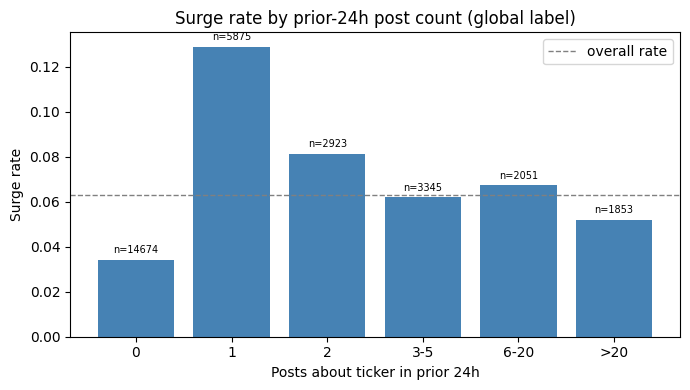

In [ ]:
bins = [-1, 0, 1, 2, 5, 20, 10**6]; bin_labels = ['0', '1', '2', '3-5', '6-20', '>20']
surge_by_prior = (label_frame.assign(cut=pd.cut(label_frame['ticker_post_rate_24h'], bins, labels=bin_labels))
                  .groupby('cut', observed=True)['surge_global'].agg(['mean', 'count']))
log('diagnostic.surge_by_prior_count', surge_by_prior.round(4).to_dict())

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(surge_by_prior.index.astype(str), surge_by_prior['mean'], color='steelblue')
ax.axhline(label_frame['surge_global'].mean(), ls='--', c='grey', lw=1, label='overall rate')
for i, (rate, n) in enumerate(zip(surge_by_prior['mean'], surge_by_prior['count'])):
    ax.text(i, rate+0.003, f'n={n}', ha='center', fontsize=7)
ax.set_xlabel('Posts about ticker in prior 24h'); ax.set_ylabel('Surge rate')
ax.set_title('Surge rate by prior-24h post count (global label)')
ax.legend(); fig.tight_layout()
save_fig(fig, 'surge_by_prior_count', 'Surge rate by prior-24h post count (global label)')
plt.show()

G_baseline_calendar        AUC 0.5027 [0.470,0.544]   AP 0.0510 F1 0.000 pred+ 0
G_baseline_temporal_lr     AUC 0.6630 [0.630,0.695]   AP 0.0772 F1 0.080 pred+ 492
G_v1                       AUC 0.7478 [0.721,0.772]   AP 0.1269 F1 0.135 pred+ 292
G_v2_betweenness           AUC 0.8157 [0.778,0.844]   AP 0.2070 F1 0.231 pred+ 283
G_v2e_eigenvector          AUC 0.8279 [0.795,0.854]   AP 0.2231 F1 0.263 pred+ 276
G_v2h_availability         AUC 0.8162 [0.780,0.844]   AP 0.2151 F1 0.244 pred+ 284
G_diag_2feat               AUC 0.7981 [0.754,0.831]   AP 0.2009 F1 0.211 pred+ 199
E_baseline_calendar        AUC 0.4365 [0.388,0.500]   AP 0.0788 F1 0.000 pred+ 0
E_baseline_temporal_lr     AUC 0.7737 [0.743,0.800]   AP 0.2434 F1 0.288 pred+ 1139
E_v1                       AUC 0.8005 [0.771,0.825]   AP 0.2957 F1 0.326 pred+ 1222
E_v2_betweenness           AUC 0.8221 [0.793,0.848]   AP 0.3236 F1 0.359 pred+ 1100
E_v2e_eigenvector          AUC 0.8276 [0.800,0.853]   AP 0.3305 F1 0.364 pred+ 1093
E_v2

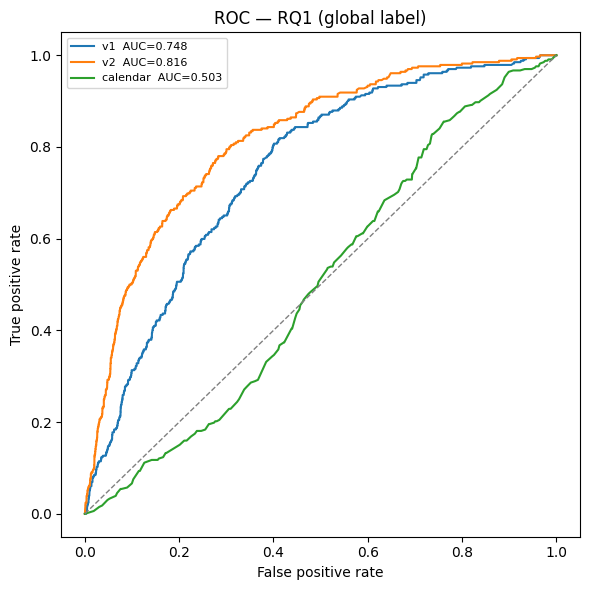

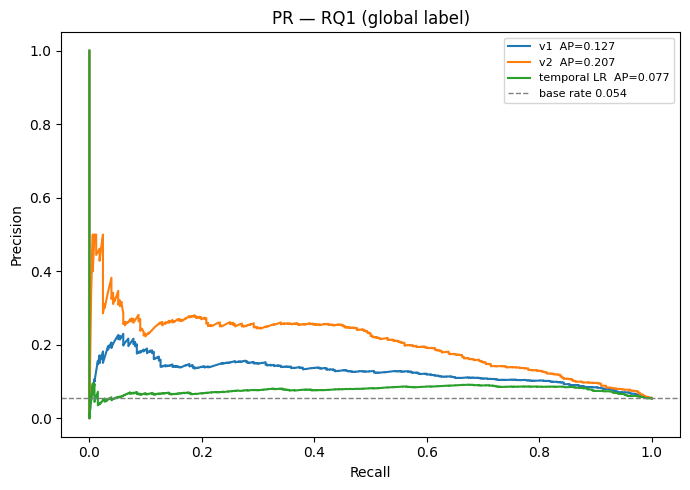

In [ ]:
R = {}
for lab, tag in [('global_z', 'G'), ('surge_emerge', 'E')]:
    for fk, nm, kw in [('calendar', 'baseline_calendar', dict(model_key='logreg')),
                       ('temporal', 'baseline_temporal_lr', dict(model_key='logreg')),
                       ('full_v1', 'v1', {}), ('full_v2', 'v2_betweenness', {}),
                       ('full_v2e', 'v2e_eigenvector', {}), ('full_v2h', 'v2h_availability', {}),
                       ('diagnostic', 'diag_2feat', {})]:
        R[f'{tag}_{nm}'] = fit_eval(df_exploded, fk, cfg, f'{tag}_{nm}', label=lab, **kw)
# Gradient boosting on the temporal features, to compare with the logistic regression.
R['G_temporal_gb'] = fit_eval(df_exploded, 'temporal', cfg, 'G_temporal_gb')
for name, run in R.items():
    m = run['metrics']
    ci = f"[{m['auc_ci_lo']:.3f},{m['auc_ci_hi']:.3f}]" if np.isfinite(m.get('auc_ci_lo', np.nan)) else ''
    print(f"{name:26s} AUC {m['auc']:.4f} {ci:15s} AP {m['ap']:.4f} F1 {m['f1']:.3f} pred+ {m['predicted_pos']}")

baselines = run_baselines(df_exploded, cfg, temporal_run=R['G_baseline_temporal_lr'])
print('\nBaselines (global label). Brier is blank for rank scores:')
print(pd.DataFrame(baselines).T[['auc', 'ap', 'brier', 'precision_at_budget', 'predicted_pos']]
      .astype(float).round(4).to_string())

print()
for tag, lab in [('G', 'global_z'), ('E', 'surge_emerge')]:
    cv = cv_stability(df_exploded, 'full_v2', cfg, f'{tag}_v2_betweenness', label=lab)
    print(f"{tag}: CV AUC {cv['auc'].mean():.4f} ± {cv['auc'].std():.4f} | AP {cv['ap'].mean():.4f}")

network_comparison = paired_block_comparison(R['G_v1'], R['G_v2_betweenness'], 'network_v1_vs_v2', cfg)
print(f"\nNetwork features (v2 minus v1): ΔAUC {network_comparison['delta_auc']:+.4f}, "
      f"ΔAP {network_comparison['delta_ap']:+.4f}")
if network_comparison['status'] == 'ok':
    print(f"  {network_comparison['interval_level']:.1%} interval for ΔAUC: "
          f"[{network_comparison['auc_ci_lo']:+.4f}, {network_comparison['auc_ci_hi']:+.4f}]")
plot_roc({'v1': R['G_v1'], 'v2': R['G_v2_betweenness'], 'calendar': R['G_baseline_calendar']},
         'roc_rq1', 'ROC — RQ1 (global label)')
plot_pr({'v1': R['G_v1'], 'v2': R['G_v2_betweenness'], 'temporal LR': R['G_baseline_temporal_lr']},
        'pr_rq1', 'PR — RQ1 (global label)')

label           model    auc  auc_ci_lo  auc_ci_hi     ap
    G              v1 0.7478     0.7214     0.7716 0.1269
    G v1 + popularity 0.8282     0.7920     0.8552 0.2225
    G              v2 0.8157     0.7781     0.8438 0.2070
    G v2 + popularity 0.8274     0.7911     0.8545 0.2207
    E              v1 0.8005     0.7708     0.8249 0.2957
    E v1 + popularity 0.8208     0.7919     0.8465 0.3288
    E              v2 0.8221     0.7926     0.8477 0.3236
    E v2 + popularity 0.8183     0.7891     0.8439 0.3224

ΔAUC, betweenness added (B minus A):
  G: without controls +0.0678 | with controls -0.0009 [-0.0041, +0.0023] (99.2%) -> no evidence of a gain beyond popularity
  E: without controls +0.0217 | with controls -0.0025 [-0.0061, +0.0003] (99.2%) -> no evidence of a gain beyond popularity

Spearman correlation with betweenness (training rows in the graph):
log_mentions_to_date    0.888
log_prior_q_mentions    0.893
log_prior_q_degree      0.910


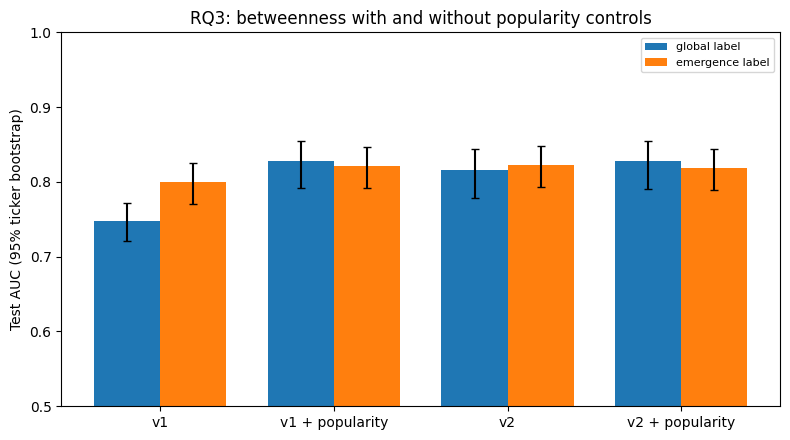

In [ ]:
from scipy.stats import spearmanr

# RQ3: does betweenness still help once the model knows how much, and how widely,
# a ticker has already been discussed?
rq3_rows, rq3_tests = [], {}
for lab, tag in [('global_z', 'G'), ('surge_emerge', 'E')]:
    R[f'{tag}_v1_pop'] = fit_eval(df_exploded, 'full_v1_pop', cfg, f'{tag}_v1_pop', label=lab)
    R[f'{tag}_v2_pop'] = fit_eval(df_exploded, 'full_v2_pop', cfg, f'{tag}_v2_pop', label=lab)
    for other in (f'{tag}_v1', f'{tag}_v2_betweenness'):
        pd.testing.assert_frame_equal(R[f'{tag}_v1_pop']['test_keys'], R[other]['test_keys'])
    rq3_tests[tag] = paired_block_comparison(R[f'{tag}_v1_pop'], R[f'{tag}_v2_pop'],
                                             f'network_beyond_popularity_{tag}', cfg)
    for model, key in [('v1', f'{tag}_v1'), ('v1 + popularity', f'{tag}_v1_pop'),
                       ('v2', f'{tag}_v2_betweenness'), ('v2 + popularity', f'{tag}_v2_pop')]:
        m = R[key]['metrics']
        rq3_rows.append({'label': tag, 'model': model, 'auc': m['auc'], 'auc_ci_lo': m['auc_ci_lo'],
                         'auc_ci_hi': m['auc_ci_hi'], 'ap': m['ap']})

rq3 = pd.DataFrame(rq3_rows)
safe_to_csv(rq3, RESULTS/'tables'/'tab_rq3_popularity.csv')
log('rq3_popularity.models', rq3.round(4).to_dict('records'))
print(rq3.round(4).to_string(index=False))

print('\nΔAUC, betweenness added (B minus A):')
auc = rq3.set_index(['label', 'model'])['auc']
for tag in ['G', 'E']:
    before = auc[(tag, 'v2')] - auc[(tag, 'v1')]
    test = rq3_tests[tag]
    interval = (f"[{test['auc_ci_lo']:+.4f}, {test['auc_ci_hi']:+.4f}]" if test['status'] == 'ok' else 'unavailable')
    verdict = 'interval excludes zero' if test['auc_ci_excludes_zero'] else 'no evidence of a gain beyond popularity'
    print(f"  {tag}: without controls {before:+.4f} | with controls {test['delta_auc']:+.4f} "
          f"{interval} ({test['interval_level']:.1%}) -> {verdict}")

# How closely betweenness tracks popularity, on training rows where the ticker is in the graph.
run = R['G_v2_pop']
train = run['data'].iloc[run['train_idx']]
train = train[train['log_prior_q_degree'] > 0]
correlation = {c: float(spearmanr(train['dynamic_betweenness'], train[c]).statistic) for c in POP_CONTROLS}
log('rq3_popularity.spearman_with_betweenness', correlation)
print('\nSpearman correlation with betweenness (training rows in the graph):')
print(pd.Series(correlation).round(3).to_string())

fig, ax = plt.subplots(figsize=(8, 4.5))
models = ['v1', 'v1 + popularity', 'v2', 'v2 + popularity']
x, w = np.arange(len(models)), 0.38
for i, (tag, name) in enumerate([('G', 'global label'), ('E', 'emergence label')]):
    part = rq3[rq3.label == tag].set_index('model').loc[models]
    ax.bar(x + (i - 0.5)*w, part['auc'], w, label=name,
           yerr=[part['auc'] - part['auc_ci_lo'], part['auc_ci_hi'] - part['auc']], capsize=3)
ax.set_xticks(x); ax.set_xticklabels(models)
ax.set_ylim(0.5, 1); ax.set_ylabel('Test AUC (95% ticker bootstrap)')
ax.set_title('RQ3: betweenness with and without popularity controls')
ax.legend(fontsize=8); fig.tight_layout()
save_fig(fig, 'rq3_popularity', 'Test AUC with and without popularity controls, both labels')
plt.show()

In [ ]:
subsets = {'all':                 df_exploded,
           'no_etf':              df_exploded[df_exploded.is_etf == 0],
           'post_feb':            df_exploded[df_exploded.created >= '2021-03-01'],
           'single_ticker_posts': df_exploded[df_exploded.num_tickers_mentioned == 1]}

print('Global-z thresholds are refitted per subset; emergence labels keep their full history.\n')
for lab, tag in [('global_z', 'G'), ('surge_emerge', 'E')]:
    print(f'--- label {tag} ---')
    for sn, sd in subsets.items():
        # 'all' is the main v2 model, already fitted above.
        m = (R[f'{tag}_v2_betweenness'] if sn == 'all'
             else fit_eval(sd, 'full_v2', cfg, f'{tag}_rob_{sn}', label=lab))['metrics']
        print(f"  {sn:20s} AUC {m['auc']:.4f} [{m['auc_ci_lo']:.3f},{m['auc_ci_hi']:.3f}] "
              f"AP {m['ap']:.3f} base {m['base_rate']:.3f} n {m['n_test']:5d} win {m['test_window']}")

Global-z thresholds are refitted per subset; emergence labels keep their full history.

--- label G ---
  all                  AUC 0.8157 [0.778,0.844] AP 0.207 base 0.054 n  6145 win 2021-10-11 12:58:02 to 2021-12-30 22:21:41
  no_etf               AUC 0.7840 [0.745,0.815] AP 0.152 base 0.049 n  5022 win 2021-10-11 12:41:00 to 2021-12-30 22:21:41
  post_feb             AUC 0.8023 [0.766,0.831] AP 0.391 base 0.120 n  4471 win 2021-11-01 21:43:12 to 2021-12-30 22:21:41
  single_ticker_posts  AUC 0.7230 [0.668,0.778] AP 0.128 base 0.050 n  1961 win 2021-09-18 06:20:17 to 2021-12-30 22:21:41
--- label E ---
  all                  AUC 0.8221 [0.793,0.848] AP 0.324 base 0.084 n  6090 win 2021-10-12 11:22:16 to 2021-12-30 22:21:41
  no_etf               AUC 0.8215 [0.790,0.848] AP 0.343 base 0.081 n  4983 win 2021-10-12 01:52:25 to 2021-12-30 22:21:41
  post_feb             AUC 0.7898 [0.757,0.821] AP 0.176 base 0.065 n  4471 win 2021-11-01 21:43:12 to 2021-12-30 22:21:41
  single_ticker_pos

--- label G: full_v2 AUC 0.8157 ---
  drop temporal   AUC 0.7518  Δ -0.0639   |  temporal-only 0.7370
  drop calendar   AUC 0.8105  Δ -0.0052   |  calendar-only 0.5548
  drop content    AUC 0.8140  Δ -0.0017   |  content-only 0.5434
  drop sentiment  AUC 0.8158  Δ +0.0002   |  sentiment-only 0.5473
  drop network    AUC 0.7478  Δ -0.0678   |  network-only 0.7430
  drop etf        AUC 0.8155  Δ -0.0002   |  etf-only 0.5363
--- label E: full_v2 AUC 0.8221 ---
  drop temporal   AUC 0.7604  Δ -0.0617   |  temporal-only 0.7954
  drop calendar   AUC 0.8159  Δ -0.0062   |  calendar-only 0.4944
  drop content    AUC 0.8233  Δ +0.0012   |  content-only 0.5441
  drop sentiment  AUC 0.8220  Δ -0.0001   |  sentiment-only 0.5305
  drop network    AUC 0.8005  Δ -0.0217   |  network-only 0.7523
  drop etf        AUC 0.8223  Δ +0.0001   |  etf-only 0.4870


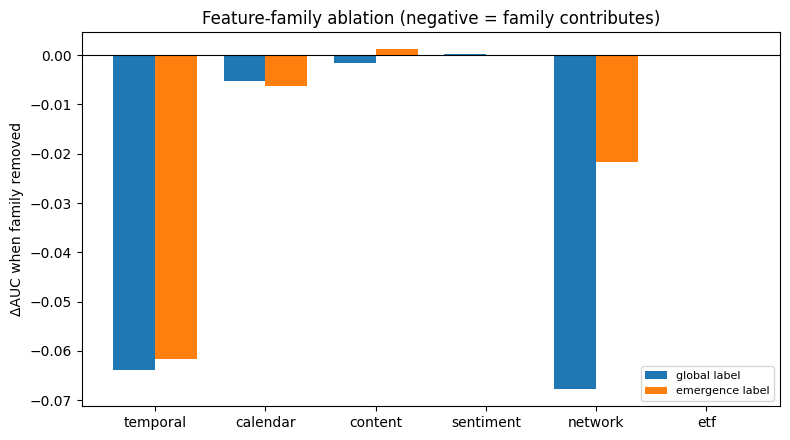

In [ ]:
FAM = {'temporal':  ['ticker_post_rate_24h', 'time_since_previous', 'ticker_post_acceleration'],
       'calendar':  ['hour_of_day', 'day_of_week'],
       'content':   ['title_length', 'word_count', 'num_tickers_mentioned'],
       'sentiment': ['sentiment_score'],
       'network':   ['dynamic_betweenness'],
       'etf':       ['is_etf']}

abl, ABL_RUNS = [], {}
for lab, tag in [('global_z', 'G'), ('surge_emerge', 'E')]:
    full = R[f'{tag}_v2_betweenness']['metrics']['auc']   # the main v2 model
    print(f'--- label {tag}: full_v2 AUC {full:.4f} ---')
    for family, cols in FAM.items():
        without = [x for x in FEATURE_SETS['full_v2'] if x not in cols]
        for kind, features in [('minus', without), ('only', cols)]:
            name = f'{tag}_abl_{kind}_{family}'
            ABL_RUNS[name] = fit_eval(df_exploded, features, cfg, name, label=lab, with_ci=False)
        a = ABL_RUNS[f'{tag}_abl_minus_{family}']['metrics']['auc']
        o = ABL_RUNS[f'{tag}_abl_only_{family}']['metrics']['auc']
        abl.append({'label': tag, 'family': family, 'full': full, 'delta_drop': a - full, 'only': o})
        print(f"  drop {family:10s} AUC {a:.4f}  Δ {a-full:+.4f}   |  {family}-only {o:.4f}")

abl = pd.DataFrame(abl)
safe_to_csv(abl, RESULTS/'tables'/'tab_ablation.csv')
log('ablation', abl.round(4).to_dict('records'))

fig, ax = plt.subplots(figsize=(8, 4.5))
fams = list(FAM); x = np.arange(len(fams)); w = 0.38
for i, (tag, lb) in enumerate([('G', 'global label'), ('E', 'emergence label')]):
    v = [abl[(abl.label == tag) & (abl.family == f)]['delta_drop'].iloc[0] for f in fams]
    ax.bar(x + (i - 0.5) * w, v, w, label=lb)
ax.axhline(0, c='k', lw=0.8); ax.set_xticks(x); ax.set_xticklabels(fams)
ax.set_ylabel('ΔAUC when family removed')
ax.set_title('Feature-family ablation (negative = family contributes)')
ax.legend(fontsize=8); fig.tight_layout()
save_fig(fig, 'ablation', 'Feature-family ablation, both labels'); plt.show()

none      CV AUC 0.7970 | test AUC 0.8157 AP 0.207 Brier 0.0473 precision 0.251 recall 0.214 pred+ 283
smote     CV AUC 0.7813 | test AUC 0.7842 AP 0.180 Brier 0.0871 precision 0.223 recall 0.229 pred+ 341
balanced  CV AUC 0.7958 | test AUC 0.8191 AP 0.214 Brier 0.1019 precision 0.272 recall 0.271 pred+ 331

Planned comparisons so far (B minus A), Bonferroni-corrected intervals (imbalance: A = balanced, B = none):
network_v1_vs_v2: ΔAUC=+0.0678 [+0.0384, +0.0940]  ΔAP=+0.0801
network_beyond_popularity_G: ΔAUC=-0.0009 [-0.0041, +0.0023]  ΔAP=-0.0018
network_beyond_popularity_E: ΔAUC=-0.0025 [-0.0061, +0.0003]  ΔAP=-0.0064
imbalance_selected_vs_runner_up: ΔAUC=-0.0034 [-0.0068, +0.0003]  ΔAP=-0.0073


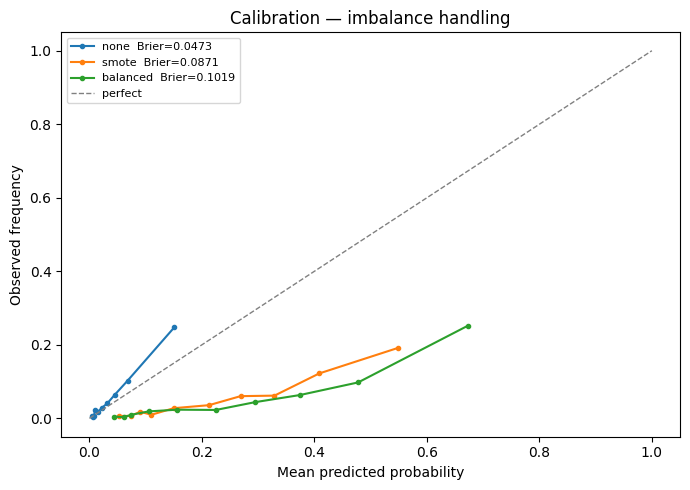

In [ ]:
# Test-set view of the imbalance arms at the selected gradient-boosting settings. The arm
# chosen by training CV (section 4.1) is the headline model; the planned comparison tests it
# against the CV runner-up.
arms = {arm: (R['G_v2_betweenness'] if arm == cfg.imbalance
              else fit_eval(df_exploded, 'full_v2', cfg, f'imb_{arm}', imbalance=arm))
        for arm in IMBALANCE_ARMS}
for arm, run in arms.items():
    m = run['metrics']
    print(f"{arm:9s} CV AUC {imbalance_cv[arm]:.4f} | test AUC {m['auc']:.4f} AP {m['ap']:.3f} "
          f"Brier {m['brier']:.4f} precision {m['precision']:.3f} recall {m['recall']:.3f} "
          f"pred+ {m['predicted_pos']}")

imbalance_comparison = paired_block_comparison(arms[runner_up_imbalance], arms[cfg.imbalance],
                                               'imbalance_selected_vs_runner_up', cfg)
print(f'\nPlanned comparisons so far (B minus A), Bonferroni-corrected intervals '
      f'(imbalance: A = {runner_up_imbalance}, B = {cfg.imbalance}):')
for name, result in REPORT['significance']['block_bootstrap'].items():
    bounds = (f"[{result['auc_ci_lo']:+.4f}, {result['auc_ci_hi']:+.4f}]" if result['status'] == 'ok' else 'unavailable')
    print(f"{name}: ΔAUC={result['delta_auc']:+.4f} {bounds}  ΔAP={result['delta_ap']:+.4f}")
plot_calibration(arms, 'calibration_imbalance', 'Calibration — imbalance handling')

The budget is a cap, so fewer alerts than allowed can be issued.
 budget  precision_at_budget  lift_at_budget  recall_at_budget  alerts  alerts_per_day  tickerdays  test_days
      3                0.264           5.501             0.172     140           1.750        4475         80
      5                0.257           5.352             0.209     175           2.188        4475         80
     10                0.256           5.319             0.214     180           2.250        4475         80
     20                0.256           5.319             0.214     180           2.250        4475         80
     30                0.256           5.319             0.214     180           2.250        4475         80


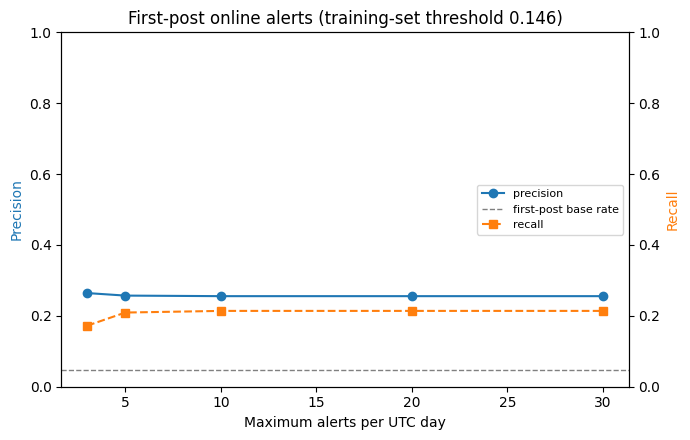

In [ ]:
headline = R['G_v2_betweenness']
headline_data, headline_te = headline['data'], headline['test_idx']
threshold = headline['metrics']['decision_threshold']   # set on the training rows in fit_eval
curve = []
for budget in [3, 5, 10, 20, 30]:
    point = precision_at_budget_tickerday(headline['y'], headline['prob'],
                                          headline_data['created'].iloc[headline_te],
                                          headline_data['ticker'].iloc[headline_te],
                                          replace(cfg, alert_budget_per_day=budget),
                                          threshold=threshold, post_ids=headline_data.id.iloc[headline_te])
    curve.append({'budget': budget, **point})
curve = pd.DataFrame(curve)
curve['alerts_per_day'] = curve['alerts'] / curve['test_days']
log('operating_point.budget_curve', curve.to_dict('records'))
print('The budget is a cap, so fewer alerts than allowed can be issued.')
print(curve[['budget', 'precision_at_budget', 'lift_at_budget', 'recall_at_budget', 'alerts',
             'alerts_per_day', 'tickerdays', 'test_days']].round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(curve.budget, curve.precision_at_budget, marker='o', c='C0', label='precision')
ax.axhline(curve['tickerday_base_rate'].iloc[0], ls='--', c='grey', lw=1, label='first-post base rate')
ax.set_xlabel('Maximum alerts per UTC day'); ax.set_ylabel('Precision', color='C0'); ax.set_ylim(0, 1)
ax2 = ax.twinx()
ax2.plot(curve.budget, curve.recall_at_budget, marker='s', ls='--', c='C1', label='recall')
ax2.set_ylabel('Recall', color='C1'); ax2.set_ylim(0, 1)
ax.set_title(f'First-post online alerts (training-set threshold {threshold:.3f})')
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, fontsize=8, loc='center right')
fig.tight_layout()
save_fig(fig, 'operating_point', 'Alert precision and recall at the training-set threshold and varying daily cap'); plt.show()

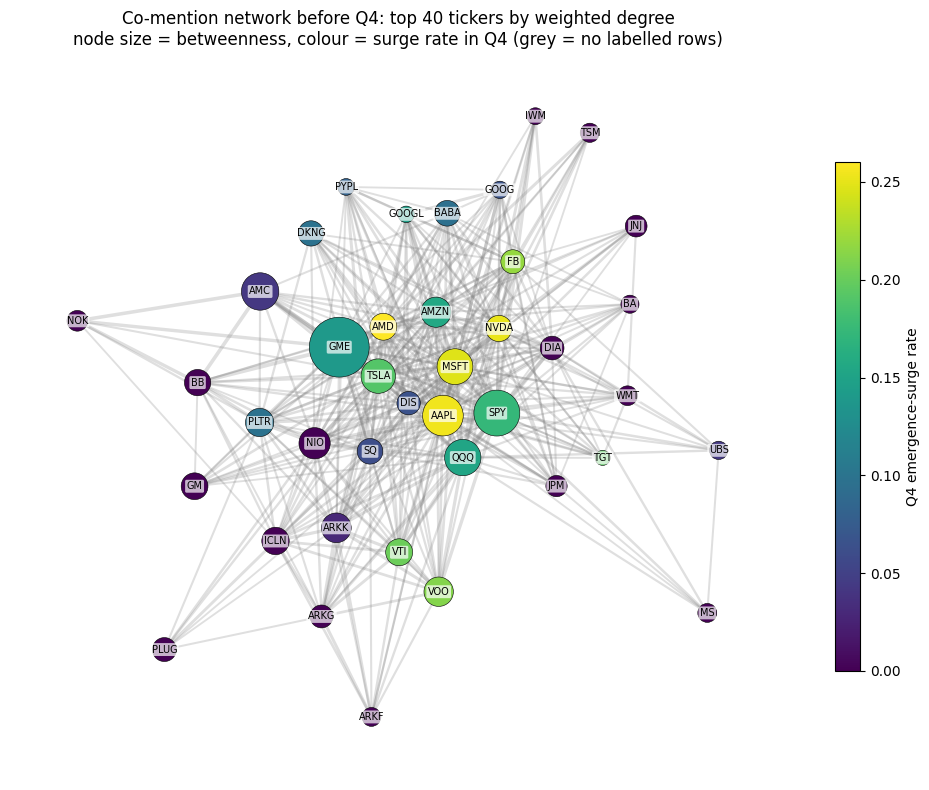

36 communities in the prior graph; the 8 largest:
 community  tickers                  top_tickers  q_rows  surge_rate  share_of_q_surges
         0      550       GME AMC NIO PLTR BB GM    1074       0.031              0.063
         1      410     SPY QQQ DIA BABA JPM IWM    1802       0.065              0.223
         2      312  ARKK VTI ICLN VOO ARKG ARKF     500       0.093              0.088
         3      310 AAPL MSFT TSLA AMZN NVDA AMD    2435       0.125              0.578
         4      222    DKNG PENN AAL DAL MGM GPN     235       0.030              0.013
         5      194   PLUG ENPH SEDG XOM CVX UPS     221       0.009              0.004
         6      126     SCHW PGR KREF GIS CCI IQ      39       0.000              0.000
         7      119   CRSP LEN DHI DNA COHR LITE     106       0.000              0.000


In [ ]:
# The graph behind the Q4 features, each ticker coloured by its Q4 surge rate.
Q_SHOW, TOP_N = 4, 40
G = GRAPHS[Q_SHOW]
strength = dict(G.degree(weight='weight'))
top_nodes = sorted(strength, key=lambda n: (-strength[n], n))[:TOP_N]
H = G.subgraph(top_nodes).copy()
# Keep edges at or above the median weight so the plot is readable.
cut = np.median([w for _, _, w in H.edges(data='weight')])
H.remove_edges_from([(a, b) for a, b, w in H.edges(data='weight') if w < cut])
for a, b, w in H.edges(data='weight'):
    H[a][b]['log_weight'] = np.log1p(w)

q_rows = df_exploded[df_exploded['quarter'] == Q_SHOW]
surge_rate = q_rows.groupby('ticker')['surge_emerge'].mean()   # censored rows are NaN and skipped
betweenness = PIPE['cent'].query('quarter == @Q_SHOW').set_index('ticker')['dynamic_betweenness']

nodes = list(H)
layout = nx.spring_layout(H, weight='log_weight', seed=cfg.seed, k=1.2/np.sqrt(len(nodes)))
colour = np.array([surge_rate.get(n, np.nan) for n in nodes], dtype=float)
size = 60 + 1800*np.array([betweenness.get(n, 0.0) for n in nodes])/max(betweenness.max(), 1e-12)
widths = [0.3 + 0.5*H[a][b]['log_weight'] for a, b in H.edges()]

fig, ax = plt.subplots(figsize=(10, 8))
nx.draw_networkx_edges(H, layout, ax=ax, width=widths, alpha=0.25, edge_color='grey')
unlabelled = np.isnan(colour)
if unlabelled.any():
    nx.draw_networkx_nodes(H, layout, ax=ax, nodelist=[n for n, u in zip(nodes, unlabelled) if u],
                           node_size=size[unlabelled], node_color='lightgrey', edgecolors='k', linewidths=0.4)
drawn = nx.draw_networkx_nodes(H, layout, ax=ax, nodelist=[n for n, u in zip(nodes, unlabelled) if not u],
                               node_size=size[~unlabelled], node_color=colour[~unlabelled], cmap='viridis',
                               vmin=0, vmax=np.nanmax(colour) if (~unlabelled).any() else 1,
                               edgecolors='k', linewidths=0.4)
nx.draw_networkx_labels(H, layout, ax=ax, font_size=7,
                        bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=0.7))
fig.colorbar(drawn, ax=ax, shrink=0.7, label=f'Q{Q_SHOW} emergence-surge rate')
ax.set_title(f'Co-mention network before Q{Q_SHOW}: top {TOP_N} tickers by weighted degree\n'
             f'node size = betweenness, colour = surge rate in Q{Q_SHOW} (grey = no labelled rows)')
ax.axis('off'); fig.tight_layout()
save_fig(fig, 'comention_network',
         f'Prior co-mention network for Q{Q_SHOW} features; size is betweenness, colour is Q{Q_SHOW} surge rate')
plt.show()

def quarterly_communities(graphs, seed):
    """Louvain partition of each quarter's prior graph. Each community is named after its
    highest-strength ticker; membership can change between quarters.
    Returns (one row per quarter and ticker, {quarter: partition})."""
    rows, partitions = [], {}
    for q, graph in graphs.items():
        if graph.number_of_edges() == 0:
            continue
        strength_q = dict(graph.degree(weight='weight'))
        partitions[q] = nx.community.louvain_communities(graph, weight='weight', seed=seed)
        modularity = nx.community.modularity(graph, partitions[q], weight='weight')
        for members in partitions[q]:
            anchor = max(members, key=lambda n: (strength_q[n], n))
            rows.extend({'quarter': q, 'ticker': ticker, 'community': anchor,
                         'community_size': len(members), 'quarter_modularity': modularity}
                        for ticker in members)
    table = pd.DataFrame(rows, columns=['quarter', 'ticker', 'community', 'community_size', 'quarter_modularity'])
    return table, partitions

if cfg.network != 'strict_prior':
    raise ValueError('The community analysis needs past-only graphs (strict_prior).')

# Louvain communities in each prior graph; the Q4 partition is summarised here and all
# quarters are used as model features in the next cell.
communities, PARTITIONS = quarterly_communities(GRAPHS, cfg.seed)
louvain = PARTITIONS[Q_SHOW]
community_rows = []
for k, members in enumerate(sorted(louvain, key=len, reverse=True)[:8]):
    rows_ = q_rows[q_rows['ticker'].isin(members)]
    community_rows.append({
        'community': k, 'tickers': len(members),
        'top_tickers': ' '.join(sorted(members, key=lambda n: -strength[n])[:6]),
        'q_rows': len(rows_), 'surge_rate': float(rows_['surge_emerge'].mean()) if len(rows_) else np.nan,
        'share_of_q_surges': float(rows_['surge_emerge'].sum() / max(q_rows['surge_emerge'].sum(), 1))})
community_table = pd.DataFrame(community_rows)
safe_to_csv(community_table, RESULTS/'tables'/'tab_communities.csv')
log('network.communities', {'quarter': Q_SHOW, 'n_communities': len(louvain),
                            'modularity': float(communities.loc[communities.quarter == Q_SHOW, 'quarter_modularity'].iloc[0]),
                            'largest': community_table.round(4).to_dict('records')})
print(f'{len(louvain)} communities in the prior graph; the 8 largest:')
print(community_table.round(3).to_string(index=False))

In [ ]:
# Community indicators on top of the popularity controls.
N_COMMUNITIES = 8

# `communities` (all quarters) comes from the previous cell.
df_exploded = (df_exploded.drop(columns=['community', 'community_size'], errors='ignore')
               .merge(communities.drop(columns=['quarter_modularity']), on=['quarter', 'ticker'],
                      how='left', validate='many_to_one', sort=False))
df_exploded['community'] = df_exploded['community'].fillna('none')
log('network.communities_by_quarter', {
    'quarters': communities.groupby('quarter').community.nunique().to_dict(),
    'modularity': communities.groupby('quarter').quarter_modularity.first().round(4).to_dict(),
    'rows_without_community': int(df_exploded.community.eq('none').sum())})

comm_rows, comm_tests = [], {}
for lab, tag in [('global_z', 'G'), ('surge_emerge', 'E')]:
    baseline = R[f'{tag}_v1_pop']
    # Choose the indicator categories from the baseline's training rows only.
    training = baseline['data'].iloc[baseline['train_idx']][ROW_KEYS].copy()
    training['quarter'] = training.created.dt.quarter
    training = training.merge(communities[['quarter', 'ticker', 'community']], on=['quarter', 'ticker'],
                              how='left', validate='many_to_one', sort=False)
    kept = (training['community'].value_counts().sort_index()
            .sort_values(ascending=False, kind='stable').head(N_COMMUNITIES).index.tolist())

    model_frame = df_exploded.copy()
    community_features = [f'comm_{name}' for name in kept] + ['comm_other', 'comm_none']
    for name in kept:
        model_frame[f'comm_{name}'] = model_frame.community.eq(name).astype(int)
    model_frame['comm_none'] = model_frame.community.eq('none').astype(int)
    model_frame['comm_other'] = (~model_frame.community.isin(kept + ['none'])).astype(int)
    assert model_frame[community_features].sum(axis=1).eq(1).all()

    log(f'network.community_encoding.{tag}', {'kept': kept, 'training_rows': len(training)})
    print(f'{tag}: categories chosen from {len(training)} training rows: {kept}')
    run = fit_eval(model_frame, [*FEATURE_SETS['full_v1_pop'], *community_features], cfg,
                   f'{tag}_v1_pop_comm', label=lab)
    # Same training and test rows as the baseline.
    pd.testing.assert_frame_equal(run['data'].iloc[run['train_idx']][ROW_KEYS].reset_index(drop=True),
                                  baseline['data'].iloc[baseline['train_idx']][ROW_KEYS].reset_index(drop=True))
    R[f'{tag}_v1_pop_comm'] = run
    comm_tests[tag] = paired_block_comparison(baseline, run, f'community_beyond_popularity_{tag}', cfg)
    for model, key in [('v1 + popularity', f'{tag}_v1_pop'),
                       ('v1 + popularity + community', f'{tag}_v1_pop_comm'),
                       ('v2 + popularity', f'{tag}_v2_pop')]:
        comm_rows.append({'label': tag, 'model': model, 'auc': R[key]['metrics']['auc'], 'ap': R[key]['metrics']['ap']})

comm_models = pd.DataFrame(comm_rows)
safe_to_csv(comm_models, RESULTS/'tables'/'tab_community_models.csv')
print(comm_models.round(4).to_string(index=False))

print('\nΔAUC, community indicators added to v1 + popularity:')
for tag in ['G', 'E']:
    result = comm_tests[tag]
    interval = (f"[{result['auc_ci_lo']:+.4f}, {result['auc_ci_hi']:+.4f}] ({result['interval_level']:.1%})"
                if result['status'] == 'ok' else f"interval unavailable ({result['status']})")
    print(f"  {tag}: {result['delta_auc']:+.4f} {interval}")

# Descriptive rates per community. Overlapping windows are not independent trials, and the
# 'none' group is mostly Q1, before any prior graph exists.
labelled = df_exploded.dropna(subset=['surge_emerge'])
community_rates = (labelled.groupby('community')
                   .agg(tickers=('ticker', 'nunique'), rows=('surge_emerge', 'size'), surges=('surge_emerge', 'sum'))
                   .reset_index())
community_rates['surges'] = community_rates.surges.astype(int)
community_rates['surge_rate'] = community_rates.surges / community_rates.rows
community_rates['share_of_surges'] = community_rates.surges / max(community_rates.surges.sum(), 1)
community_rates = community_rates.sort_values('surges', ascending=False)
safe_to_csv(community_rates, RESULTS/'tables'/'tab_community_rates.csv')
log('network.community_rates', community_rates.round(4).to_dict('records'))
print('\nEmergence surges by community anchor (descriptive):')
print(community_rates.head(10).round(4).to_string(index=False))

G: categories chosen from 24545 training rows: ['AAPL', 'GME', 'ARKK', 'SPY', 'MS', 'DKNG', 'NIO', 'PLUG']
E: categories chosen from 24273 training rows: ['AAPL', 'GME', 'ARKK', 'SPY', 'MS', 'DKNG', 'NIO', 'PLUG']
label                       model    auc     ap
    G             v1 + popularity 0.8282 0.2225
    G v1 + popularity + community 0.8289 0.2239
    G             v2 + popularity 0.8274 0.2207
    E             v1 + popularity 0.8208 0.3288
    E v1 + popularity + community 0.8211 0.3289
    E             v2 + popularity 0.8183 0.3224

ΔAUC, community indicators added to v1 + popularity:
  G: +0.0007 [-0.0005, +0.0015] (99.2%)
  E: +0.0003 [-0.0001, +0.0011] (99.2%)

Emergence surges by community anchor (descriptive):
community  tickers  rows  surges  surge_rate  share_of_surges
     none      366 11716    2879      0.2457           0.6974
     AAPL      177  6567     613      0.0933           0.1485
      GME      209  3093     227      0.0734           0.0550
      SPY      

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: Esti

mean RMSE of next-day post count (50 tickers with usable ARIMA forecasts):
rmse_persist    1.057
rmse_snaive     1.110
rmse_mean       1.088
rmse_arima      0.877

ARIMA beats persistence on 46/50 tickers (Wilcoxon signed-rank p = 9.77e-09); mean RMSE 17.0% below persistence
test window 2021-10-19 to 2021-12-30


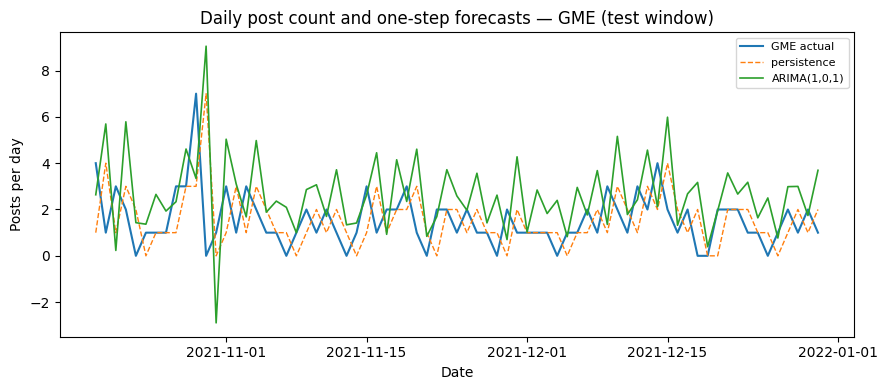

In [ ]:
from scipy.stats import wilcoxon

# Daily post counts for the 50 most-mentioned tickers on training days. The first and
# last corpus days may be partial and are dropped. The split is on calendar days.
ts_frame = PIPE['meta']['mentions_frame'][['ticker', 'created']].copy()
ts_frame['day'] = ts_frame.created.dt.normalize()
raw_times = PIPE['meta']['raw_frame'].created
days = pd.date_range(raw_times.min().normalize(), raw_times.max().normalize(), freq='D')[1:-1]
split = int(len(days) * cfg.train_frac)
ts_frame = ts_frame[ts_frame.day.isin(days)]
top = ts_frame.loc[ts_frame.day < days[split], 'ticker'].value_counts().head(50).index
daily = (ts_frame[ts_frame.ticker.isin(top)].groupby(['ticker', 'day']).size()
         .unstack('day').reindex(index=top, columns=days).fillna(0.0))

def rmse(actual, forecast):
    return float(np.sqrt(np.nanmean((actual - forecast) ** 2)))

forecast_rows, arima_forecasts = [], {}
for ticker in top:
    series = daily.loc[ticker]
    train_counts, test_counts = series.iloc[:split].values, series.iloc[split:].values
    forecasts, failure = arima_one_step(train_counts, test_counts)
    if failure:
        print(f'{ticker}: ARIMA excluded from the paired comparison ({failure})')
    else:
        arima_forecasts[ticker] = forecasts
    arima_ok = failure is None
    forecast_rows.append({'ticker': ticker, 'arima_ok': arima_ok, 'arima_failure': failure,
                          'rmse_persist': rmse(test_counts, series.shift(1).iloc[split:].values),
                          'rmse_snaive': rmse(test_counts, series.shift(7).iloc[split:].values),
                          'rmse_mean': rmse(test_counts, np.full(len(test_counts), train_counts.mean())),
                          'rmse_arima': rmse(test_counts, forecasts) if arima_ok else np.nan})

ts = pd.DataFrame(forecast_rows)
safe_to_csv(ts, RESULTS/'tables'/'tab_rmse_top50.csv')
rmse_cols = ['rmse_persist', 'rmse_snaive', 'rmse_mean', 'rmse_arima']
paired = ts[ts.arima_ok]                       # every method on the same tickers
arima_gain = paired.rmse_arima - paired.rmse_persist
wilcoxon_p = float(wilcoxon(arima_gain).pvalue) if len(paired) >= 10 and arima_gain.abs().sum() > 0 else np.nan
reduction = 1 - paired.rmse_arima.mean()/paired.rmse_persist.mean()
log('timeseries', {
    'n': len(ts), 'arima_ok': int(ts.arima_ok.sum()),
    'mean_rmse': paired[rmse_cols].mean().round(3).to_dict(),
    'median_rmse': paired[rmse_cols].median().round(3).to_dict(),
    'arima_beats_persist': int((arima_gain < 0).sum()),
    'arima_beats_snaive': int((paired.rmse_arima < paired.rmse_snaive).sum()),
    'arima_beats_mean': int((paired.rmse_arima < paired.rmse_mean).sum()),
    'arima_minus_persist_wilcoxon_p': wilcoxon_p,
    'rmse_reduction_vs_persistence': float(reduction),
    'test_days': f'{days[split].date()} to {days[-1].date()}',
    'note': 'Calendar-day split, so the test window differs from the classifiers.'})

print(f'mean RMSE of next-day post count ({len(paired)} tickers with usable ARIMA forecasts):')
print(paired[rmse_cols].mean().round(3).to_string())
print(f"\nARIMA beats persistence on {(arima_gain < 0).sum()}/{len(paired)} tickers "
      f"(Wilcoxon signed-rank p = {wilcoxon_p:.3g}); mean RMSE {reduction:.1%} below persistence")
print(f'test window {days[split].date()} to {days[-1].date()}')

example = top[0]
example_series = daily.loc[example]
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(days[split:], example_series.iloc[split:].values, lw=1.5, label=f'{example} actual')
ax.plot(days[split:], example_series.shift(1).iloc[split:].values, lw=1, ls='--', label='persistence')
if example in arima_forecasts:
    ax.plot(days[split:], arima_forecasts[example], lw=1.2, label='ARIMA(1,0,1)')
ax.set_xlabel('Date'); ax.set_ylabel('Posts per day')
ax.set_title(f'Daily post count and one-step forecasts — {example} (test window)')
ax.legend(fontsize=8); fig.tight_layout()
save_fig(fig, 'tickerday_series', f'Daily post count and one-step forecasts, {example}, test window'); plt.show()

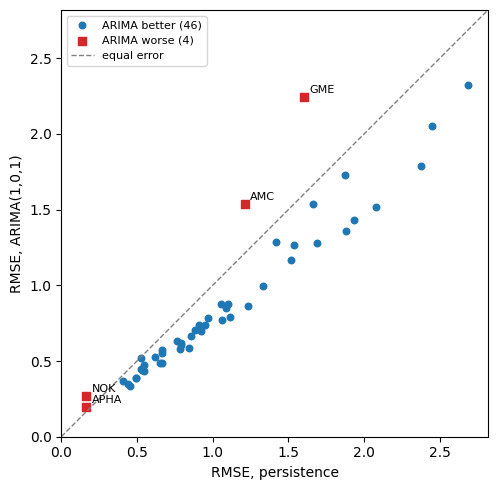

In [ ]:
# Every ticker's ARIMA error against its persistence error (points below the line = ARIMA better).
fig, ax = plt.subplots(figsize=(5.2, 5))
worse = paired.rmse_arima > paired.rmse_persist
ax.scatter(paired.rmse_persist[~worse], paired.rmse_arima[~worse], s=22, c='tab:blue',
           label=f'ARIMA better ({(~worse).sum()})')
ax.scatter(paired.rmse_persist[worse], paired.rmse_arima[worse], s=30, c='tab:red', marker='s',
           label=f'ARIMA worse ({worse.sum()})')
for _, row in paired[worse].iterrows():
    ax.annotate(row.ticker, (row.rmse_persist, row.rmse_arima), xytext=(4, 3),
                textcoords='offset points', fontsize=8)
lim = 1.05 * paired[['rmse_persist', 'rmse_arima']].to_numpy().max()
ax.plot([0, lim], [0, lim], ls='--', c='grey', lw=1, label='equal error')
ax.set(xlim=(0, lim), ylim=(0, lim), aspect='equal',
       xlabel='RMSE, persistence', ylabel='RMSE, ARIMA(1,0,1)')
ax.legend(fontsize=8, loc='upper left')
fig.tight_layout()
save_fig(fig, 'arima_vs_persistence',
         'Test RMSE of one-step daily forecasts, ARIMA against persistence, 50 most-mentioned tickers')
plt.show()

In [ ]:
cfg_p = replace(cfg, subreddit='pennystocks')
PIPE_P = run_pipeline(cfg_p)
df_p = PIPE_P['df']
log('dataset.pennystocks', {'after_cleaning': PIPE_P['meta']['raw'], 'rows': len(df_p),
                            'tickers': int(df_p.ticker.nunique()), 'has_network': float(df_p.has_network.mean())})
print(f"pennystocks: {PIPE_P['meta']['raw']} cleaned | {len(df_p)} rows | "
      f"{df_p.ticker.nunique()} tickers | has_network {df_p.has_network.mean():.3f}\n")

for lab, tag in [('global_z', 'G'), ('surge_emerge', 'E')]:
    print(f'--- label {tag} ---')
    for fk, nm, kw in [('temporal', 'baseline_temporal_lr', dict(model_key='logreg')),
                       ('full_v1', 'v1', {}), ('full_v2', 'v2_betweenness', {}),
                       ('diagnostic', 'diag_2feat', {})]:
        m = fit_eval(df_p, fk, cfg_p, f'P_{tag}_{nm}', label=lab, **kw)['metrics']
        print(f"  {nm:22s} AUC {m['auc']:.4f} [{m['auc_ci_lo']:.3f},{m['auc_ci_hi']:.3f}] "
              f"AP {m['ap']:.3f} base {m['base_rate']:.3f} lift {m['lift_at_budget']:.2f}")

# Does the surge-rate pattern by prior-24h count also appear in r/pennystocks?
dp, yp, _, _, _ = global_label_rows(df_p, cfg_p)
tabp = (dp.assign(surge=yp, cut=pd.cut(dp['ticker_post_rate_24h'], bins, labels=bin_labels))
          .groupby('cut', observed=True)['surge'].mean())
log('diagnostic.pennystocks.surge_by_prior_count', tabp.round(4).to_dict())
print('\npennystocks surge rate by prior-24h count:')
print(tabp.round(4).to_string())

[hit ] sentiment_textblob_pennystocks
[calc] features_pennystocks: 6.2s
[calc] centrality_pennystocks: 22.2s
pennystocks: 49141 cleaned | 12435 rows | 463 tickers | has_network 0.491

--- label G ---
  baseline_temporal_lr   AUC 0.7222 [0.672,0.787] AP 0.056 base 0.023 lift 0.00
  v1                     AUC 0.7603 [0.701,0.837] AP 0.070 base 0.023 lift 6.50
  v2_betweenness         AUC 0.7751 [0.713,0.847] AP 0.073 base 0.023 lift 4.50
  diag_2feat             AUC 0.7687 [0.700,0.837] AP 0.074 base 0.023 lift 6.93
--- label E ---
  baseline_temporal_lr   AUC 0.8423 [0.792,0.886] AP 0.278 base 0.053 lift 9.11
  v1                     AUC 0.8631 [0.821,0.905] AP 0.298 base 0.053 lift 11.44
  v2_betweenness         AUC 0.8717 [0.831,0.913] AP 0.297 base 0.053 lift 10.63
  diag_2feat             AUC 0.8518 [0.785,0.905] AP 0.290 base 0.053 lift 7.74

pennystocks surge rate by prior-24h count:
cut
0       0.0323
1       0.1233
2       0.0705
3-5     0.0581
6-20    0.0689
>20     0.0000


In [ ]:
print(f'Sensitivity to tau (headline tau={cfg.tau} from Config):')
for t in [0.5, 1.0, 1.5, 2.0]:
    # The headline tau is the main v2 model, already fitted above.
    m = (R['G_v2_betweenness'] if t == cfg.tau
         else fit_eval(df_exploded, 'full_v2', replace(cfg, tau=t), f'tau_{t}'))['metrics']
    print(f"tau {t:.1f}: train surge {m['train_surge_rate']:.3f} test {m['base_rate']:.3f} | "
          f"AUC {m['auc']:.4f} [{m['auc_ci_lo']:.3f},{m['auc_ci_hi']:.3f}] "
          f"AP {m['ap']:.3f} P@budget {m['precision_at_budget']:.3f}")

Sensitivity to tau (headline tau=1.0 from Config):
tau 0.5: train surge 0.144 test 0.122 | AUC 0.7988 [0.768,0.822] AP 0.393 P@budget 0.461
tau 1.0: train surge 0.065 test 0.054 | AUC 0.8157 [0.778,0.844] AP 0.207 P@budget 0.256
tau 1.5: train surge 0.031 test 0.021 | AUC 0.7985 [0.753,0.842] AP 0.070 P@budget 0.107
tau 2.0: train surge 0.027 test 0.019 | AUC 0.8162 [0.767,0.859] AP 0.077 P@budget 0.089


In [ ]:
import yfinance as yf

# Market-data tickers are chosen from the model's training rows only.
mkt_run = R['G_v2_betweenness']
mkt_data, mkt_tr, mkt_te = mkt_run['data'], mkt_run['train_idx'], mkt_run['test_idx']
top_px = (mkt_data.iloc[mkt_tr].loc[lambda x: x.is_etf == 0, 'ticker']
          .value_counts().head(50).index.tolist())
start = (mkt_data.created.iloc[mkt_te].min() - pd.Timedelta(days=90)).date().isoformat()
stop = (mkt_data.created.iloc[mkt_te].max() + pd.Timedelta(days=15)).date().isoformat()
request = {'tickers': sorted(top_px), 'start': start, 'end': stop, 'auto_adjust': False}
PX = EXPENSIVE/f"volume_{hashlib.sha256(json.dumps(request, sort_keys=True).encode()).hexdigest()[:16]}.parquet"

if PX.exists() and not RECOMPUTE:
    vol = pd.read_parquet(PX)
else:
    downloaded = yf.download(top_px, start=start, end=stop, auto_adjust=False, progress=False, group_by='column')
    if downloaded is None or downloaded.empty:
        raise RuntimeError('Market-data download returned no rows.')
    vol = downloaded['Volume']
    if isinstance(vol, pd.Series):
        vol = vol.to_frame(name=top_px[0])
    vol.to_parquet(PX)

vol = vol.copy()
vol.index = pd.DatetimeIndex(pd.to_datetime(vol.index)).tz_localize(None).normalize()
vol = vol.sort_index()
got = [tk for tk in top_px if tk in vol and vol[tk].notna().any()]
unresolved = sorted(set(top_px) - set(got))
# Known symbol changes since the start of 2021: a likely, but unconfirmed, reason for missing data.
known_actions = {'FB': 'renamed META (2022)', 'SQ': 'renamed XYZ (2025)',
                 'NAKD': 'became CENN (2022)', 'APHA': 'merged into Tilray (2021)'}
log('external.unresolved_tickers', {'n_requested': len(top_px), 'n_resolved': len(got), 'symbols': unresolved,
                                    'known_changes': {tk: known_actions[tk] for tk in unresolved if tk in known_actions}})
if unresolved:
    print('No volume data for:', ', '.join(f"{tk} (known change: {known_actions.get(tk, 'none')})" for tk in unresolved))

# Abnormal volume = volume / median of the previous 20 sessions.
vol = vol[got].dropna(how='all')
median_prior = vol.shift(1).rolling(20, min_periods=20).median()
abnormal = (vol / median_prior.where(median_prior > 0)).replace([np.inf, -np.inf], np.nan)
abnormal.index.name, abnormal.columns.name = 'next_day', 'ticker'
abn = abnormal.stack().rename('abnormal_volume').reset_index()

opportunities = alert_opportunities(mkt_run['y'], mkt_run['prob'], mkt_data.created.iloc[mkt_te],
                                    mkt_data.ticker.iloc[mkt_te], cfg,
                                    threshold=mkt_run['metrics']['decision_threshold'],
                                    post_ids=mkt_data.id.iloc[mkt_te])
# Drop the partial first test day, as in the classifier evaluation.
opportunities = opportunities[opportunities.day > opportunities.day.min()].copy()

# Map each post to the first trading session after its US/Eastern calendar date.
local_day = (pd.to_datetime(opportunities.created, utc=True).dt.tz_convert('America/New_York')
             .dt.tz_localize(None).dt.normalize())
trading = pd.DatetimeIndex(vol.index)
session_idx = trading.searchsorted(local_day.to_numpy(), side='right')
opportunities['next_day'] = [trading[i] if i < len(trading) else pd.NaT for i in session_idx]

# Several post days can map to one ticker/session outcome.
exposure = (opportunities.dropna(subset=['next_day'])
            .groupby(['ticker', 'next_day'], as_index=False)
            .agg(alerted=('alerted', 'max'), hit=('hit', 'max'), source_opportunities=('hit', 'size')))
mg = exposure.merge(abn, on=['ticker', 'next_day'], how='inner', validate='one_to_one')
log('external.market_data_request', request)
log('external.matched_tickerdays', len(mg))

def market_block_interval(frame, group_column, cfg, block_days=7):
    """Difference in median abnormal volume, group 1 minus group 0, with a 95%
    calendar-block bootstrap interval. Exploratory association only."""
    frame = frame.sort_values('next_day').reset_index(drop=True)
    values, group = frame.abnormal_volume.to_numpy(), frame[group_column].to_numpy()
    a, b = values[group == 1], values[group == 0]
    result = {'n_pos': len(a), 'n_neg': len(b), 'status': 'insufficient_data', 'ci_lo': np.nan, 'ci_hi': np.nan}
    if min(len(a), len(b)) < 10:
        return result
    result.update(median_pos=float(np.median(a)), median_neg=float(np.median(b)),
                  difference=float(np.median(a) - np.median(b)))
    blocks = [g for g in calendar_blocks(frame.next_day, block_days) if len(g)]
    if len(blocks) < 8:
        return result
    rng, samples = np.random.default_rng(cfg.seed), []
    for _ in range(cfg.bootstrap_n):
        idx = np.concatenate([blocks[j] for j in rng.integers(0, len(blocks), len(blocks))])
        pa, pb = values[idx][group[idx] == 1], values[idx][group[idx] == 0]
        if len(pa) and len(pb):
            samples.append(np.median(pa) - np.median(pb))
    lo, hi = np.quantile(samples, [.025, .975])
    result.update(status='ok', ci_lo=float(lo), ci_hi=float(hi))
    return result

# 'hit' uses the Reddit label, which can overlap the trading session, so it is not predictive evidence.
for name, column in [('surge_label', 'hit'), ('model_alert', 'alerted')]:
    result = log(f'external.block_bootstrap.{name}', market_block_interval(mg, column, cfg))
    print(name, {k: round(v, 4) if isinstance(v, float) else v for k, v in result.items()})
print(f'Market outcomes: {len(mg)} ticker/session pairs from {len(opportunities)} opportunities.')

No volume data for: APHA (known change: merged into Tilray (2021)), FB (known change: renamed META (2022)), NAKD (known change: became CENN (2022)), SQ (known change: renamed XYZ (2025))
surge_label {'n_pos': 109, 'n_neg': 879, 'status': 'ok', 'ci_lo': -0.1048, 'ci_hi': 0.4163, 'median_pos': 1.1734, 'median_neg': 1.0412, 'difference': 0.1322}
model_alert {'n_pos': 107, 'n_neg': 881, 'status': 'ok', 'ci_lo': -0.1163, 'ci_hi': 0.1852, 'median_pos': 1.0522, 'median_neg': 1.0515, 'difference': 0.0006}
Market outcomes: 988 ticker/session pairs from 4475 opportunities.


In [ ]:
def verified_finbert_scores(posts, scores, manifest):
    """Match every nonempty source post to a finite score for its current text."""
    current = posts[['id', 'full_text']].copy()
    if current.id.isna().any():
        raise ValueError('Source post IDs cannot be missing.')
    current['id'] = current.id.astype(str)
    if current.id.duplicated().any():
        raise ValueError('Expected one source row per post ID.')
    current['full_text'] = current.full_text.fillna('').astype(str).str.strip()
    current['empty'] = current.full_text.eq('')
    current['text_sha'] = current.full_text.map(
        lambda text: hashlib.sha256(text.encode('utf-8')).hexdigest()[:16])

    required = ['id', 'text_sha', 'finbert_score']
    if not set(required).issubset(scores.columns):
        raise ValueError('FinBERT file lacks IDs, text hashes or scores; rerun the scorer.')
    scores = scores[required].copy()
    if scores[['id', 'text_sha']].isna().any().any():
        raise ValueError('FinBERT IDs and text hashes cannot be missing.')
    scores['id'] = scores.id.astype(str)
    if scores.id.duplicated().any() or manifest.get('n_scored') != len(scores):
        raise ValueError('FinBERT IDs or manifest count are inconsistent.')
    expected_ids = set(current.loc[~current['empty'], 'id'])
    if set(scores.id) != expected_ids:
        raise ValueError('FinBERT IDs do not match the nonempty source posts; rerun the scorer.')
    scores['finbert_score'] = pd.to_numeric(scores.finbert_score, errors='coerce')
    values = scores.finbert_score.to_numpy(dtype=float)
    if not np.isfinite(values).all() or ((values < -1) | (values > 1)).any():
        raise ValueError('FinBERT scores must be finite and between -1 and 1.')

    matched = current.merge(scores, on='id', how='left', validate='one_to_one',
                            suffixes=('_current', '_scored'))
    mismatch = ~matched['empty'] & matched.text_sha_current.ne(matched.text_sha_scored)
    if mismatch.any():
        raise ValueError(f'{int(mismatch.sum())} posts have changed text; rerun the scorer.')
    # Empty text is deliberately neutral; every nonempty post was verified above.
    matched.loc[matched['empty'], 'finbert_score'] = 0.0
    return matched[['id', 'finbert_score']], int(matched['empty'].sum())


FB = EXPENSIVE/f'sentiment_finbert_{cfg.subreddit}.parquet'
if not FB.exists():
    log('sentiment.finbert_status', 'skipped: score file missing')
    print('FinBERT comparison skipped; missing:', FB)
else:
    manifest_path = FB.with_suffix('.manifest.json')
    finbert_manifest = json.loads(manifest_path.read_text())
    fb, n_empty = verified_finbert_scores(
        PIPE['meta']['raw_frame'], pd.read_parquet(FB), finbert_manifest)
    log('sentiment.finbert_manifest', finbert_manifest)
    log('sentiment.finbert_validation', {
        'nonempty_posts_verified': int(finbert_manifest['n_scored']),
        'empty_posts_neutral': n_empty,
        'method': 'exact post IDs and SHA-256 text prefixes; finite scores in [-1, 1]'})
    print(f"FinBERT: {finbert_manifest['model']}, "
          f"{finbert_manifest['n_scored']} text hashes verified, {n_empty} empty posts neutral")

    finbert_frame = df_exploded.drop(columns=['finbert_score'], errors='ignore').copy()
    finbert_frame['id'] = finbert_frame.id.astype(str)
    finbert_frame = finbert_frame.merge(fb, on='id', how='left', validate='many_to_one')
    if finbert_frame.finbert_score.isna().any():
        raise ValueError('A model row has no verified FinBERT score.')
    log('sentiment.finbert_coverage', 1.0)

    reused = {'full_textblob': R['G_v2_betweenness'],
              'only_textblob': ABL_RUNS['G_abl_only_sentiment']}
    comparisons = {}
    for name, features, ci in [
        ('full_textblob', 'full_v2', True), ('full_finbert', 'full_v2_finbert', True),
        ('full_none', 'full_v2_nosent', True), ('only_finbert', 'sentiment_finbert', False),
        ('only_textblob', 'sentiment', False)]:
        run = (reused[name] if name in reused else
               fit_eval(finbert_frame, features, cfg, f'sentiment_{name}', with_ci=ci))
        pd.testing.assert_frame_equal(run['test_keys'], R['G_v2_betweenness']['test_keys'])
        np.testing.assert_array_equal(run['y'], R['G_v2_betweenness']['y'])
        m = run['metrics']
        comparisons[name] = m['auc']
        interval = f"[{m['auc_ci_lo']:.3f}, {m['auc_ci_hi']:.3f}]" if ci else ''
        print(f'{name:18s} AUC {m["auc"]:.4f} {interval}')
    comparisons['delta_finbert_vs_textblob'] = comparisons['full_finbert'] - comparisons['full_textblob']
    log('sentiment.finbert_status', 'completed')
    log('sentiment.comparison', comparisons)
    del finbert_frame

FinBERT: ProsusAI/finbert, 66952 text hashes verified, 0 empty posts neutral
full_textblob      AUC 0.8157 [0.778, 0.844]
full_finbert       AUC 0.8150 [0.778, 0.843]
full_none          AUC 0.8158 [0.778, 0.844]
only_finbert       AUC 0.5304 
only_textblob      AUC 0.5473 


In [ ]:
cfg_i = replace(cfg, subreddit='investing')
PIPE_I = run_pipeline(cfg_i)
di = PIPE_I['df']
ddi, yi, tri, tei, lmi = global_label_rows(di, cfg_i)
investing_pos = int(yi.iloc[tei].sum())
MIN_TEST_POSITIVES = 30   # below this, AUC and AP rest on too few positives to compare
fit_investing = investing_pos >= MIN_TEST_POSITIVES
log('transfer.investing', {'rows': len(di), 'tickers': int(di.ticker.nunique()), 'test_rows': len(tei),
                           'test_positives': investing_pos, 'test_base_rate': float(yi.iloc[tei].mean()),
                           'label_mu': lmi['mu'], 'label_sd': lmi['sd'], 'fitted': fit_investing})
print(f'investing: {len(di)} rows | {di.ticker.nunique()} tickers | {len(tei)} test rows | {investing_pos} positives')
if fit_investing:
    m = fit_eval(di, 'full_v2', cfg_i, 'I_G_v2_betweenness')['metrics']
    print(f"  v2_betweenness AUC {m['auc']:.4f} [{m['auc_ci_lo']:.3f},{m['auc_ci_hi']:.3f}] AP {m['ap']:.3f}")
else:
    print(f'  fewer than {MIN_TEST_POSITIVES} positive test rows: not fitted, described only')

[hit ] sentiment_textblob_investing
[calc] features_investing: 2.7s
[calc] centrality_investing: 10.8s
investing: 4598 rows | 218 tickers | 921 test rows | 3 positives
  fewer than 30 positive test rows: not fitted, described only


In [ ]:
def sweep_one(s, cfg, valid_symbols, frame=None, cleaned_posts=None):
    """Label-scale summary for one subreddit. Pass frame (already labelled) and
    cleaned_posts to reuse a pipeline that has already run."""
    cs = replace(cfg, subreddit=s)
    if frame is None:
        d_ = load_posts(cs)
        cleaned_posts = len(d_)
        ex_, _, _ = explode_and_filter(d_, valid_symbols, cs)
        if int(ex_['eligible'].sum()) < 500:
            return {'subreddit': s, 'skipped': f"{int(ex_['eligible'].sum())} eligible rows"}
        # Label on the full mention history, then keep rows eligible at their own time.
        frame = emergence_label(window_features(ex_, cs, observation_end=d_.created.max()), cs)
        frame = frame[frame['eligible']].reset_index(drop=True)
    # features=() so frames without network columns are handled the same way.
    dd_, y2, tr2, te2, lm2 = global_label_rows(frame, cs, features=())
    return {'subreddit': s, 'raw_posts': cleaned_posts, 'rows': len(frame),
            'tickers': int(frame.ticker.nunique()),
            'median_prior_24h': float(frame.ticker_post_rate_24h.median()),
            'mean_prior_24h': float(frame.ticker_post_rate_24h.mean()),
            'label_mu': lm2['mu'], 'label_sd': lm2['sd'],
            'global_threshold': lm2['mu'] + cs.tau * lm2['sd'],
            'global_base_rate': float(y2.iloc[te2].mean()),
            'emergence_base_rate': float(dd_['surge_emerge'].iloc[te2].mean()),
            'share_future_ge_min': float((frame.loc[frame.target_observed, 'future_count_24h']
                                          >= cs.emergence_min_future).mean())}

  investing        rows    4598 tick   218 medprior      0 G 0.0033 E 0.0119  (0s)
  pennystocks      rows   12435 tick   463 medprior      0 G 0.0229 E 0.0515  (0s)
  stockmarket      rows   19134 tick   695 medprior      0 G 0.0249 E 0.0424  (9s)
  stocks           rows   30772 tick   749 medprior      1 G 0.0540 E 0.0836  (1s)
  wallstreetbets   rows  282548 tick  1399 medprior    121 G 0.0034 E 0.2088  (50s)
  finance          skipped: 70 eligible rows

     subreddit   rows  tickers  median_prior_24h  label_sd  global_base_rate  emergence_base_rate  share_future_ge_min
     investing   4598      218               0.0    2.5865            0.0033               0.0119               0.1755
   pennystocks  12435      463               0.0    2.0029            0.0229               0.0515               0.2108
   stockmarket  19134      695               0.0    2.0862            0.0249               0.0424               0.1966
        stocks  30772      749               1.0    1.5500    

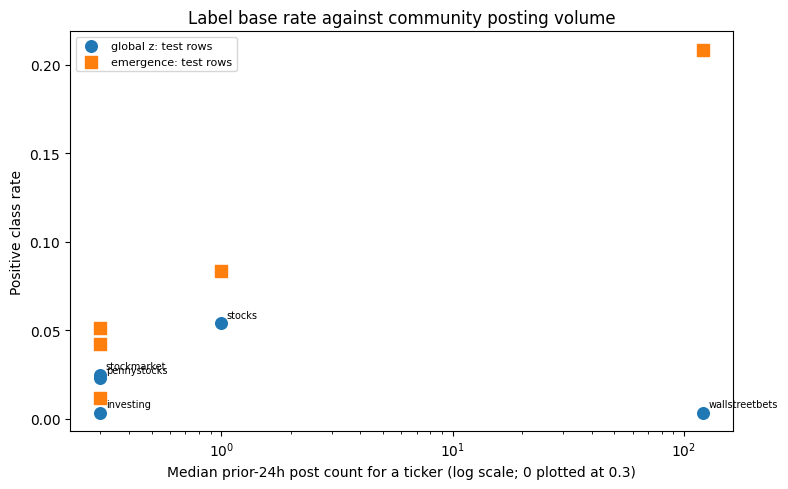

In [ ]:
SUBS = ['finance', 'investing', 'pennystocks', 'stockmarket', 'stocks', 'wallstreetbets']
existing_frames = {cfg.subreddit: (df_exploded, PIPE['meta']['raw']),
                   'pennystocks': (df_p, PIPE_P['meta']['raw']), 'investing': (di, PIPE_I['meta']['raw'])}
sweep_rows, skipped = [], []
for sub_name in SUBS:
    if not (DATA/f'{sub_name}.csv').exists():
        skipped.append({'subreddit': sub_name, 'reason': 'CSV missing'})
        continue
    t0 = time.time()
    row = sweep_one(sub_name, cfg, valid_symbols, *existing_frames.get(sub_name, (None, None)))
    if 'skipped' in row:
        skipped.append({'subreddit': sub_name, 'reason': row['skipped']})
        continue
    sweep_rows.append(row)
    print(f"  {sub_name:16s} rows {row['rows']:7d} tick {row['tickers']:5d} "
          f"medprior {row['median_prior_24h']:6.0f} G {row['global_base_rate']:.4f} "
          f"E {row['emergence_base_rate']:.4f}  ({time.time()-t0:.0f}s)")

log('scale_sensitivity.skipped', skipped)
for item in skipped:
    print(f"  {item['subreddit']:16s} skipped: {item['reason']}")
scale = pd.DataFrame(sweep_rows).sort_values('median_prior_24h').reset_index(drop=True)
safe_to_csv(scale, RESULTS/'tables'/'tab_scale_sensitivity.csv')
log('scale_sensitivity.sweep', scale.round(4).to_dict('records'))
print()
print(scale[['subreddit', 'rows', 'tickers', 'median_prior_24h', 'label_sd',
             'global_base_rate', 'emergence_base_rate', 'share_future_ge_min']].round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
x = scale.median_prior_24h.clip(lower=0.3)          # a log axis cannot show 0
ax.scatter(x, scale.global_base_rate, s=70, label='global z: test rows')
ax.scatter(x, scale.emergence_base_rate, s=70, marker='s', label='emergence: test rows')
for _, point in scale.iterrows():
    ax.annotate(point.subreddit, (max(point.median_prior_24h, 0.3), point.global_base_rate),
                fontsize=7, xytext=(4, 4), textcoords='offset points')
ax.set_xscale('log')
ax.set_xlabel('Median prior-24h post count for a ticker (log scale; 0 plotted at 0.3)')
ax.set_ylabel('Positive class rate')
ax.set_title('Label base rate against community posting volume')
ax.legend(fontsize=8); fig.tight_layout()
save_fig(fig, 'scale_sensitivity', f'Label base rates for {len(scale)} subreddits against posting volume')
plt.show()

In [ ]:
def coverage_probe(subreddit, frame, valid_symbols):
    """Post-level retention: posts with an extracted ticker / posts with any upper-case
    token or cashtag, and the same for cashtag posts only."""
    summary = token_summary(frame, valid_symbols)
    keys = ['posts', 'posts_with_any_token', 'posts_with_valid_ticker', 'posts_with_cashtag', 'cashtag_posts_retained']
    out = {'subreddit': subreddit, **{k: summary[k] for k in keys}}
    out['token_retention'] = round(out['posts_with_valid_ticker']/max(out['posts_with_any_token'], 1), 4)
    out['cashtag_retention'] = round(out['cashtag_posts_retained']/max(out['posts_with_cashtag'], 1), 4)
    return out

raw_frames = {cfg.subreddit: PIPE['meta']['raw_frame'], 'pennystocks': PIPE_P['meta']['raw_frame'],
              'investing': PIPE_I['meta']['raw_frame']}
probe = pd.DataFrame([coverage_probe(s, frame, valid_symbols) for s, frame in raw_frames.items()])
safe_to_csv(probe, RESULTS/'tables'/'tab_coverage_probe.csv')
log('extraction.coverage_probe', probe.to_dict('records'))
print(probe.to_string(index=False))

  subreddit  posts  posts_with_any_token  posts_with_valid_ticker  posts_with_cashtag  cashtag_posts_retained  token_retention  cashtag_retention
     stocks  66952                 34522                    21447                4897                    3440           0.6213             0.7025
pennystocks  49141                 34585                    13353               12775                    3527           0.3861             0.2761
  investing  35848                 13892                     6459                1659                     983           0.4649             0.5925


In [ ]:
# OTC symbols are absent from the NASDAQ Trader directory, so the extractor cannot see them.
OTC_PROBE = ['HCMC', 'OZSC', 'ABML', 'ALPP', 'ENZC', 'TSNP', 'SNPW', 'AITX', 'ILUS',
             'GAXY', 'TLSS', 'HMBL', 'RGBP', 'SIRC', 'PVDG']
assert not set(OTC_PROBE) & valid_symbols, 'An OTC probe symbol is in the extraction vocabulary.'
otc_rows = []
for sub_name in ['stocks', 'pennystocks']:
    counts = token_summary(raw_frames[sub_name], valid_symbols)['either_counts']
    otc_rows += [{'subreddit': sub_name, 'symbol': s, 'posts': int(counts.get(s, 0))} for s in OTC_PROBE]
otc = pd.DataFrame(otc_rows)
safe_to_csv(otc, RESULTS/'tables'/'tab_otc_gap.csv')
log('extraction.otc_coverage_gap', otc.groupby('subreddit')['posts'].sum().to_dict())
print(otc.pivot_table(index='symbol', columns='subreddit', values='posts').to_string())

subreddit  pennystocks  stocks
symbol                        
ABML             187.0    25.0
AITX             255.0    13.0
ALPP             237.0     9.0
ENZC              84.0     3.0
GAXY             100.0    11.0
HCMC             400.0    46.0
HMBL              72.0     6.0
ILUS              52.0     3.0
OZSC             271.0    26.0
PVDG              63.0     0.0
RGBP              74.0     5.0
SIRC              67.0     7.0
SNPW             142.0     7.0
TLSS             159.0     3.0
TSNP             202.0    11.0


In [ ]:
# How many symbols the current-listing IPO filter removes, and how often they appear.
post21 = set(UNIVERSE['listed_after_2021'])
baseline_symbols = (UNIVERSE['universe_symbols'] - post21) - AMBIGUOUS
restored = valid_symbols - baseline_symbols
excluded_by_ipo = post21 - valid_symbols - AMBIGUOUS
ipo_mentions = extractor_counts_stocks[extractor_counts_stocks.index.isin(excluded_by_ipo)]
log('extraction.ipo_filter_exposure', {
    'symbols_flagged_as_post2021': len(post21),
    'symbols_excluded_as_post2021': len(excluded_by_ipo),
    'of_which_appear_in_corpus': len(ipo_mentions),
    'top_excluded_by_mentions': ipo_mentions.head(10).to_dict(),
    'restored_by_manual_add': sorted(restored),
    'ipo_flags_overridden': sorted(restored & post21)})
print(f'{len(excluded_by_ipo)} IPO-flagged symbols excluded; {len(restored)} symbols restored.')
print('IPO flags overridden:', sorted(restored & post21))
print('Most-mentioned excluded symbols (posts with a bare or cashtag mention):')
print(ipo_mentions.head(15).to_string())

1571 IPO-flagged symbols excluded; 40 symbols restored.
IPO flags overridden: ['AZN', 'BAM', 'ETSY', 'GSAT', 'GSK', 'LAC', 'LB', 'VG']
Most-mentioned excluded symbols (posts with a bare or cashtag mention):
symbol
ARM     29
TOP     28
HKD     22
MINE    20
SAFE    16
CCXI    12
LTM     11
WS      10
TP      10
TGLS    10
JAN     10
HIT      9
CODX     9
GORO     8
BID      8


In [ ]:
# Distinct authors behind each positive window: a surge driven by one or two people
# looks different from one taken up by many.
author_counts = future_author_counts(df_exploded, cfg)
labelled, labels, _, _, _ = global_label_rows(df_exploded, cfg)
positive_windows = select_positive_ticker_rows(author_counts, labelled, labels)
known = positive_windows['authors_next_24h'].dropna()
# Windows from the same burst overlap, so these are windows, not independent bursts.
author_summary = {'n_windows': len(positive_windows), 'median': float(known.median()),
                  'share_single_author': float(known.eq(1).mean()),
                  'share_two_or_fewer': float(known.le(2).mean())}
log('diffusion.authors_per_positive_window', author_summary)
print('Distinct future authors per positive post-ticker window:', author_summary)

Distinct future authors per positive post-ticker window: {'n_windows': 1935, 'median': 4.0, 'share_single_author': 0.008785529715762274, 'share_two_or_fewer': 0.04496124031007752}


      target        arm  n_train  n_test      auc       ap       f1  precision_at_budget
    global_z   original    15322    3855 0.810250 0.405217 0.454629             0.457726
    global_z   controls    15322    3855 0.814692 0.407400 0.449331             0.465625
    global_z plus_burst    15322    3855 0.815873 0.415784 0.471647             0.462396
surge_emerge   original    15320    3853 0.805635 0.195521 0.270364             0.219178
surge_emerge   controls    15320    3853 0.807669 0.194647 0.254025             0.200000
surge_emerge plus_burst    15320    3853 0.806594 0.193340 0.257290             0.197183

Burst-state contribution beyond the calibration controls:
      target                comparison  delta_auc  delta_ap  delta_f1  delta_precision_at_budget  delta_recall_at_budget  n_test
    global_z plus_burst_minus_controls     0.0012    0.0084    0.0223                    -0.0032                  0.0503    3855
surge_emerge plus_burst_minus_controls    -0.0011   -0.0013 

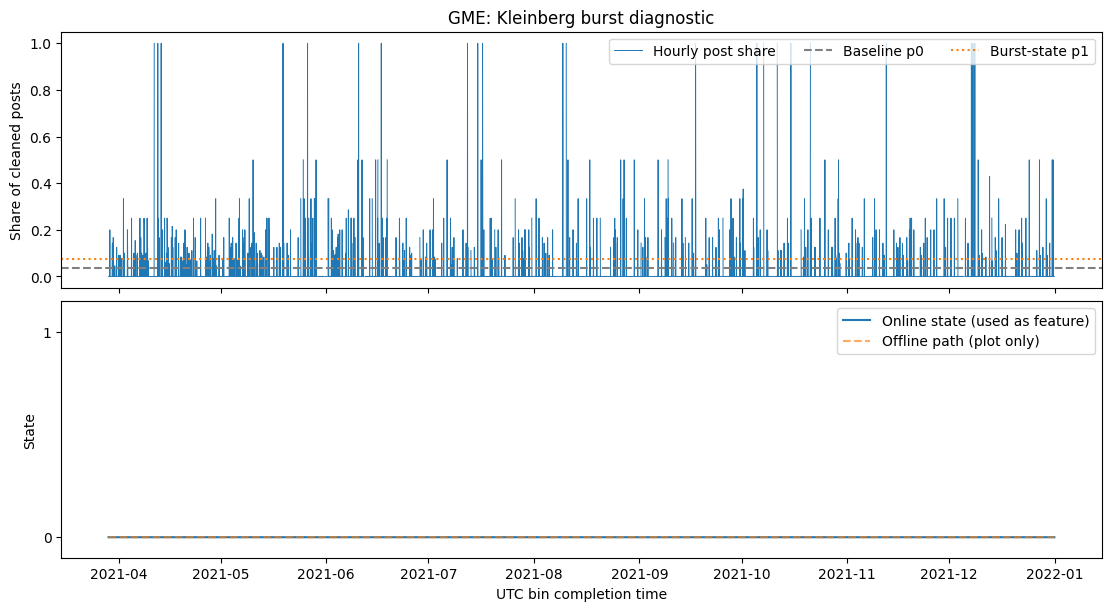

In [ ]:
# Do Kleinberg burst states add anything beyond the existing features?
kb_frame, kb_parameters, kb_traces, kb_meta = kleinberg_features(
    df_exploded, PIPE['meta']['raw_frame'], KB_CFG, mention_history=PIPE['meta']['mentions_frame'])
log('kleinberg.method', kb_meta)
safe_to_csv(kb_parameters, RESULTS/'tables'/'kleinberg_calibration.csv')

# 'controls' adds each ticker's calibration base rate and support flag; comparing
# 'plus_burst' with 'controls' isolates what the burst states add.
KB_RUNS, kb_metrics, kb_differences = {}, [], []
for label in ('global_z', 'surge_emerge'):
    target = 'volume_growth' if label == 'global_z' else label
    required = [*FEATURE_SETS['kb_augmented'], target]
    common = kb_frame.copy()
    common[required] = common[required].replace([np.inf, -np.inf], np.nan)
    common = common.dropna(subset=required)    # post-calibration rows only, shared by every arm
    local = {}
    for arm, feature_key in [('original', 'full_v2'), ('controls', 'kb_controls'), ('plus_burst', 'kb_augmented')]:
        name = f'kleinberg_{label}_{arm}'
        local[arm] = KB_RUNS[name] = fit_eval(common, feature_key, cfg, name, label=label, with_ci=False)
        kb_metrics.append({'target': label, 'arm': arm, **local[arm]['metrics']})
    for run in local.values():
        pd.testing.assert_frame_equal(local['original']['test_keys'], run['test_keys'])
        np.testing.assert_array_equal(local['original']['train_idx'], run['train_idx'])
    train_start = local['original']['data'].created.iloc[local['original']['train_idx']].min()
    assert train_start >= pd.Timestamp(kb_meta['first_feature_time']), 'Calibration rows entered training.'
    for comparator in ('original', 'controls'):
        a, b = local[comparator]['metrics'], local['plus_burst']['metrics']
        kb_differences.append({'target': label, 'comparison': f'plus_burst_minus_{comparator}',
                               **{f'delta_{metric}': b[metric]-a[metric]
                                  for metric in ('auc', 'ap', 'f1', 'precision_at_budget', 'recall_at_budget')},
                               'n_test': len(local['original']['y'])})

kb_results, kb_delta = pd.DataFrame(kb_metrics), pd.DataFrame(kb_differences)
log('kleinberg.experiments', {'paired_deltas': kb_differences,
                             'note': 'Exploratory point estimates on a post-calibration cohort; '
                                     'not comparable with the headline metrics.'})
safe_to_csv(kb_results.drop(columns=['feature_list']), RESULTS/'tables'/'kleinberg_model_comparison.csv')
safe_to_csv(kb_delta, RESULTS/'tables'/'kleinberg_paired_deltas.csv')
print(kb_results[['target', 'arm', 'n_train', 'n_test', 'auc', 'ap', 'f1', 'precision_at_budget']].to_string(index=False))
print('\nBurst-state contribution beyond the calibration controls:')
print(kb_delta[kb_delta.comparison == 'plus_burst_minus_controls'].round(4).to_string(index=False))

# Diagnostic plot for one ticker: online states against the offline (retrospective) path.
for ticker, trace in kb_traces.items():
    fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True, layout='constrained')
    share = np.divide(trace.relevant, trace.total, out=np.full(len(trace), np.nan), where=trace.total.to_numpy() > 0)
    p = kb_parameters.set_index('ticker').loc[ticker]
    axes[0].plot(trace.available_at, share, lw=.7, label='Hourly post share')
    axes[0].axhline(p.p0, color='grey', ls='--', label='Baseline p0')
    axes[0].axhline(p.p1, color='tab:orange', ls=':', label='Burst-state p1')
    axes[0].set(ylabel='Share of cleaned posts', title=f'{ticker}: Kleinberg burst diagnostic')
    axes[0].legend(loc='upper right', ncol=3)
    axes[1].step(trace.available_at, trace.state, where='post', label='Online state (used as feature)')
    axes[1].step(trace.available_at, trace.offline_state, where='post', alpha=.65, linestyle='--',
                 label='Offline path (plot only)')
    axes[1].set(xlabel='UTC bin completion time', ylabel='State', yticks=[0, 1], ylim=(-.1, 1.15))
    axes[1].legend(loc='upper right')
    save_fig(fig, 'kleinberg_diagnostic', f'{ticker}: online burst states versus the offline path, by hour')
    plt.show()

## 5. Checks on this run and saved results
These check the real outputs above (unlike the unit tests, they need the full run).

In [ ]:
def post_run_checks():
    checks = {}
    # The split purges every training label window before the first test row.
    d, tr, te = smoke['data'], smoke['train_idx'], smoke['test_idx']
    assert (d.created.iloc[tr]+pd.Timedelta(hours=HORIZON_H)).max() < d.created.iloc[te].min()
    # Censored rows have no target.
    assert df_exploded.target_observed.equals(df_exploded.label_end <= df_exploded.observation_end)
    assert df_exploded.loc[~df_exploded.target_observed,
                           ['future_count_24h', 'volume_growth', 'surge_emerge']].isna().all().all()
    checks['split_and_censoring'] = 'PASS'

    # Every planned comparison ran, on shared test rows.
    pd.testing.assert_frame_equal(R['G_v1']['test_keys'], R['G_v2_betweenness']['test_keys'])
    assert set(REPORT['significance']['block_bootstrap']) == set(PLANNED_COMPARISONS)
    checks['planned_comparisons_complete'] = 'PASS'

    # The accepted-ticker audit lists exactly the modelled tickers, each with enough mentions.
    assert set(audit_in.symbol) == set(df_exploded.ticker)
    assert (PIPE['meta']['mentions_frame'].groupby('ticker').id.nunique()
            .loc[df_exploded.ticker.unique()].ge(cfg.min_mentions).all())
    checks['accepted_audit_matches_model'] = 'PASS'

    # Kleinberg calibration counts use every mention, not just eligible rows.
    history = PIPE['meta']['mentions_frame']
    in_calibration = history.created.ge(pd.Timestamp(kb_meta['calibration_start'])) & \
                     history.created.lt(pd.Timestamp(kb_meta['calibration_end']))
    expected = history.loc[in_calibration].groupby('ticker').size()
    got = kb_parameters.set_index('ticker').calibration_mentions
    np.testing.assert_array_equal(got.to_numpy(), expected.reindex(got.index, fill_value=0).to_numpy())
    checks['kleinberg_calibration_uses_full_history'] = 'PASS'

    log('tests.post_run', checks)
    print(pd.Series(checks, name='result').to_string())

post_run_checks()

summary_keys = ['dataset.after_cleaning', 'dataset.rows_exploded', 'dataset.unique_tickers',
                'dataset.posts_retained', 'split.n_train', 'split.n_test',
                f'network.{cfg.subreddit}.has_network_rate',
                f'network.{cfg.subreddit}.posts_excluded_by_cap', 'model_selection.imbalance']
for key in summary_keys:
    node = REPORT
    for part in key.split('.'):
        node = node[part]
    print(f'{key:40s} {node}')
save_results()

split_and_censoring                        PASS
planned_comparisons_complete               PASS
accepted_audit_matches_model               PASS
kleinberg_calibration_uses_full_history    PASS
dataset.after_cleaning                   66952
dataset.rows_exploded                    30772
dataset.unique_tickers                   749
dataset.posts_retained                   21447
split.n_train                            24545
split.n_test                             6145
network.stocks.has_network_rate          0.6100350968412843
network.stocks.posts_excluded_by_cap     121
model_selection.imbalance                none
Saved: /content/drive/MyDrive/cm3070/results/20260928T070808Z/results.json


In [ ]:
kb_frame, kb_parameters, _, _ = kleinberg_features(
    df_exploded, PIPE['meta']['raw_frame'], KB_CFG,
    mention_history=PIPE['meta']['mentions_frame'])
rows = kb_frame.dropna(subset=['kb_state'])
sup = rows[rows.kb_supported == 1]
print(f"rows in burst state: {rows.kb_state.mean():.2%} of {len(rows)}")
print(f"supported tickers ever in burst: {sup.loc[sup.kb_state == 1, 'ticker'].nunique()} "
      f"of {sup.ticker.nunique()}")

rows in burst state: 0.65% of 19317
supported tickers ever in burst: 15 of 194
